#  <font color='#FFE15D'><b>💎 Train GPT-2 on TinyStories Dataset </b></font><font color='#FF0B55'></font>

# 🔴 **Environment Setup**

## 🟠 Change the font size of the output cells

In [ ]:
print('Salam Howsam!')

Salam Howsam!


In [ ]:
from IPython.display import HTML
shell = get_ipython()

def adjust_font_size():
  display(HTML('''<style>
    body {
      font-size: 20px;
    }
  '''))

if adjust_font_size not in shell.events.callbacks['pre_execute']:
  shell.events.register('pre_execute', adjust_font_size)

In [ ]:
print('Salam Howsam!')

Salam Howsam!


## 🟠 `pip`

In [ ]:
!pip install torchmetrics

In [ ]:
!pip install colorama

# 🔴 **Import**

In [ ]:
import os
import sys
import time
import math
import json
import yaml
import random
from tqdm import tqdm
from pprint import pprint
from itertools import cycle
from datetime import datetime
from termcolor import colored
from dataclasses import dataclass, asdict, field
from prettytable import PrettyTable

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from datasets import load_dataset
from tokenizers import Tokenizer

import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.nn import functional as F

from torchmetrics import MeanMetric

import glob
from typing import Optional

from torch.utils.data import Dataset, DataLoader

from prettytable import PrettyTable
from termcolor import colored
import time
from tqdm import tqdm


In [ ]:
import tokenizers
tokenizers.__version__

'0.21.1'

In [ ]:
from colorama import init
init()

# 🔴 **Utils**

In [ ]:
# Assuming 'tokens' is a PyTorch tensor or a similar array-like object that supports .shape and slicing.

def prepare_data(tokens, seq_len: int):
    """
    Prepares a 1D tensor of tokens for batching by reshaping it into a 2D tensor.

    The function first trims the tokens so that its total length is an exact multiple
    of 'seq_len'. Then, it reshapes the trimmed tokens into a 2D tensor where
    each row has 'seq_len' tokens.

    Args:
        tokens: A 1D tensor of token IDs.
        seq_len (int): The desired length of each sequence in the output 2D tensor.

    Returns:
        torch.Tensor: A 2D tensor of tokens with shape (-1, seq_len).
                      The first dimension is the number of resulting sequences.
    """
    # Trim tokens so that the total number of tokens is divisible by seq_len.
    # This ensures that the data can be evenly divided into sequences of length 'seq_len'.

    # Calculate the largest number of tokens that is a multiple of seq_len and less than or equal to the current number of tokens.
    # tokens.shape[0] gives the total number of tokens in the input 1D tensor.
    # '//' performs integer division.
    n_tokens = (tokens.shape[0] // seq_len) * seq_len

    # Slice the tokens tensor to keep only the calculated 'n_tokens'.
    # This removes any trailing tokens that would not form a complete sequence.
    tokens = tokens[:n_tokens]

    # Reshape the 1D tensor of tokens into a 2D tensor.
    # The '.view(-1, seq_len)' method reshapes the tensor into a new shape
    # where 'seq_len' is the number of columns (length of each sequence),
    # and '-1' infers the number of rows automatically based on the total number of elements
    # and the specified number of columns.
    return tokens.view(-1, seq_len)

In [ ]:
# Assuming 'model' is an instance of a PyTorch nn.Module.

def num_trainable_params(model: torch.nn.Module) -> float:
    """
    Calculates the number of trainable parameters in a PyTorch model.

    Trainable parameters are those for which 'requires_grad' is True.
    The function returns the count in millions.

    Args:
        model (torch.nn.Module): The PyTorch model to inspect.

    Returns:
        float: The number of trainable parameters in the model, in millions.
    """
    # Calculate the sum of the number of elements for all parameters that require gradients.
    # 1. model.parameters(): Returns an iterator over all parameters of the model.
    # 2. if p.requires_grad: Filters these parameters to include only those that are trainable
    #    (i.e., their gradients will be computed during backpropagation).
    # 3. p.numel(): For each trainable parameter 'p', returns the total number of elements in it.
    # 4. sum(...): Sums the number of elements across all trainable parameters.
    # 5. / 1e6: Divides the total count by 1,000,000 to express the result in millions.
    nums = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

    # Return the calculated number of trainable parameters (in millions).
    return nums

In [ ]:
import torch # Assuming torch is imported
import time  # Assuming time is imported

# Benchmarking function
def calculate_time(model: torch.nn.Module, x: torch.Tensor, num_runs: int = 10) -> float:
    """
    Calculates the average inference time of a PyTorch model for a given input.

    This function is designed for benchmarking model speed, particularly on a GPU.
    It synchronizes CUDA operations before and after timing to ensure accurate
    measurement of GPU execution time.

    Args:
        model (torch.nn.Module): The PyTorch model to benchmark.
        x (torch.Tensor): The input tensor to feed to the model. It's assumed this tensor
                          is already on the correct device (e.g., GPU).
        num_runs (int, optional): The number of times to run the model inference
                                  to get an average time. Defaults to 10.

    Returns:
        float: The average inference time in seconds per run.
    """
    # Synchronize CUDA operations before starting the timer.
    # This ensures that any pending CUDA operations from previous code are completed
    # before we start measuring time. This is crucial for accurate GPU timing.
    if torch.cuda.is_available(): # Check if CUDA is available before synchronizing
        torch.cuda.synchronize()

    # Record the starting time.
    start = time.time()

    # Run the model inference 'num_runs' times.
    # The loop variable '_' indicates that the loop index is not used inside the loop.
    for _ in range(num_runs):
        # Perform a forward pass of the model with the input 'x'.
        # The output of the model is not stored or used here as we are only interested in timing.
        model(x)

    # Synchronize CUDA operations again after the inference runs.
    # This ensures that all CUDA operations initiated by the model are completed
    # before we record the end time.
    if torch.cuda.is_available(): # Check if CUDA is available
        torch.cuda.synchronize()

    # Calculate the total elapsed time and then the average time per run.
    # time.time() gets the current time.
    elapsed_time = time.time() - start
    average_time_per_run = elapsed_time / num_runs

    return average_time_per_run

# 🔴 **Dataset**

In [ ]:
# Modified for cell 10
from torch.utils.data import Dataset, DataLoader # Ensure imports are present

class TinyStoriesDataset(Dataset):
    """
    Dataset class for TinyStories.
    Prepares data by tokenizing and creating sequences of a fixed length.
    """

    def __init__(self, data, seq_len):
        """
        Initializes the dataset.

        Args:
            data: The tokenized data (e.g., a tensor of token IDs).
            seq_len: The desired sequence length for model input.
        """
        self.seq_len = seq_len
        # seq_len+1 is used to create (input, target) pairs by shifting in the training loop
        # The prepare_data function will handle shaping the data into sequences of length seq_len + 1
        self.data = prepare_data(data, seq_len + 1)

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        """
        return self.data.shape[0] # Number of sequences

    def __getitem__(self, idx):
        """
        Retrieves a sample from the dataset at the given index.

        Args:
            idx: The index of the sample to retrieve.

        Returns:
            A dictionary containing the sample tensor with the key "input_ids".
        """
        sample = self.data[idx] # Get the sequence at the specified index
        # Must return a dictionary to be compatible with DataLoader and the training loop,
        # which expects an "input_ids" key.
        return {"input_ids": sample.long()} # Convert sample to long tensor and wrap in a dictionary

# 🔴 **Model**

## 🟠 Multi Head Attention

In [ ]:
import torch.nn as nn # Assuming nn is imported from torch
import torch.nn.functional as F # Assuming F is imported from torch.nn.functional

class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention module.
    This module performs multi-head self-attention as described in the "Attention Is All You Need" paper.
    It allows the model to jointly attend to information from different representation subspaces at different positions.
    """

    def __init__(self, config):
        """
        Initializes the MultiHeadAttention module.

        Args:
            config: A configuration object containing model parameters.
                    Expected attributes:
                        n_embd (int): The embedding dimension.
                        n_head (int): The number of attention heads.
        """
        super().__init__()
        self.n_embd = config.n_embd  # Embedding dimension
        self.n_head = config.n_head  # Number of attention heads
        self.head_size = self.n_embd // self.n_head # Dimension of each attention head, ensuring it's an integer division

        # Linear projection layer for Query, Key, and Value (QKV)
        # Input dimension is n_embd, output dimension is 3 * n_embd (for Q, K, V combined)
        # No bias is used in this linear layer.
        self.qkv_proj = nn.Linear(self.n_embd, 3 * self.n_embd, bias=False)

        # Output projection layer
        # Input dimension is n_embd (concatenated heads), output dimension is n_embd
        # No bias is used in this linear layer.
        self.c_proj = nn.Linear(self.n_embd, self.n_embd, bias=False)

        # Custom attribute to indicate this projection might be part of a residual connection
        # This is likely used by a custom weight initialization scheme.
        self.c_proj.residual = True

    def forward(self, x):
        """
        Performs the forward pass of the Multi-Head Attention module.

        Args:
            x (torch.Tensor): The input tensor of shape (B, T, C), where:
                              B is the batch size.
                              T is the sequence length.
                              C is the embedding dimension (n_embd).

        Returns:
            torch.Tensor: The output tensor of shape (B, T, C) after applying multi-head attention.
        """
        B, T, C = x.shape # Batch size, Sequence length, Embedding dimension

        # QKV linear projection and reshaping for multi-head attention
        # 1. Project x to get combined Q, K, V: self.qkv_proj(x) -> (B, T, 3 * n_embd)
        # 2. Reshape to separate heads: .view(B, T, 3 * self.n_head, self.head_size)
        #    This prepares the tensor to be split into Q, K, V for each head.
        #    The shape becomes (B, T, num_total_qkv_components_across_heads, head_dimension_per_component)
        # 3. Transpose to bring heads to a dimension suitable for batch matrix multiplication:
        #    .transpose(1, 2) -> (B, 3 * self.n_head, T, self.head_size)
        #    Actually, the common PyTorch convention for MHA input to SDPA is (B, num_heads, T, head_dim)
        #    Let's re-verify the qkv_proj and subsequent view/transpose/chunk:
        #    qkv_proj(x) -> (B, T, 3 * C)
        #    .view(B, T, self.n_head * 3, self.head_size)
        #    .transpose(1,2) -> (B, self.n_head * 3, T, self.head_size)
        #    .chunk(3, dim=1) # This will chunk along the n_head * 3 dimension
        #    The original code uses dim=-3 for chunk, which implies the shape before chunk might be different.
        #    Let's assume the original code's logic is intended:
        #    qkv_proj(x) is (B, T, 3*n_embd)
        #    .view(B, T, 3*self.n_head, self.head_size) # (B, T, 3*n_head, hs)
        #    .transpose(1, 2) # (B, 3*n_head, T, hs)
        #    .chunk(3, dim=1) # Chunks along the '3*n_head' dimension into three (B, n_head, T, hs) tensors for q, k, v
        #    The original code uses dim=-3 which means it chunks along the second dimension (3*n_head). This is correct.

        q, k, v = self.qkv_proj(x).view(B, T, 3 * self.n_head, self.head_size).transpose(1, 2).chunk(3, dim=1) # Corrected dim from -3 to 1 for clarity, assuming it's the second dim after transpose

        # Scaled Dot Product Attention using PyTorch's built-in function
        # is_causal=True enables masked attention for autoregressive models (like GPT)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # Output shape: (B, n_head, T, head_size)

        # Reshape and final projection
        # 1. Transpose back: y.transpose(1, 2) -> (B, T, n_head, head_size)
        # 2. Make contiguous for the view operation: .contiguous()
        # 3. Reshape to combine heads: .view(B, T, C) -> (B, T, n_embd)
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # Apply the final linear projection
        y = self.c_proj(y)
        return y

## 🟠 Feed Forward (MLP)

In [ ]:
import torch.nn as nn # Assuming nn is imported from torch
import torch.nn.functional as F # Assuming F is imported from torch.nn.functional

class FeedForward(nn.Module):
    """
    Position-wise Feed-Forward Network (FFN) module.
    This module consists of two linear transformations with a GELU activation in between,
    as commonly used in Transformer architectures.
    """

    def __init__(self, config):
        """
        Initializes the FeedForward module.

        Args:
            config: A configuration object containing model parameters.
                    Expected attributes:
                        n_embd (int): The embedding dimension (input and output dimension of this FFN).
                        f_expnd (int): The expansion factor for the hidden layer of the FFN.
                                       The hidden layer dimension will be f_expnd * n_embd.
        """
        super().__init__()
        self.n_embd = config.n_embd  # Embedding dimension
        self.f_expnd = config.f_expnd # Expansion factor for the feed-forward layer

        # The first linear transformation, which projects the input from n_embd to an expanded dimension.
        # The expanded dimension is f_expnd * n_embd.
        # No bias is used in this linear layer.
        self.up_proj = nn.Linear(self.n_embd, int(self.f_expnd * self.n_embd), bias=False)

        # The second linear transformation, which projects the expanded dimension back to n_embd.
        # No bias is used in this linear layer.
        self.down_proj = nn.Linear(int(self.f_expnd * self.n_embd), self.n_embd, bias=False)

        # Custom attribute to indicate this projection might be part of a residual connection.
        # This is likely used by a custom weight initialization scheme.
        self.down_proj.residual = True

    def forward(self, x):
        """
        Performs the forward pass of the FeedForward module.

        Args:
            x (torch.Tensor): The input tensor of shape (B, T, C), where:
                              B is the batch size.
                              T is the sequence length.
                              C is the embedding dimension (n_embd).

        Returns:
            torch.Tensor: The output tensor of shape (B, T, C) after passing through the FFN.
        """
        # Apply the first linear projection, then GELU activation, then the second linear projection.
        # x -> up_proj -> GELU -> down_proj
        return self.down_proj(F.gelu(self.up_proj(x)))

## 🟠 Decoder Block

In [ ]:
import torch.nn as nn # Assuming nn is imported from torch
# Assuming MultiHeadAttention and FeedForward classes are defined elsewhere and imported

class DecoderBlock(nn.Module):
    """
    A single block of a Transformer decoder.
    This block typically consists of a multi-head self-attention mechanism
    followed by a position-wise feed-forward network. Layer normalization
    is applied before each of these sub-layers, and residual connections
    are used around each of the two sub-layers.
    """

    def __init__(self, config):
        """
        Initializes the DecoderBlock module.

        Args:
            config: A configuration object containing model parameters.
                    Expected attributes:
                        n_embd (int): The embedding dimension, which is the input and output
                                      dimension of this block.
                    This config object will also be passed to the MultiHeadAttention
                    and FeedForward modules.
        """
        super().__init__()
        self.n_embd = config.n_embd  # Embedding dimension

        # First Layer Normalization, applied before the multi-head attention layer.
        self.ln1 = nn.LayerNorm(config.n_embd)
        # Multi-Head Attention (MHA) layer.
        self.mha = MultiHeadAttention(config)

        # Second Layer Normalization, applied before the feed-forward network.
        self.ln2 = nn.LayerNorm(config.n_embd)
        # Feed-Forward Network (FFN), also referred to as MLP (Multi-Layer Perceptron).
        self.mlp = FeedForward(config)

    def forward(self, x):
        """
        Performs the forward pass of the DecoderBlock module.

        Args:
            x (torch.Tensor): The input tensor of shape (B, T, C), where:
                              B is the batch size.
                              T is the sequence length.
                              C is the embedding dimension (n_embd).

        Returns:
            torch.Tensor: The output tensor of shape (B, T, C) after passing through
                          the decoder block's layers.
        """
        # First sub-layer: Multi-Head Attention with LayerNorm and residual connection.
        # x = x_input + Attention(LayerNorm(x_input))
        x = x + self.mha(self.ln1(x))

        # Second sub-layer: Feed-Forward Network with LayerNorm and residual connection.
        # x = x_intermediate + FeedForward(LayerNorm(x_intermediate))
        x = x + self.mlp(self.ln2(x))

        return x

## 🟠 GPT

In [ ]:
import torch # Assuming torch is imported
import torch.nn as nn # Assuming nn is imported from torch
# Assuming DecoderBlock class is defined elsewhere and imported

class GPT(nn.Module):
    """
    GPT (Generative Pre-trained Transformer) model.
    This class implements the core architecture of a GPT-like model,
    consisting of token and position embeddings, a stack of Transformer decoder blocks,
    and a final layer for language modeling.
    """

    def __init__(self, config):
        """
        Initializes the GPT model.

        Args:
            config: A configuration object containing model parameters.
                    Expected attributes:
                        vocab_size (int): The size of the vocabulary.
                        n_embd (int): The embedding dimension.
                        max_seq_len (int): The maximum sequence length the model can handle
                                           (for positional embeddings).
                        n_layer (int): The number of decoder blocks (Transformer layers).
        """
        super().__init__()
        self.config = config # Store the configuration object

        # Token embedding layer: maps vocabulary indices to dense embedding vectors.
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)

        # Position embedding layer: maps position indices (0 to max_seq_len-1) to dense embedding vectors.
        self.wpe = nn.Embedding(config.max_seq_len, config.n_embd)

        # A list of decoder blocks (Transformer layers).
        # The number of layers is specified by config.n_layer.
        self.decoders = nn.ModuleList([DecoderBlock(config) for _ in range(config.n_layer)])

        # Final Layer Normalization, applied after the decoder blocks and before the language modeling head.
        self.lnf = nn.LayerNorm(config.n_embd)

        # Language modeling head: a linear layer that maps the final hidden states to vocabulary scores (logits).
        # No bias is used in this linear layer.
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight tying: The weights of the token embedding layer (wte) and the language modeling head (lm_head)
        # are shared. This is a common practice in language models that can reduce the number of parameters
        # and improve performance.
        self.lm_head.weight = self.wte.weight

        # Apply custom weight initialization to all modules in the network.
        self.apply(self._init_weights)

    def _init_weights(self, module):
        """
        Custom weight initialization scheme.
        This function is applied recursively to all submodules of the GPT model.
        It initializes Linear and Embedding layers with a normal distribution.
        For Linear layers marked with a 'residual' attribute (likely output projections
        in attention or FFNs that are part of a residual connection), the standard
        deviation of the initialization is scaled.

        Args:
            module (nn.Module): The module to initialize.
        """
        std = 0.02 # Standard deviation for initialization
        if isinstance(module, nn.Linear):
            # If the linear layer has a 'residual' attribute (custom flag),
            # scale the standard deviation. This is a common technique (e.g., in GPT-2)
            # for layers that are part of residual connections to help with training stability.
            if hasattr(module, 'residual'):
                std *= (2 * self.config.n_layer)**-0.5 # Scale std by sqrt(1 / (2 * num_layers))

            # Initialize weights from a normal distribution with mean 0 and calculated std.
            nn.init.normal_(module.weight, mean=0.0, std=std)

            # Initialize biases to zero if they exist.
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Initialize embedding weights from a normal distribution.
            nn.init.normal_(module.weight, mean=0.0, std=std)

    def forward(self, idx):
        """
        Performs the forward pass of the GPT model.

        Args:
            idx (torch.Tensor): The input tensor of token indices, shape (B, T), where:
                                B is the batch size.
                                T is the sequence length.

        Returns:
            torch.Tensor: The output logits tensor of shape (B, T, vocab_size),
                          representing the scores for each token in the vocabulary
                          at each position in the sequence.
        """
        B, T = idx.shape # Batch size, Sequence length

        # Token Embedding + Position Embedding
        # 1. Get token embeddings: self.wte(idx) -> (B, T, n_embd)
        # 2. Create position indices: torch.arange(T, device=idx.device) -> (T)
        # 3. Get position embeddings: self.wpe(...) -> (T, n_embd), which will be broadcasted to (B, T, n_embd)
        # 4. Add token and position embeddings element-wise.
        pos = torch.arange(T, device=idx.device) # Create position indices [0, 1, ..., T-1]
        x = self.wte(idx) + self.wpe(pos) # Sum token and position embeddings

        # Pass through the stack of Decoder blocks
        for decoder in self.decoders:
            x = decoder(x)

        # Apply final Layer Normalization
        x = self.lnf(x)

        # Pass through the Language Modeling head to get logits
        logits = self.lm_head(x) # Output shape: (B, T, vocab_size)

        return logits

# 🔴 **Config**

In [ ]:
from dataclasses import dataclass, field # Ensure dataclass and field are imported
from typing import Optional # Ensure Optional is imported for type hinting

@dataclass
class DatasetConfig:
    """
    Configuration for dataset parameters.
    """
    train_path: str # Path to the training dataset file.
    valid_path: str # Path to the validation dataset file.
    tokenizer_path: str # Path to the tokenizer file.
    batch_size: int = 32 # Batch size for training and validation.
    seq_len: int = 128 # Sequence length for model input.

@dataclass
class GPTConfig:
    """
    Configuration for the GPT model architecture.
    """
    vocab_size: int = 50257 # Vocabulary size. Default is for GPT-2.
    max_seq_len: int = 1024 # Maximum sequence length the model can handle (for positional embeddings). Default is for GPT-2.
    n_layer: int = 12 # Number of transformer decoder layers. Default is for GPT-2 small.
    n_head: int = 12 # Number of attention heads. Default is for GPT-2 small.
    n_embd: int = 768 # Embedding dimension. Default is for GPT-2 small.
    f_expnd: int = 4 # Expansion factor for the feed-forward layer's hidden dimension (typically 4 * n_embd).

# We will keep only one definition for CheckpointConfig
@dataclass
class CheckpointConfig:
    """
    Configuration for checkpointing behavior.
    """
    checkpoint_dir: str = 'checkpoints' # Directory to save checkpoints. Renamed from 'dir' for consistency.
    save_interval_tokens: int = 1_000_000 # Interval (in tokens) at which to save checkpoints. Reasonable default.
    keep_last: int = 5 # Number of last checkpoints to keep.
    resume: bool = True # Whether to resume training from the latest checkpoint if available.

@dataclass
class OptimizerConfig:
    """
    Configuration for the optimizer.
    """
    max_lr: float = 3e-4 # Maximum learning rate.
    betas: tuple = (0.9, 0.95) # Beta parameters for AdamW optimizer.
    weight_decay: float = 0.1 # Weight decay for regularization.
    fused: bool = True # Whether to use a fused optimizer (if available, e.g., AdamW).
    warmup_steps: int = 256 # Number of warmup steps for the learning rate scheduler.
    alpha: float = 0.1 # Multiplicative factor for the minimum learning rate (e.g., min_lr = alpha * max_lr).

@dataclass
class TrainConfig:
    """
    Configuration for the training process.
    """
    seed: int = 42 # Random seed for reproducibility.
    device: str = 'cuda' # Device to use for training ('cuda' or 'cpu').
    total_tokens: int = 65_000_000 # Total number of tokens to train for.
    log_interval_tokens: int = 10_000_000 # Interval (in tokens) for logging training progress.
    log_dir: str = 'logs' # Directory to save training logs.
    run_name: str = 'gpt2_tinystories' # Name for the current training run.
    batch_size: int = 48 # Batch size for training (can be different from DatasetConfig for dataloading if needed, but usually consistent).
    seq_len: int = 512 # Sequence length for training (can be different from DatasetConfig for dataloading, but usually consistent).
    eval_interval_tokens: int = 1_000_000 # Interval (in tokens) for evaluation. Default value added or to be set in MasterConfig.

    # Using Optional to indicate it can be None or should be initialized.
    # This checkpoint configuration is for the trainer's internal logic (e.g., resume flag, save interval).
    checkpoint: Optional[CheckpointConfig] = field(default_factory=CheckpointConfig) # Uses the CheckpointConfig defined above as default.

    max_steps: int = 0 # Maximum number of training steps (0 means train for total_tokens).
    max_time: float = 0.0 # Maximum training time in seconds (0 means no time limit).


@dataclass
class GenerationConfig:
    """
    Configuration for text generation.
    """
    prompts: list[str] # List of prompts to use for generation.
    T: float = 0.9 # Temperature for sampling (controls randomness).
    max_seq_len: int = 128 # Maximum sequence length for generated text.
    top_k: int = 10 # Top-k sampling parameter.
    n_rep: int = 3 # Number of repetitions/samples to generate for each prompt.
    seed: int = 42 # Random seed for generation reproducibility.

@dataclass
class MasterConfig:
    """
    Master configuration that groups all other specific configurations.
    """
    data: DatasetConfig # Dataset configuration.
    model: GPTConfig # GPT model architecture configuration.
    optimizer: OptimizerConfig # Optimizer configuration.
    train: TrainConfig # Training process configuration.
    generation: GenerationConfig # Text generation configuration.
    checkpoint_manager_config: CheckpointConfig # Configuration for the CheckpointManager instance itself.

# 🔴 **Functions ⚙️**

## 🟠 Checkpoint Manager

In [ ]:
import os # For operating system dependent functionalities like path joining, making directories
import glob # For finding all pathnames matching a specific pattern
from datetime import datetime # For generating timestamps
import torch # PyTorch library

class CheckpointManagerPyTorch:
    """
    Manages saving and loading of PyTorch model checkpoints.
    It keeps a specified number of recent checkpoints and handles the naming and organization.
    """
    def __init__(self, checkpoint_dir: str, keep_last: int = 5):
        """
        Initializes the CheckpointManager.

        Args:
            checkpoint_dir (str): The directory where checkpoint files will be saved.
            keep_last (int): The number of most recent checkpoints to keep. Older ones will be deleted.
        """
        self.checkpoint_dir = checkpoint_dir # Directory to store checkpoint files
        os.makedirs(self.checkpoint_dir, exist_ok=True) # Create the checkpoint directory if it doesn't exist
        self.keep_last = keep_last # Number of latest checkpoints to retain

    def save(self, model: torch.nn.Module, optimizer: torch.optim.Optimizer, seen_tokens: int, best_val_loss: float = None, extra: dict = None):
        """
        Saves a checkpoint file that includes:
          - model_state_dict: The state of the model's parameters.
          - optimizer_state_dict: The state of the optimizer.
          - seen_tokens: The number of tokens processed so far during training.
          - best_val_loss (optional): The best validation loss achieved so far.
          - extra (optional, dict): Any additional information to save (e.g., {'step': current_step}).

        Args:
            model (torch.nn.Module): The model to save.
            optimizer (torch.optim.Optimizer): The optimizer state to save.
            seen_tokens (int): The number of tokens seen during training up to this point.
            best_val_loss (float, optional): The best validation loss recorded. Defaults to None.
            extra (dict, optional): A dictionary for any extra metadata to save. Defaults to None.
        """

        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S") # Generate a timestamp for unique filenames
        filename = f"checkpoint_{timestamp}_tok{seen_tokens}.pth" # Construct the filename
        filepath = os.path.join(self.checkpoint_dir, filename) # Full path to the checkpoint file

        # State structure to be saved:
        state = {
            'seen_tokens': seen_tokens, # Number of tokens processed
            'model_state_dict': model.state_dict(), # Model's learned parameters
            'optimizer_state_dict': optimizer.state_dict(), # Optimizer's state (e.g., momentum)
        }
        if best_val_loss is not None:
            state['best_val_loss'] = best_val_loss # Store the best validation loss
        if extra is not None:
            state['extra'] = extra # Store any additional information

        torch.save(state, filepath) # Save the state dictionary to the file
        print(f"✅ Saved checkpoint: {filepath} (seen_tokens={seen_tokens:,})")

        # Remove old checkpoints if necessary to keep only 'keep_last' number of checkpoints
        all_ckpts = sorted(glob.glob(os.path.join(self.checkpoint_dir, "checkpoint_*.pth"))) # Get all checkpoint files
        if len(all_ckpts) > self.keep_last:
            os.remove(all_ckpts[0]) # Remove the oldest checkpoint
            print(f"🗑️ Removed old checkpoint: {all_ckpts[0]}")


    def load_latest(
        self,
        model: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device
    ):
        """
        Loads the latest checkpoint (if any) from self.checkpoint_dir.
        Restores the model and optimizer states.

        Args:
            model (torch.nn.Module): The model instance to load the state into.
            optimizer (torch.optim.Optimizer): The optimizer instance to load the state into.
            device (torch.device): The device to map the loaded tensors to (e.g., 'cuda' or 'cpu').

        Returns:
            tuple: A tuple containing (seen_tokens, best_val_loss, step).
                   - seen_tokens (int): Number of tokens seen from the loaded checkpoint.
                   - best_val_loss (float or None): Best validation loss from the loaded checkpoint.
                   - step (int): Training step from the loaded checkpoint (from extra['step'] if present, else 0).
                   If no checkpoint exists, returns (0, None, 0).
        """
        # Find all checkpoint files in the directory, sorted by name (which includes timestamp)
        checkpoint_files = sorted(
            [
                os.path.join(self.checkpoint_dir, fname)
                for fname in os.listdir(self.checkpoint_dir) # List all files in the directory
                if fname.startswith("checkpoint_") and fname.endswith(".pth") # Filter for checkpoint files
            ]
        )
        if not checkpoint_files:
            print("🔎 No checkpoint found. Starting from scratch.")
            return 0, None, 0 # Return default values if no checkpoint is found

        latest_path = checkpoint_files[-1] # Get the path of the most recent checkpoint
        checkpoint = torch.load(latest_path, map_location=device) # Load the checkpoint, mapping to the specified device

        model.load_state_dict(checkpoint["model_state_dict"]) # Restore model state
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"]) # Restore optimizer state

        # Move optimizer tensors to the correct device
        # This is important if training is resumed on a different device than where it was saved.
        for state in optimizer.state.values():
            for k, v in state.items():
                if isinstance(v, torch.Tensor):
                    state[k] = v.to(device)

        # Retrieve saved metadata
        seen_tokens = checkpoint.get("seen_tokens", 0) # Get seen_tokens, default to 0 if not found
        best_val_loss = checkpoint.get("best_val_loss", None) # Get best_val_loss, default to None
        step = checkpoint.get("extra", {}).get("step", 0) # Get step from 'extra' dict, default to 0

        print(
            f"🔄 Loaded checkpoint: {latest_path} "
            f"(seen_tokens={seen_tokens:,}, best_val_loss={best_val_loss}, step={step})"
        )
        return seen_tokens, best_val_loss, step

## 🟠 Logger

In [ ]:
import os # For operating system dependent functionalities like path joining, making directories
import json # For working with JSON data (saving history)
from datetime import datetime # For generating timestamps
import torch # PyTorch library for saving model/optimizer states
import matplotlib.pyplot as plt # For plotting learning curves

# Logger class for saving and plotting training logs
class Logger:
    """
    Manages training history logging, saving logs and best model to disk, and plotting learning curves.
    """
    def __init__(self, log_dir='logs', run_name='default_run'):
        """
        Initializes the Logger.

        Args:
            log_dir (str, optional): The base directory where logs for all runs will be stored.
                                     Defaults to 'logs'.
            run_name (str, optional): A specific name for the current training run, used to create a
                                      subdirectory within log_dir. Defaults to 'default_run'.
        """
        # Create a unique directory for this run using a timestamp
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S") # Generate a timestamp string
        self.log_dir = os.path.join(log_dir, f"{run_name}_{timestamp}") # Path to the specific log directory for this run
        os.makedirs(self.log_dir, exist_ok=False) # Create the directory; exist_ok=False raises an error if it already exists

        # Initialize a dictionary to store the history of various metrics
        self.history = {
            'train_loss': [],       # List to store training loss at each log point
            'valid_loss': [],       # List to store validation loss at each log point
            'best_loss_valid': float('inf'), # Stores the best validation loss seen so far, initialized to infinity
            'seen_tokens': [],      # List to store the number of tokens seen at each log point
            'elapsed_time': []      # List to store the elapsed time at each log point
        }

    def log(self, train_loss: float, valid_loss: float, seen_tokens: int, elapsed_time: float = 0):
        """
        Logs the current training and validation metrics.

        Args:
            train_loss (float): The training loss for the current interval.
            valid_loss (float): The validation loss for the current interval.
            seen_tokens (int): The total number of tokens processed up to this point.
            elapsed_time (float, optional): The total elapsed training time up to this point. Defaults to 0.
        """
        self.history['train_loss'].append(train_loss)
        self.history['valid_loss'].append(valid_loss)
        self.history['seen_tokens'].append(seen_tokens)
        self.history['elapsed_time'].append(elapsed_time)

    def save(self, model: torch.nn.Module, optimizer: torch.optim.Optimizer):
        """
        Saves the current history to a JSON file and saves the model/optimizer state
        if the current validation loss is the best seen so far. Also plots the learning curves.

        Args:
            model (torch.nn.Module): The current model instance.
            optimizer (torch.optim.Optimizer): The current optimizer instance.
        """
        # Save the entire history dictionary to a JSON file
        file_path = os.path.join(self.log_dir, 'loss_history.json')
        with open(file_path, 'w') as f: # Open file in write mode
            json.dump(self.history, f, indent=4) # Write history as JSON with indentation for readability

        # Save the best model and optimizer states based on validation loss
        current_loss_valid = self.history['valid_loss'][-1] # Get the most recent validation loss
        if current_loss_valid < self.history['best_loss_valid']:
            # If current validation loss is better than the previous best
            log_payload = dict(model=model.state_dict(), optimizer=optimizer.state_dict()) # Prepare payload
            torch.save(log_payload, f'{self.log_dir}/best_model.pt') # Save the model and optimizer states
            self.history['best_loss_valid'] = current_loss_valid # Update the best validation loss
            print("✅ Model Saved!") # Print confirmation message

        self.plot() # Plot the learning curves after saving

    def plot(self):
        """
        Plots the training and validation loss against the number of seen tokens
        and saves the plot to a PNG file. Also displays the plot.
        """
        plt.figure(figsize=(10, 5)) # Create a new figure with a specified size
        # Plot training loss
        plt.plot(self.history['seen_tokens'], self.history['train_loss'], label='Train Loss')
        # Plot validation loss
        plt.plot(self.history['seen_tokens'], self.history['valid_loss'], label='Valid Loss')

        plt.xlabel('Seen Tokens') # Set x-axis label
        plt.ylabel('Loss') # Set y-axis label
        plt.title('Learning Curve') # Set plot title
        plt.legend() # Display the legend (Train Loss, Valid Loss)
        plt.grid(True) # Add a grid to the plot
        plt.tight_layout() # Adjust plot to ensure everything fits without overlapping

        # Save the plot to a file in the log directory
        plt.savefig(os.path.join(self.log_dir, 'learning_curve.png'))
        plt.show() # Display the plot in the output (e.g., Jupyter Notebook)

## 🟠 Train ➰

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import yaml
from dataclasses import asdict
import time
from tqdm import tqdm
from prettytable import PrettyTable
from termcolor import colored
import matplotlib.pyplot as plt
import os

class LLMTrainer:
    """
    Manages the training and evaluation loop for a Language Model (LLM),
    including logging, plotting, checkpointing, and text generation.
    """
    def __init__(
        self,
        model: torch.nn.Module,
        optimizer: torch.optim.Optimizer,
        train_dataloader: DataLoader,
        val_dataloader: DataLoader,
        loss_fn: torch.nn.Module,
        train_config,
        optimizer_config,
        generation_config=None,
        tokenizer=None,
        ckpt_manager=None,
        device: torch.device=None,
        scheduler_fn=None
    ):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.train_loader = train_dataloader
        self.val_loader = val_dataloader
        self.loss_fn = loss_fn
        self.train_config = train_config
        self.optimizer_config = optimizer_config
        self.generation_config = generation_config
        self.tokenizer = tokenizer
        self.ckpt_manager = ckpt_manager
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.scheduler_fn = scheduler_fn

        # Training state variables
        self.best_val_loss = float('inf')
        self.seen_tokens = 0
        self.step = 0
        self.token_eval_counter = 0

        if self.train_config.checkpoint.resume and self.ckpt_manager:
            seen_tokens, best_val_loss, loaded_step = self.ckpt_manager.load_latest(
                self.model, self.optimizer, self.device
            )
            self.seen_tokens = seen_tokens
            self.best_val_loss = best_val_loss if best_val_loss is not None else float('inf')
            self.step = loaded_step
        else:
            self.seen_tokens = 0
            self.best_val_loss = float('inf')
            self.step = 0

        self.next_save_threshold = self.train_config.checkpoint.save_interval_tokens
        if self.train_config.checkpoint.save_interval_tokens > 0 and self.next_save_threshold <= self.seen_tokens:
            multiples = self.seen_tokens // self.train_config.checkpoint.save_interval_tokens
            self.next_save_threshold = self.train_config.checkpoint.save_interval_tokens * (multiples + 1)

        self.log_dir = self.train_config.log_dir or "log"
        os.makedirs(self.log_dir, exist_ok=True)
        self.logger = Logger(log_dir=self.log_dir, run_name=self.train_config.run_name or "default_run")

        with open(f"{self.log_dir}/config.yaml", "w") as f:
            yaml.dump(asdict(self.train_config), f, sort_keys=False, indent=4)

        self._print_config_summary()

        print(150*'=')
        print("📊 Calculating initial loss before training...")
        initial_loss = self.evaluate()
        if self.best_val_loss is None or initial_loss < self.best_val_loss:
            self.best_val_loss = initial_loss
        print(f"📈 Initial Validation Loss: {initial_loss:.4f}")
        print(150*'=')

    def train(self):

        # Initial evaluation before any training
        initial_loss = self.evaluate()
        self.logger.log(initial_loss, initial_loss, 0)
        print(f"👶 [Initial] Train Loss (Untrained Model): {initial_loss:.4f}\n")

        total_tokens_to_train = self.train_config.total_tokens
        max_training_steps = self.train_config.max_steps
        max_training_time = self.train_config.max_time
        eval_interval_tokens = self.train_config.eval_interval_tokens

        if max_training_steps > 0:
            effective_total_steps = max_training_steps
        else:
            num_tokens_per_batch = self.train_config.batch_size * self.train_config.seq_len
            effective_total_steps = total_tokens_to_train // num_tokens_per_batch if num_tokens_per_batch > 0 else total_tokens_to_train

        start_time = time.time()
        pbar = tqdm(total=total_tokens_to_train, desc="Training", unit="tokens", initial=self.seen_tokens, leave=True)
        self.model.train()
        running_loss = 0.0
        batch_count = 0
        train_iter = iter(self.train_loader)

        plt.ion()
        fig, ax = plt.subplots(figsize=(10, 6))
        train_losses, valid_losses, token_counts = [], [], []

        while self.seen_tokens < total_tokens_to_train:
            try:
                batch = next(train_iter)
            except StopIteration:
                train_iter = iter(self.train_loader)
                batch = next(train_iter)

            inputs = batch["input_ids"].to(self.device)
            logits = self.model(inputs[:, :-1])
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), inputs[:, 1:].reshape(-1))

            loss.backward()
            torch.nn.utils.clip_grad.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            if self.scheduler_fn and self.optimizer_config:
                lr = self.scheduler_fn(self.step, effective_total_steps, self.optimizer_config)
                for param_group in self.optimizer.param_groups:
                    param_group["lr"] = lr

            self.optimizer.step()
            self.optimizer.zero_grad()

            batch_token_count = inputs[:, :-1].numel()
            self.seen_tokens += batch_token_count
            self.token_eval_counter += batch_token_count
            self.step += 1
            running_loss += loss.item()
            batch_count += 1

            avg_loss = running_loss / batch_count
            elapsed = time.time() - start_time + 1e-8
            batches_per_sec = self.step / elapsed
            current_lr = self.optimizer.param_groups[0]["lr"]

            pbar.set_postfix({"Loss": f"{avg_loss:.4f}", "LR": f"{current_lr:.2e}", "B/S": f"{batches_per_sec:.2f}"})
            pbar.update(batch_token_count)

            if (max_training_steps > 0 and self.step >= max_training_steps) or \
               (max_training_time > 0.0 and (time.time() - start_time) >= max_training_time):
                print("Stopping training due to max_steps or max_time reached.")
                break

            if self.token_eval_counter >= eval_interval_tokens:
                val_loss = self.evaluate()
                if val_loss < self.best_val_loss:
                    self.best_val_loss = val_loss

                total_time_elapsed = time.time() - start_time
                self.logger.log(avg_loss, val_loss, self.seen_tokens, total_time_elapsed)
                self.logger.save(self.model, self.optimizer)

                train_losses.append(avg_loss)
                valid_losses.append(val_loss)
                token_counts.append(self.seen_tokens)
                ax.clear()
                ax.plot(token_counts, train_losses, label="Train Loss")
                ax.plot(token_counts, valid_losses, label="Valid Loss")
                ax.set_xlabel("Tokens Seen")
                ax.set_ylabel("Loss")
                ax.legend()
                plt.draw()
                plt.pause(0.01)

                if self.generation_config:
                    self.generate()

                self.token_eval_counter = 0
                running_loss = 0.0
                batch_count = 0
                self.model.train()

            if self.train_config.checkpoint.save_interval_tokens > 0 and self.seen_tokens >= self.next_save_threshold:
                extra_info = {"step": self.step}
                self.ckpt_manager.save(self.model, self.optimizer, self.seen_tokens, self.best_val_loss, extra_info)
                self.next_save_threshold += self.train_config.checkpoint.save_interval_tokens

        extra_info = {"step": self.step}
        if self.ckpt_manager:
            self.ckpt_manager.save(self.model, self.optimizer, self.seen_tokens, self.best_val_loss, extra_info)

        self.logger.plot()
        plt.ioff()
        plt.close()
        pbar.close()
        print("Training completed.")

    def evaluate(self) -> float:
        self.model.eval()
        total_loss = 0.0
        num_batches = 0
        with torch.no_grad():
            for batch in self.val_loader:
                inputs = batch["input_ids"].to(self.device)
                logits = self.model(inputs[:, :-1])
                loss = self.loss_fn(
                    logits.view(-1, logits.size(-1)),
                    inputs[:, 1:].reshape(-1)
                )
                total_loss += loss.item()
                num_batches += 1

        avg_loss = total_loss / num_batches if num_batches > 0 else float('inf')
        print(f"\n🔍 Validation Loss: {avg_loss:.4f}")
        return avg_loss

    def generate(self):
        """
        Generates text samples using the trained model.
        """
        if not self.generation_config or not self.tokenizer:
            print("GenerationConfig or Tokenizer not provided for generation.")
            return

        print(150*'=')
        print("🤖 Generating text samples...\n")
        for i, prompt_text in enumerate(self.generation_config.prompts):
            print(colored(f"🔄 Prompt {i+1}/{len(self.generation_config.prompts)}: \"{prompt_text}\"", "yellow"))
            generated_samples = generate(
                model=self.model,
                tokenizer=self.tokenizer,
                prompt=prompt_text,
                n_rep=self.generation_config.n_rep,
                max_seq_len=self.generation_config.max_seq_len,
                T=self.generation_config.T,
                top_k=self.generation_config.top_k,
                seed=self.generation_config.seed,
                device=self.device
            )

            for j, gen_text in enumerate(generated_samples):
                print(colored(f"\nSample {j+1}:", "blue"))
                # ========== بخش اصلاح شده ==========
                # فراخوانی تابع جدید و اصلاح‌شده بدون آرگومان‌های اضافی
                display_chat_style_fixed(prompt_text, gen_text)
                # =================================
                print("\n" + 100*'.')
            print(100*'-')
        print("\n✅ Generation finished.")
        print(150*'=')


    def _print_config_summary(self):
        table = PrettyTable()
        table.title = "Training Configuration Summary"
        table.field_names = ["Component", "Details"]
        table.align["Details"] = "l"
        table.add_row(["Model Type", str(self.model.config).replace("GPTConfig", "GPT")])
        optimizer_name = self.optimizer.__class__.__name__
        optimizer_groups_info = []
        for i, group in enumerate(self.optimizer.param_groups):
            group_info = (
                f"Group {i+1} ({'WD' if group.get('weight_decay', 0) > 0 else 'No-WD'}): "
                f"LR={group.get('lr', 'default')}, Betas={group.get('betas')}, "
                f"WD={group.get('weight_decay', 0)}, Fused={group.get('fused', 'N/A')}"
            )
            optimizer_groups_info.append(group_info)
        optimizer_display = f"{optimizer_name}\n" + "\n".join(optimizer_groups_info)
        table.add_row(["Optimizer", optimizer_display])
        total_params = sum(p.numel() for p in self.model.parameters())
        trainable_params = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        wte_params = self.model.wte.weight.numel()
        wpe_params = self.model.wpe.weight.numel()
        embedding_params = wte_params + wpe_params
        non_embedding_params = trainable_params - embedding_params
        table.add_row([f"Total Parameters", f"{total_params:,}"])
        table.add_row([f"Trainable Parameters", f"{trainable_params:,} (NonEmbed: {non_embedding_params:,} + Embed: {embedding_params:,})"])
        loss_fn_name = self.loss_fn.__class__.__name__ if hasattr(self.loss_fn, '__class__') else str(self.loss_fn)
        table.add_row(["Loss Function", loss_fn_name])
        batch_shape_str = f"{self.train_config.batch_size}x{self.train_config.seq_len}"
        table.add_row(["Batch Shape (BSxSeqLen)", batch_shape_str])
        table.add_row(["Device", str(self.device)])
        table.add_row(["Total Tokens to Train", f"{self.train_config.total_tokens:,}"])
        table.add_row(["Max Training Steps", f"{self.train_config.max_steps if self.train_config.max_steps > 0 else 'N/A'}"])
        table.add_row(["Log Interval Tokens", f"{self.train_config.log_interval_tokens:,}"])
        table.add_row(["Eval Interval Tokens", f"{self.train_config.eval_interval_tokens:,}"])
        if self.ckpt_manager:
            table.add_row(["Checkpoint Dir (Manager)", self.ckpt_manager.checkpoint_dir])
            table.add_row(["Checkpoint Keep Last (Manager)", self.ckpt_manager.keep_last])
        if self.train_config.checkpoint:
            table.add_row(["Checkpoint Dir (TrainCfg)", self.train_config.checkpoint.checkpoint_dir])
            table.add_row(["Checkpoint Save Interval (TrainCfg)", f"{self.train_config.checkpoint.save_interval_tokens:,} tokens"])
            table.add_row(["Checkpoint Resume (TrainCfg)", self.train_config.checkpoint.resume])
        if self.scheduler_fn and self.optimizer_config:
            scheduler_details = (
                f"Type: {self.scheduler_fn.__name__}, Max LR: {self.optimizer_config.max_lr}, "
                f"Warmup: {self.optimizer_config.warmup_steps} steps, Alpha (min_lr_factor): {self.optimizer_config.alpha}"
            )
            table.add_row(["LR Scheduler", scheduler_details])
        else:
            table.add_row(["LR Scheduler", "None or OptimizerConfig not provided"])
        print(table)

## 🟠 Optimizer

In [ ]:
import torch # Assuming torch is imported
# Assuming OptimizerConfig is a dataclass or similar structure defined elsewhere

def configure_optimizer(model: torch.nn.Module, config: OptimizerConfig) -> torch.optim.Optimizer:
    """
    Configures the AdamW optimizer for the given model, separating parameters
    for weight decay.

    This function identifies parameters that should be subject to weight decay
    (typically weights of linear layers and embeddings) and those that should not
    (typically biases and LayerNorm parameters). It then creates two parameter groups
    for the AdamW optimizer.

    Args:
        model (torch.nn.Module): The PyTorch model for which to configure the optimizer.
        config (OptimizerConfig): A configuration object containing optimizer parameters
                                  such as max_lr, betas, weight_decay, and fused.

    Returns:
        torch.optim.Optimizer: An instance of the AdamW optimizer configured for the model.
    """
    # Start with all of the candidate parameters (those that require gradients)
    # Create a dictionary of parameter names and their corresponding tensors.
    param_dict = {name: param for name, param in model.named_parameters() if param.requires_grad}

    # Create optimizer groups. Any parameters that are 2D or higher (typically weight matrices)
    # will be weight decayed, otherwise no.
    # i.e., all weight tensors in matrix multiplications + embeddings decay,
    # while all biases and LayerNorm parameters (which are usually 1D) do not.
    decay_params = [param for name, param in param_dict.items() if param.ndim >= 2]
    nodecay_params = [param for name, param in param_dict.items() if param.ndim < 2]

    # Define the two parameter groups for the optimizer
    optim_groups = [
        {"params": decay_params, "weight_decay": config.weight_decay}, # Group for parameters with weight decay
        {"params": nodecay_params, "weight_decay": 0.0}                 # Group for parameters without weight decay
    ]

    # Print the number of parameter tensors and total parameters in each group for diagnostic purposes
    num_decay_params = sum(p.numel() for p in decay_params) # Total number of elements in decayed parameters
    num_nodecay_params = sum(p.numel() for p in nodecay_params) # Total number of elements in non-decayed parameters
    print(f"🔹 Number of decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
    print(f"🔹 Number of non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")

    # Define the AdamW Optimizer
    # It takes the optimizer groups, learning rate, betas (for momentum), and an option for a fused implementation.
    optimizer = torch.optim.AdamW(
        optim_groups,
        lr=config.max_lr, # Maximum learning rate (initial learning rate for AdamW)
        betas=config.betas, # Coefficients used for computing running averages of gradient and its square
        fused=config.fused # Whether to use the fused AdamW implementation (can be faster on some hardware)
    )

    return optimizer

## 🟠 Tuning LR

In [ ]:
import math

# Cosine Decay Learning Rate Scheduler
def get_lr(step, total_steps, config: OptimizerConfig):
    """
    Calculates the learning rate for a given step using a cosine decay schedule with linear warmup.
    """
    assert step <= total_steps

    # 1. Linear warmup for warmup_steps
    if step < config.warmup_steps:
        return config.max_lr * (step + 1) / config.warmup_steps

    # 2. If step is beyond total_steps, return the minimum learning rate
    # The minimum learning rate is determined by the alpha factor in the original linear decay formula
    min_lr = config.max_lr * config.alpha / (config.alpha + 1)

    # Check if we are past the decay phase
    decay_steps = total_steps - config.warmup_steps
    if step > total_steps or decay_steps <= 0:
        return min_lr

    # 3. In between, use cosine decay down to min learning rate
    decay_ratio = (step - config.warmup_steps) / decay_steps
    assert 0 <= decay_ratio <= 1

    # Cosine annealing formula
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (config.max_lr - min_lr)

## 🟠 Generate

In [ ]:
import torch # Assuming torch is imported
# Assuming tokenizer is an instance of a tokenizer class (e.g., from Hugging Face's tokenizers library)
# Assuming model is a PyTorch nn.Module that can take token IDs as input and output logits.

def generate(model: torch.nn.Module,
             tokenizer, # Replace with specific tokenizer type if known, e.g., tokenizers.Tokenizer
             prompt: str,
             n_rep: int = 5,
             max_seq_len: int = 128,
             T: float = 0.9,
             top_k: int = 10,
             device: str = 'cuda',
             seed: int = 42) -> list[str]:
    """
    Generates text sequences from a given prompt using a model.

    This function employs an autoregressive generation process with temperature scaling
    and top-k sampling to produce multiple text completions.

    Args:
        model (torch.nn.Module): The language model to use for generation.
        tokenizer: The tokenizer used to encode the prompt and decode the generated sequences.
        prompt (str): The initial text to start generation from.
        n_rep (int, optional): The number of independent sequences to generate. Defaults to 5.
        max_seq_len (int, optional): The maximum length of the generated sequences (including the prompt).
                                     Defaults to 128.
        T (float, optional): The temperature for sampling. Higher values make the output more random,
                             lower values make it more deterministic. Defaults to 0.9.
        top_k (int, optional): The number of top probability tokens to consider for sampling at each step.
                               Defaults to 10.
        device (str, optional): The device to run the model on ('cuda' or 'cpu'). Defaults to 'cuda'.
        seed (int, optional): The random seed for sampling to ensure reproducibility. Defaults to 42.

    Returns:
        list[str]: A list of generated text sequences, each starting with the prompt.
    """
    # Get the token ID for the end-of-text token from the tokenizer.
    # This token is used to determine when a sequence has naturally finished generating.
    eot_token_id = tokenizer.encode("<|endoftext|>").ids[0]

    # Tokenize the input prompt and convert it to a PyTorch tensor on the specified device.
    # The prompt is initially a 1D tensor of token IDs.
    input_ids = tokenizer.encode(prompt).ids # Get token IDs for the prompt
    inputs = torch.tensor(input_ids, dtype=torch.int, device=device)  # Shape: [SequenceLength]

    # Repeat the input prompt 'n_rep' times to generate multiple sequences in parallel.
    # 'unsqueeze(0)' adds a batch dimension, making it [1, SequenceLength].
    # 'repeat(n_rep, 1)' repeats it along the batch dimension.
    inputs = inputs.unsqueeze(0).repeat(n_rep, 1)  # Shape: [BatchSize (n_rep), SequenceLength]

    # Set the model to evaluation mode. This disables layers like dropout.
    model.eval()

    # Initialize a random number generator for sampling, with a specified seed for reproducibility.
    sample_rng = torch.Generator(device=device)
    sample_rng.manual_seed(seed)

    # Track which sequences in the batch are still actively generating (haven't hit eot_token_id or max_seq_len).
    # Initially, all sequences are considered unfinished.
    is_finished = torch.zeros(n_rep, dtype=torch.bool, device=device) # Boolean tensor, one entry per sequence

    # Disable gradient calculations during inference for speed and memory efficiency.
    with torch.no_grad():
        # Autoregressively generate tokens until the current sequence length reaches 'max_seq_len'.
        while inputs.shape[-1] < max_seq_len:
            # Forward pass: get logits from the model for the current input sequences.
            # The model predicts the next token for each position in each sequence.
            logits = model(inputs)  # Shape: [BatchSize, CurrentSequenceLength, VocabSize]

            # Focus on the logits for the very last token in each sequence to predict the next token.
            # Apply temperature scaling to the logits: dividing by T softens the probability distribution (T > 1)
            # or sharpens it (T < 1).
            # Apply softmax to convert logits to probabilities.
            last_token_logits = logits[:, -1, :] # Get logits for the last token: [BatchSize, VocabSize]
            probs = torch.softmax(last_token_logits / T, dim=-1)  # Shape: [BatchSize, VocabSize]

            # Top-k sampling:
            # Select the 'top_k' tokens with the highest probabilities.
            topk_probs, topk_indices = torch.topk(probs, k=top_k, dim=-1)  # Shapes: [BatchSize, top_k] for both

            # Sample one token from these 'top_k' candidates based on their (re-normalized) probabilities.
            # 'torch.multinomial' expects unnormalized log-probabilities or probabilities.
            sampled_indices_in_topk = torch.multinomial(topk_probs, num_samples=1, generator=sample_rng)  # Shape: [BatchSize, 1]

            # Map the sampled indices (which are relative to the top_k list) back to the original vocabulary token IDs.
            next_token = torch.gather(topk_indices, dim=-1, index=sampled_indices_in_topk).squeeze(-1) # Shape: [BatchSize]

            # For sequences that have already finished (i.e., generated an eot_token or reached max length implicitly),
            # ensure that any further "generated" tokens are just the eot_token. This prevents finished sequences
            # from being altered further if other sequences in the batch are still generating.
            # It also helps in consistently identifying the end of generated text.
            eot_tensor = torch.tensor(eot_token_id, device=device) # Create a tensor for eot_token_id
            next_token = torch.where(is_finished, eot_tensor, next_token) # Replace next_token with eot if sequence is finished

            # Update the 'is_finished' mask: a sequence is finished if it generates the eot_token.
            is_finished = is_finished | (next_token == eot_token_id)

            # Append the newly sampled tokens to the input sequences for the next generation step.
            # 'unsqueeze(-1)' adds a new dimension to 'next_token' making it [BatchSize, 1].
            inputs = torch.cat((inputs, next_token.unsqueeze(-1)), dim=-1)  # Shape: [BatchSize, CurrentSequenceLength + 1]

            # If all sequences in the batch are finished, we can stop early.
            if is_finished.all():
                break

    # Decode the generated token ID sequences back into human-readable text.
    # 'inputs.tolist()' converts the tensor to a list of lists of integers.
    generated_text_list = tokenizer.decode_batch(inputs.tolist())

    return generated_text_list

In [ ]:
import textwrap
from termcolor import colored
import re

def display_chat_style_fixed(prompt: str, full_generated_text: str, width: int = 100):
    """
    پرامپت و متن تولید شده را با رنگ و چینش خطوط مرتب چاپ می‌کند.
    این تابع فاصله‌های اضافی ناشی از کاراکترهای خط جدید را اصلاح می‌کند.

    Args:
        prompt (str): متن پرامپت اولیه.
        full_generated_text (str): متن کامل تولید شده توسط مدل که شامل پرامپت است.
        width (int, optional): حداکثر عرض خطوط برای شکستن متن. مقدار پیش‌فرض ۱۰۰ است.
    """
    # ۱. بخش تولید شده جدید را از متن کامل جدا می‌کند
    if full_generated_text.startswith(prompt):
        generated_only_text = full_generated_text[len(prompt):]
    else:
        generated_only_text = full_generated_text

    # ۲. پاک‌سازی متن تولید شده از خطوط جدید اضافی
    cleaned_generated_text = re.sub(r'(\n\s*){3,}', '\n\n', generated_only_text).strip()

    # ۳. چاپ پرامپت با رنگ سبز
    print(colored(prompt, "green"), end="")

    # ۴. چاپ متن تولید شده پاک‌سازی‌شده با رنگ فیروزه‌ای و چینش مناسب
    wrapped_generated = textwrap.fill(
        cleaned_generated_text,
        width=width,
        replace_whitespace=False,
        drop_whitespace=True
    )
    if wrapped_generated:
        print(colored(wrapped_generated, "cyan"))
    else:
        print()

# 🔴 **Training Process 〽️**

In [ ]:
import torch # Assuming torch is imported

# Clear the GPU memory cache.
# This command releases unused memory that is held by the PyTorch CUDA caching allocator.
# It can be useful to free up GPU memory, especially if you are running multiple experiments
# or if you encounter "CUDA out of memory" errors, although it doesn't guarantee
# that all memory will be freed if it's still actively referenced.
# Note: This operation can be slow and should generally be used sparingly,
# for example, between training runs or when debugging memory issues.
torch.cuda.empty_cache()

In [ ]:
# Create an instance of the MasterConfig, which consolidates all other configurations.
cfg = MasterConfig(
    # Dataset-related configurations
    data=DatasetConfig(
        train_path='/content/tokenized-train-samples_vocab-10k.pt',
        valid_path='/content/tokenized-valid-samples_vocab-10k.pt',
        tokenizer_path='/content/bpe-tokenizer_tinystories.json',
        batch_size=48,
        seq_len=512
    ),
    # GPT model architecture configurations
    model=GPTConfig(
        vocab_size=10_000,
        max_seq_len=1024,
        n_layer=8,
        n_head=16,
        n_embd=128,
        f_expnd=4
    ),
    # === تغییر اصلی در اینجا اعمال شده است ===
    # Optimizer configurations with corrected max_lr
    optimizer=OptimizerConfig(
        max_lr=0.01,  # نرخ یادگیری به مقدار بهینه کاهش یافت
        betas=(0.9, 0.95),
        weight_decay=0.1,
        fused=True,
        # پارامترهای دیگر زمان‌بند در اینجا تنظیم می‌شوند
        warmup_steps=256,
        alpha=0.1
    ),
    # ... (بقیه تنظیمات Train, Checkpoint, و Generation بدون تغییر باقی می‌مانند)
    train=TrainConfig(
        seed=42,
        device='cuda',
        total_tokens=65_000_000,
        log_interval_tokens=10_000_000,
        log_dir='logs',
        run_name='gpt2_tinystories_lr_corrected', # نام را تغییر دادم تا با اجرای قبلی اشتباه نشود
        batch_size=48,
        seq_len=512,
        eval_interval_tokens=1_000_000,
        checkpoint=CheckpointConfig(
            checkpoint_dir='train_specific_checkpoints/',
            save_interval_tokens=5_000_000,
            resume=True,
            keep_last=3
        )
    ),
    checkpoint_manager_config=CheckpointConfig(
        checkpoint_dir="checkpoints/",
        keep_last=3,
        resume=True
    ),
    generation=GenerationConfig(
        prompts=['In last'],
        T=0.9,
        max_seq_len=512,
        top_k=10,
        n_rep=3,
        seed=42
    )
)

In [ ]:
import torch # Assuming torch is imported
from torch.utils.data import DataLoader # Assuming DataLoader is imported
# Assuming cfg is an instance of MasterConfig (or a similar config object)
# and TinyStoriesDataset class is defined elsewhere.

# Set a manual seed for PyTorch's random number generators for reproducibility across runs.
# This affects operations like weight initialization and data shuffling if not overridden elsewhere.
torch.manual_seed(cfg.train.seed) # cfg.train.seed should provide the integer seed value.

# Load pre-tokenized training and validation token IDs from disk.
# It's assumed that these files contain tensors of token IDs.
train_token_ids = torch.load(cfg.data.train_path) # Load training token IDs from the path specified in the config.
valid_token_ids = torch.load(cfg.data.valid_path) # Load validation token IDs from the path specified in the config.

# Print the number of tokens in the training and validation sets for verification.
print("📊 Number of Tokens")
print(f"🔹 Train: {len(train_token_ids):,} tokens") # Display formatted number of training tokens.
print(f"🔹 Valid: {len(valid_token_ids):,} tokens") # Display formatted number of validation tokens.
print() # Print an empty line for better readability.


# Create dataset instances using the TinyStoriesDataset class.
# These datasets will wrap the token ID tensors and prepare them for the DataLoader.
# cfg.data.seq_len specifies the sequence length for the model.
train_set = TinyStoriesDataset(train_token_ids, cfg.data.seq_len) # Initialize training dataset.
valid_set = TinyStoriesDataset(valid_token_ids, cfg.data.seq_len) # Initialize validation dataset.


# Create DataLoaders for batching and shuffling during training.
# DataLoaders handle the process of iterating over the dataset in batches.
# Training DataLoader: shuffles data at each epoch and uses pinned memory for faster GPU transfers.
train_loader = DataLoader(train_set, batch_size=cfg.data.batch_size, shuffle=True, pin_memory=True)
# Validation DataLoader: does not shuffle data (order usually doesn't matter for validation) and uses pinned memory.
valid_loader = DataLoader(valid_set, batch_size=cfg.data.batch_size, shuffle=False, pin_memory=True)

# Print the number of batches in the training and validation DataLoaders.
# This helps in understanding the scale of each epoch.
print(f"📊 Number of Batches")
print(f"🔹 Train: {len(train_loader):,} batches") # Display formatted number of training batches.
print(f"🔹 Valid: {len(valid_loader):,} batches") # Display formatted number of validation batches.

📊 Number of Tokens
🔹 Train: 464,965,814 tokens
🔹 Valid: 4,673,588 tokens

📊 Number of Batches
🔹 Train: 18,883 batches
🔹 Valid: 190 batches


In [ ]:
from tokenizers import Tokenizer # Ensure Tokenizer is imported
# Assuming cfg is an instance of MasterConfig (or a similar config object)
# and cfg.data.tokenizer_path points to a valid tokenizer file.

# Load the tokenizer from the specified file path.
# The Tokenizer.from_file() method is used to deserialize a previously saved tokenizer.
# This tokenizer will be used to convert text to token IDs and vice-versa.
tokenizer = Tokenizer.from_file(cfg.data.tokenizer_path)

In [ ]:
import torch # Assuming torch and torch.nn are imported
# Assuming GPT is a defined nn.Module class for the GPT model.
# Assuming cfg is an instance of MasterConfig (or a similar config object)
# which contains cfg.model (for GPT model configuration) and cfg.train.device (for device placement).
# Assuming num_trainable_params is a defined function that calculates the number of trainable parameters.

# Instantiate the GPT model using the model configuration (cfg.model).
model = GPT(cfg.model)

# Move the instantiated model to the specified training device (e.g., 'cuda' or 'cpu').
# cfg.train.device should hold the string name of the device.
model = model.to(cfg.train.device)

# Print the model architecture.
# This will display the layers and structure of the GPT model.
print(model)

# Calculate and print the number of trainable parameters in the model.
# The num_trainable_params function is expected to return the count in millions (M).
# The result is formatted to two decimal places.
print(f"\n📊 Number of Parameters: {num_trainable_params(model):.2f}M")

GPT(
  (wte): Embedding(10000, 128)
  (wpe): Embedding(1024, 128)
  (decoders): ModuleList(
    (0-7): 8 x DecoderBlock(
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mha): MultiHeadAttention(
        (qkv_proj): Linear(in_features=128, out_features=384, bias=False)
        (c_proj): Linear(in_features=128, out_features=128, bias=False)
      )
      (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): FeedForward(
        (up_proj): Linear(in_features=128, out_features=512, bias=False)
        (down_proj): Linear(in_features=512, out_features=128, bias=False)
      )
    )
  )
  (lnf): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (lm_head): Linear(in_features=128, out_features=10000, bias=False)
)

📊 Number of Parameters: 2.99M


In [ ]:
import torch # Assuming torch and torch.optim are imported
# Assuming configure_optimizer is a defined function that takes a model and an OptimizerConfig,
# and returns a configured optimizer.
# Assuming model is an instantiated nn.Module.
# Assuming cfg is an instance of MasterConfig (or a similar config object)
# which contains cfg.optimizer (for optimizer configuration).

# Configure the optimizer for the model using the specified optimizer configuration.
# The configure_optimizer function is expected to handle the setup,
# potentially creating parameter groups for differential weight decay.
optimizer = configure_optimizer(model, cfg.optimizer)

# Display the optimizer object.
# In a Jupyter Notebook or IPython environment, this will typically print
# a representation of the optimizer, showing its type and parameters.
optimizer

🔹 Number of decayed parameter tensors: 34, with 2,983,936 parameters
🔹 Number of non-decayed parameter tensors: 34, with 4,352 parameters


AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    lr: 0.01
    maximize: False
    weight_decay: 0.1

Parameter Group 1
    amsgrad: False
    betas: (0.9, 0.95)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: True
    lr: 0.01
    maximize: False
    weight_decay: 0.0
)

In [ ]:
# Modified for cell 31

# Define the loss function.
# CrossEntropyLoss is commonly used for classification tasks, including language modeling.
loss_fn = torch.nn.CrossEntropyLoss()

# Define the device for training.
# cfg.train.device should specify 'cuda' for GPU or 'cpu'.
device = torch.device(cfg.train.device) # Define device from MasterConfig.train

# Instantiate CheckpointManagerPyTorch.
# This object will handle saving and loading of model checkpoints.
# It uses parameters from cfg.checkpoint_manager_config.
checkpoint_manager = CheckpointManagerPyTorch(
    checkpoint_dir=cfg.checkpoint_manager_config.checkpoint_dir, # Directory to save checkpoints
    keep_last=cfg.checkpoint_manager_config.keep_last          # Number of latest checkpoints to keep
)

# Select the learning rate scheduler function.
# This assumes 'get_lr' is the desired scheduler function, likely defined in a previous cell (e.g., cell 19).
# Ensure that any alternative/simpler definition of 'get_lr' (e.g., from cell 20) is removed or commented out.
active_scheduler_fn = get_lr # Reference to the get_lr function from cell 19

# Create an instance of the LLMTrainer.
# This object encapsulates the training loop and related functionalities.
trainer = LLMTrainer(
    model=model,                             # The GPT model instance
    optimizer=optimizer,                     # The configured optimizer
    train_dataloader=train_loader,           # DataLoader for training data
    val_dataloader=valid_loader,             # DataLoader for validation data (ensure 'valid_loader' is correctly named if different)
    loss_fn=loss_fn,                         # The loss function
    train_config=cfg.train,                  # Pass the training-specific configuration (from MasterConfig)
    optimizer_config=cfg.optimizer,          # Pass the optimizer-specific configuration (for the scheduler)
    generation_config=cfg.generation,        # Pass the generation-specific configuration
    tokenizer=tokenizer,                     # Pass the loaded tokenizer
    ckpt_manager=checkpoint_manager,         # Pass the instantiated checkpoint manager
    device=device,                           # The training device
    scheduler_fn=active_scheduler_fn         # Pass the selected learning rate scheduler function
)

# (Optional) Print a summary of the training configuration.
# This method should be part of the LLMTrainer class and display key settings.
#trainer._print_config_summary()

🔎 No checkpoint found. Starting from scratch.
+----------------------------------------------------------------------------------------------------------------------------+
|                                               Training Configuration Summary                                               |
+-------------------------------------+--------------------------------------------------------------------------------------+
|              Component              | Details                                                                              |
+-------------------------------------+--------------------------------------------------------------------------------------+
|              Model Type             | GPT(vocab_size=10000, max_seq_len=1024, n_layer=8, n_head=16, n_embd=128, f_expnd=4) |
|              Optimizer              | AdamW                                                                                |
|                                     | Group 1 (WD): LR=0.01, Be


🔍 Validation Loss: 9.2129
👶 [Initial] Train Loss (Untrained Model): 9.2129



Training:   2%|▏         | 1007616/65000000 [00:29<16:31, 64513.24tokens/s, Loss=7.5252, LR=1.60e-03, B/S=2.53]


🔍 Validation Loss: 5.5749
✅ Model Saved!


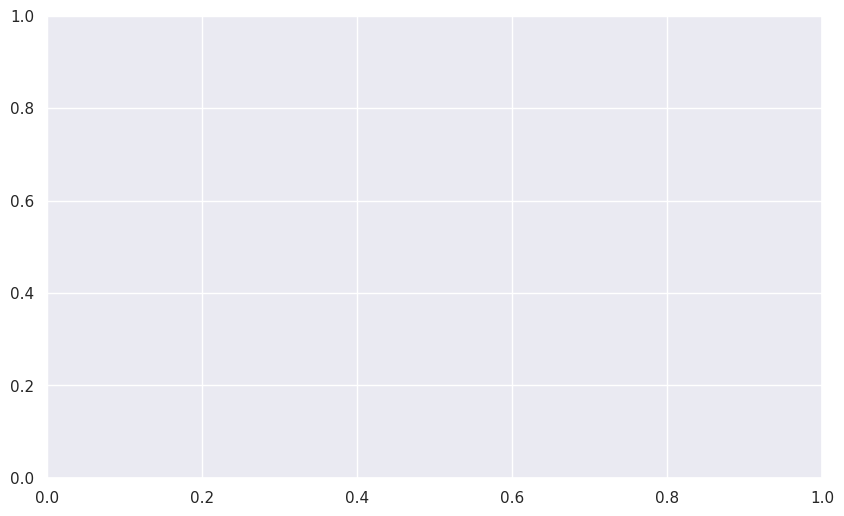

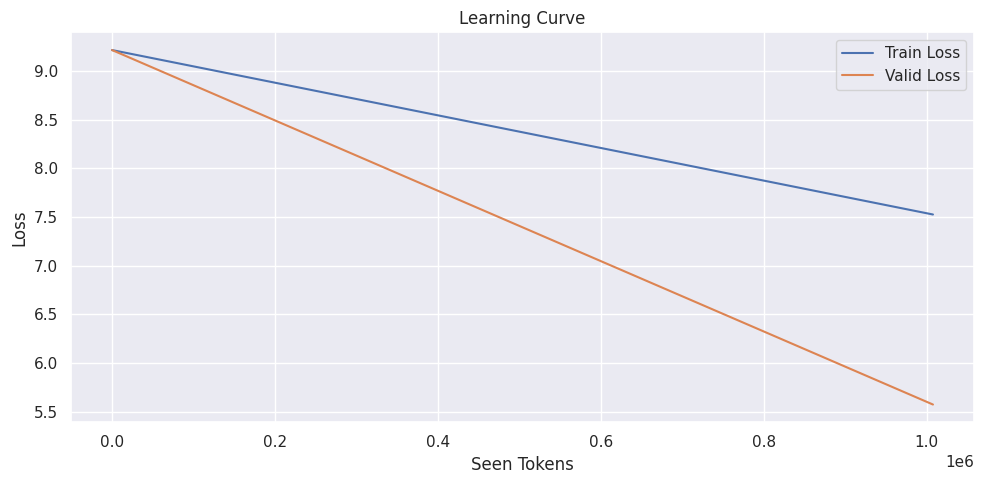

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last.
.
"
 The day. 

"
.
 He the was a, a. He a big, he.. The day and his her. ",, the, and and. "
The.
She was a. "
 She the little..

....................................................................................................

Sample 2:
In lastand he and the a.

....................................................................................................

Sample 3:
In last,. It was and.

 " She the, to. 

They. 

and to was a time and, he said,. He. The little. He had
very very.

He to day was so, a.

 " He was and to his. They and and her, "

....................................................................................................
----------------------------------------------------------------------------------------------------

✅ Generation finished.


Training:   3%|▎         | 2015232/65000000 [01:10<16:55, 62003.86tokens/s, Loss=4.8057, LR=3.20e-03, B/S=1.53]


🔍 Validation Loss: 4.2932
✅ Model Saved!


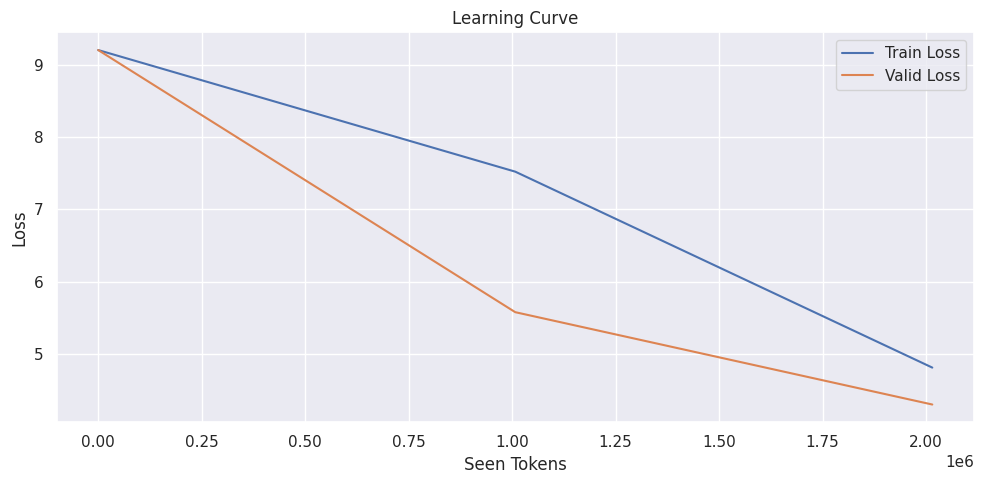

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, "Wow, Lily said, he had a big. They had a small little boy named
The mom.

....................................................................................................

Sample 2:
In last. You€
The girl said. He wanted to the boy's mom was sad.

He's dad were a little boy was a little
girl and said, a small little girl named Lily was a time, "I can play up in the girl was sad and his
hand and Lily. They are very scared. They did happy and a good and her friends. They saw a time, a
great day, but that the big box. They asked. He saw the garden." Lily and Lily, there and said,
there was so very excited.

He wanted to play and said. He was so happy.

The big boy named Lily. He
wanted to help the boy and saw a time, Lily said, "I'm a new. She said, "I have not go to the other
and said, you have a big, the little girl who wanted to help with it to the little girl who was a
big tree. They are so happy to the par

Training:   5%|▍         | 3022848/65000000 [01:50<16:54, 61105.73tokens/s, Loss=4.1172, LR=4.80e-03, B/S=1.31]


🔍 Validation Loss: 4.0039
✅ Model Saved!


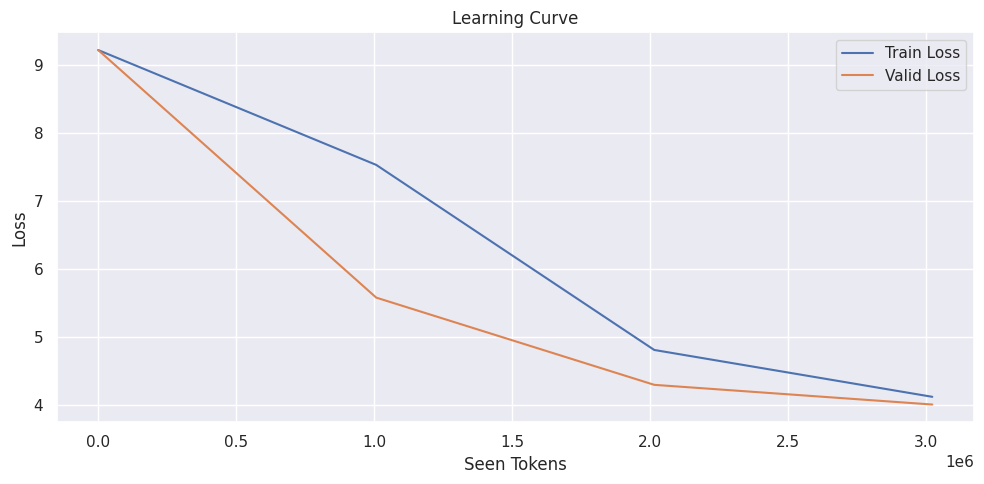

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastday, Timmy was very happy! 

The little girl was happy and started to be happy that it, "You don't
find it to play!" The little girl named Lily had a time! "It's mom said, she had to her mom said,
they were playing with it. "That's mom saw a time, she didn't you. But we go to the park.
But I
don't want for it. They were sorry and she could make her."
The bear's go. He took his mom went
back.

The boy who was sad. She said, "No, "It was playing in his mom said, "Thank you, "I will be a
man said. It was so happy with the little boy. It was so much. She saw a little girl was playing on
the dog.

....................................................................................................

Sample 2:
In lasttime, there was a time! She wanted to the sky. They ran up in the little girl named Spot and Lily
saw her. She said, "Yes, but he could help me."

The little boy. He was very nice and they could not
to go home

Training:   6%|▌         | 4030464/65000000 [02:30<16:34, 61326.85tokens/s, Loss=3.9210, LR=6.41e-03, B/S=1.23]


🔍 Validation Loss: 3.8849
✅ Model Saved!


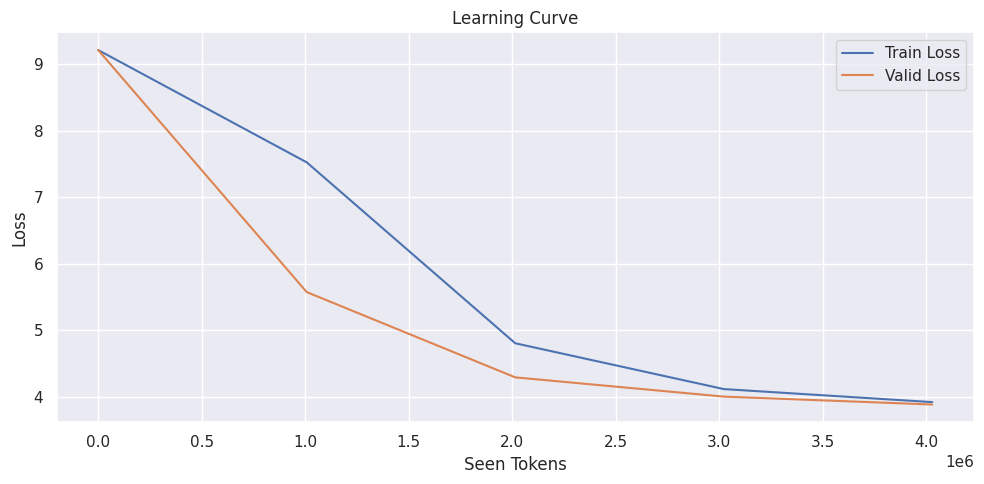

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, Timmy was so she saw a little girl named Lily was very big boy named Timmy was her friends in
the end and her mommy. She loved to her dad to help him on a little boy named Tim and said, but
Lily, "Thank you can we can't be careful and said it and she was so happy and the ball was very
much. It was very happy and said, Timmy's mommy was very excited. It was very happy and Lily. She
was very nice. She asked her mom and her to get to take her. 

After the park to the little girl
named Lily, Lily. He had never had been to the park.

After that day, "Can we can't know anything
and he would have a little girl, "Can't worry. She had was so much fun. 

Lily went to take a big
tree and he saw a new. 

The boy named Lily was a big car and she had a lot of the ball in the
little boy. It was the end, "What's friends." She was so happy and her and he was the little girl
and her mom, Timmy and he was a little girl.

......

Training:   8%|▊         | 5013504/65000000 [02:52<16:20, 61174.27tokens/s, Loss=3.8055, LR=7.97e-03, B/S=1.18]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_090921_tok5013504.pth (seen_tokens=5,013,504)


Training:   8%|▊         | 5038080/65000000 [03:10<17:11, 58127.75tokens/s, Loss=3.8051, LR=8.01e-03, B/S=1.19]


🔍 Validation Loss: 3.7126
✅ Model Saved!


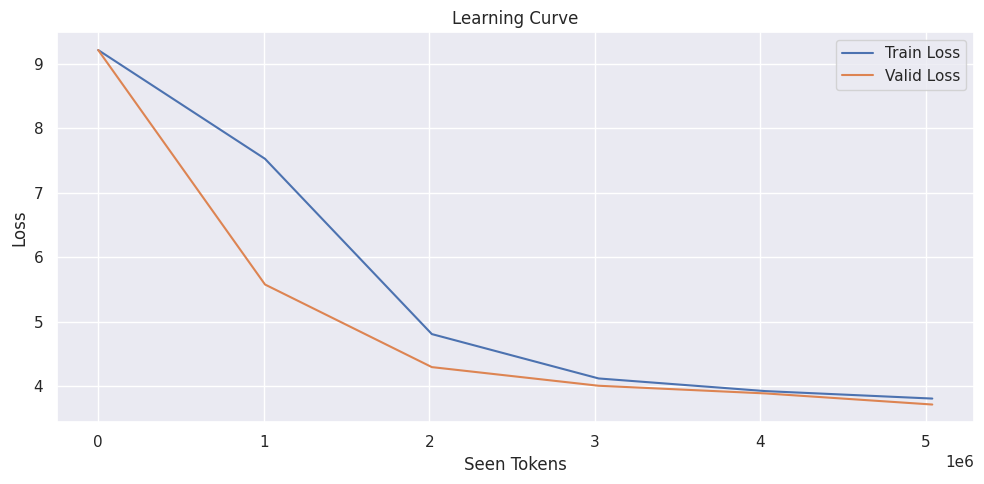

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, they were playing in her family. One day, the bear had the bear, the man. It was sad, "Yes,
Lily's play?"

Lily thought a big, and Lily, Lily was so fast after the lady and the man in the man.

....................................................................................................

Sample 2:
In lastof money and the world. It was a big tree.
Tom and said. The bird was very high in and her and her
mom, "I love my friend." She took it was so she could not to get the bird and Lily's mommy and said
to see some things on her mommy and Lily was not fun. He loved his friend. It was sad and said he
was happy because he would get out of her a big and ran around her dolls and the man and ran off.
She put out.
Lily felt sad because he wanted to her. She was scared and her and made her friend. She
wished she knew that it. He had a big and said they had a good things to her dad and gave her.

.................

Training:   9%|▉         | 6045696/65000000 [03:50<16:01, 61341.66tokens/s, Loss=3.6414, LR=9.61e-03, B/S=1.16]


🔍 Validation Loss: 3.5610
✅ Model Saved!


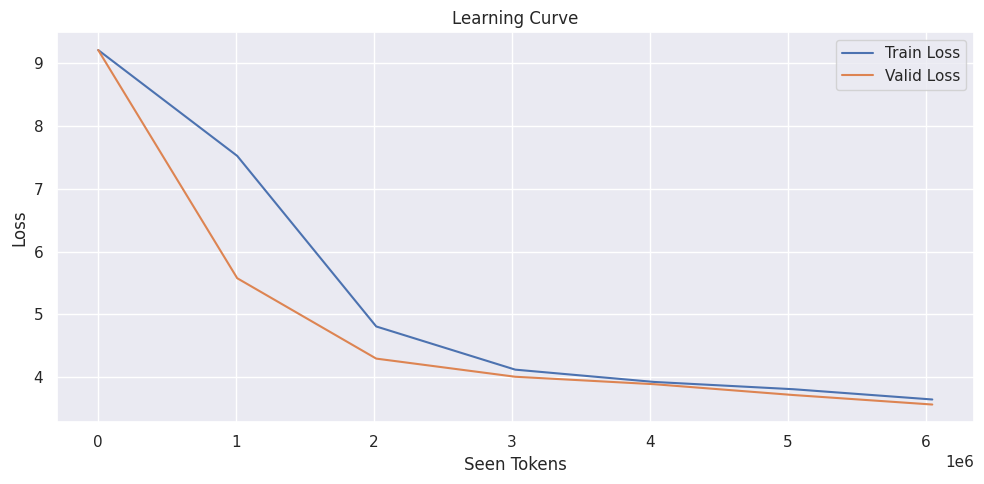

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, Mama was a little girl who was so she was a little girl called her friend. It had been so
proud of her mom. She said the little girl said, "Thank you, let's my mom. I'm my car. That's a kind
of you. I want to have your toy. Now, you are bad for my doll. I'm sad. I love you can I have you."
She smiled and said, "It will be my car?" His mom smiled and said, "Yes, let's mom, you have a
special. You don't want your car and I will be your car and play with the doll."

The friend, "Yes,
I have to be bad. You're welcome, you can make you have a nice. I don't like my car."

Tom and said,
"We can have you. That's a new car and Ben. But then it?"
Sam and Dad said, "Thank you want to me."
Lily was glad to play together with your favorite car. They both. The doctor. They had a new toy and
said, "You are not nice.

....................................................................................................

Sample

Training:  11%|█         | 7053312/65000000 [04:30<15:46, 61235.50tokens/s, Loss=3.4607, LR=1.00e-02, B/S=1.14]


🔍 Validation Loss: 3.3463
✅ Model Saved!


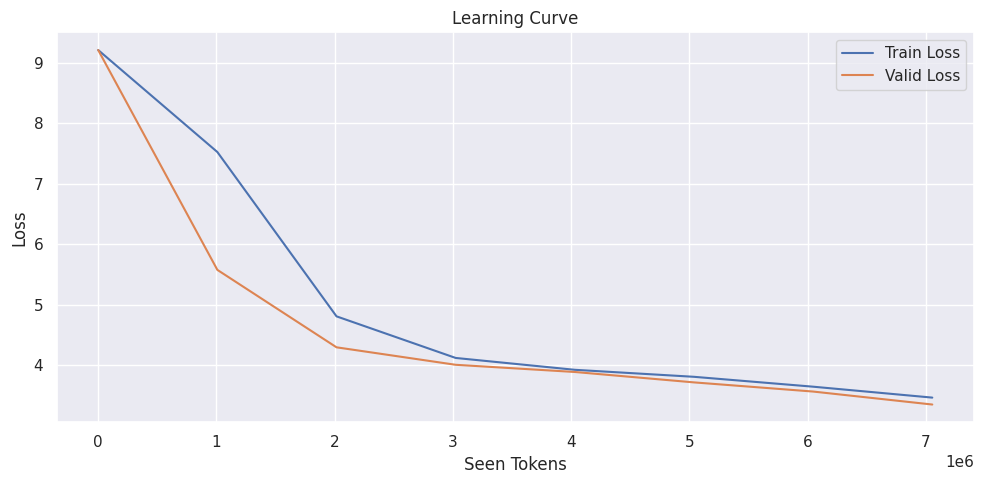

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, we have to be so he was a great time and the way out. It was an old and the way and the door.
The sun got there were both played together. He was having a long time to the slide and they were so
happy.

The little girl was so he knew she was also knew that she felt happy and he could see
something, but he could do it would always make the little.

Every day, when she saw a few of a
little girl and a little girl playing with her family. The baby was so happy and he went to make a
big hug.

The next day, Daisy's mommy told her mom to play with her new. They were so she was very
proud of the best friends and she could not safe.

....................................................................................................

Sample 2:
In lastday, there was walking in a little girl. She was playing with her friend, a big, and had a small
box. One day, she was shining and she was playing and started to the gar

Training:  12%|█▏        | 8060928/65000000 [05:00<15:34, 60918.01tokens/s, Loss=3.2520, LR=9.98e-03, B/S=1.14]


🔍 Validation Loss: 3.1544
✅ Model Saved!


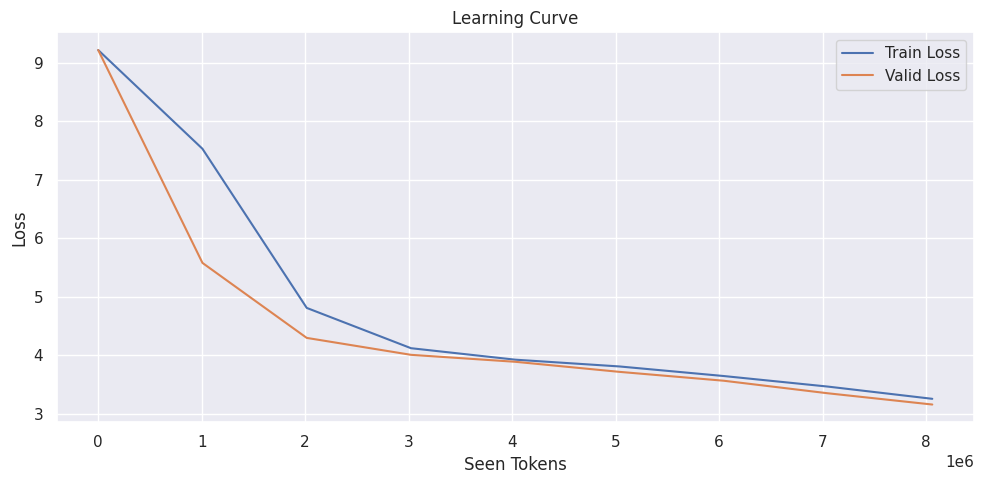

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, John and the boy named Red was excited. He wanted to take things. He was too much about the
day.

John and Joe saw a big mess. He thought it could try something hard to do something something
that it would be more. He was so excited that he didn't wait to go.

When he saw something in the
ground. He was a little, so it, and his friend, he wanted to help it.

He started to help but the
little girl was about him. He looked around. He ran to the garden to the kitchen. He was so happy
that the story.

....................................................................................................

Sample 2:
In lastday, he saw the garden in a little girl. She looked around and looked like something. She saw what
she wanted to help her.

Tom was not know what her mom. She was a big hug. She said, "Can I have to
do that?"

Ben smiled.

But as she did not see her mom. She wanted to help. She ran up to the door
to

Training:  14%|█▍        | 9068544/65000000 [05:40<15:19, 60842.67tokens/s, Loss=3.0782, LR=9.95e-03, B/S=1.12]


🔍 Validation Loss: 3.0250
✅ Model Saved!


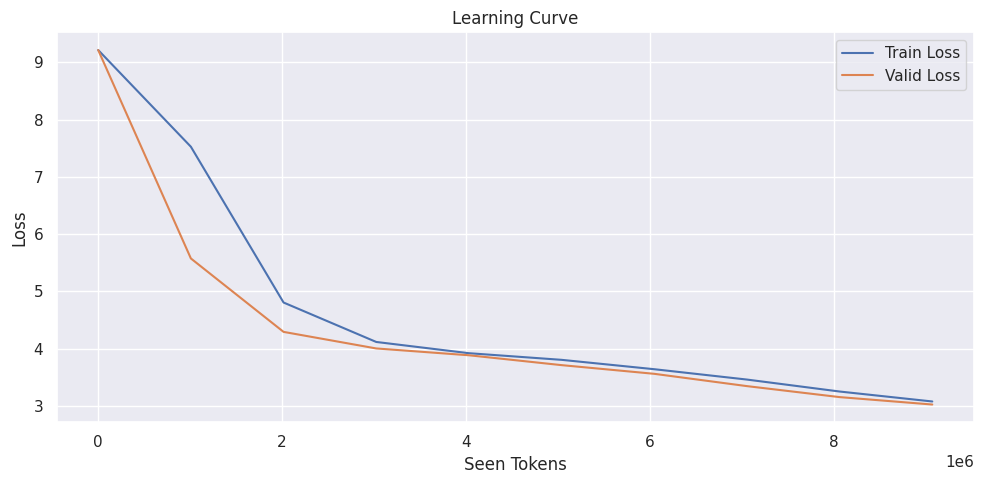

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, Lucy and Lucy were friends. They were playing in a big fish swimming in a big town, squirrels,
the fish were friends. Lucy and Sarah wanted to eat. They looked out of fish and said, "Hello, what
I want to play with me."

Lucy and Sue looked at all the fish. They saw a bird. They wanted to know
the fish, so he said, "Hi, you are you. What are you happy, little bird. Let's find it." The fish
said, "I want to eat!"

The bird went away and went back. The bird was happy to the pond. Tim felt
proud of the bird. Tim and Sue were happy again. They shared the fish to the bird. Tim was very
happy. The bird was very happy and happy. They played with the fish and played with them.

After the
day, Tim and Max was happy. They thanked the fish, and Sam. They played with the fish. They went to
the pond and saw a big dog. They laughed and saw the bird. Tom saw the fish and the fish. Tim was
happy with the fish. He wanted to g

Training:  15%|█▌        | 10002432/65000000 [06:07<15:02, 60958.12tokens/s, Loss=2.9418, LR=9.91e-03, B/S=1.11]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_091236_tok10002432.pth (seen_tokens=10,002,432)


Training:  16%|█▌        | 10076160/65000000 [06:20<15:35, 58712.90tokens/s, Loss=2.9402, LR=9.91e-03, B/S=1.11]


🔍 Validation Loss: 2.8985
✅ Model Saved!


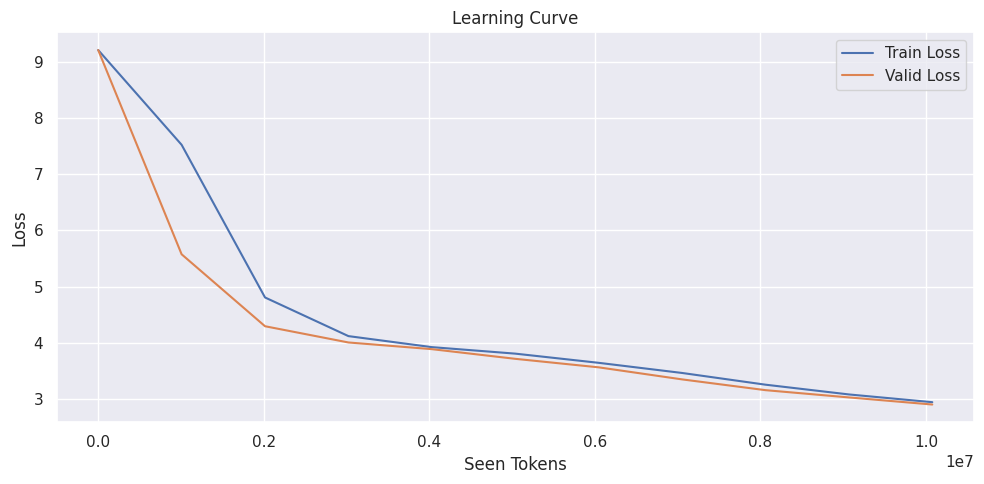

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, Sam was a very happy cat. Mia was very brave and said he would take a long nap.

Tom was sad.
He said, "That's wrong, Jack. I have a big friend. I have a toy. Can you help me?"

Tom and Sam went
to help. They both smiled and said, "Yes, but be careful. We can be fun together."

Bob was so
excited that he hugged the cat and said, "Thank you, Sam, Tom. Come on, let's play with me."

Tom
said, "You are welcome, Sam. Let's go and I can make you happy." Mia thanked Bob. They both were
both happy with the new friends.

....................................................................................................

Sample 2:
In last, she went to her mom for a big slide. She saw the shiny light with pink. She wanted to make
something yummy.

The little girl thought it was a good idea. She wanted to make a pretty sound. She
ran to the house and ran.

At the girl looked around her eyes and noticed the broken littl

Training:  17%|█▋        | 11083776/65000000 [07:00<14:40, 61249.50tokens/s, Loss=2.8451, LR=9.85e-03, B/S=1.11]


🔍 Validation Loss: 2.7930
✅ Model Saved!


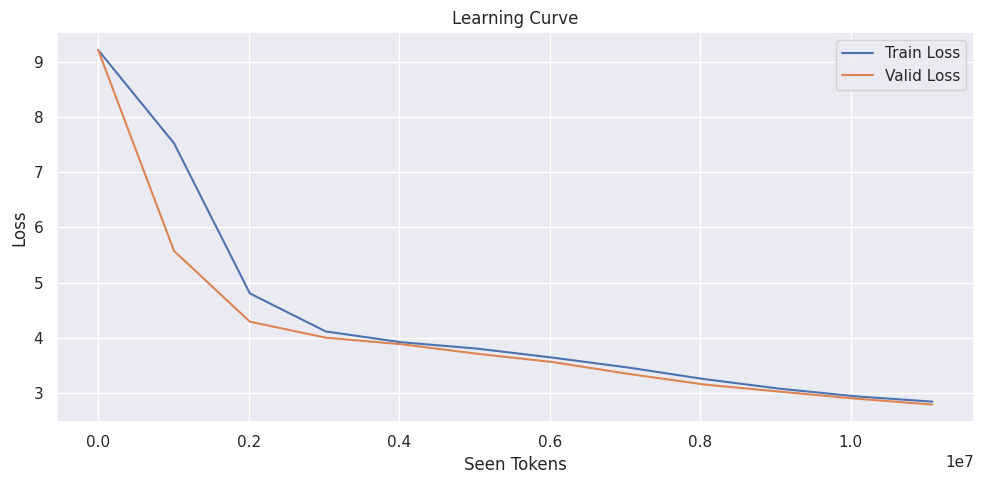

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big dog named Lily. Lily loved to play with her cat, especially her favorite doll, but
one day she would make her happy.

One day, Lily went to play with her doll, but when she woke up,
she saw a big, scary cat. The owner told her to make her feel better. Lily didn't want to take a
nap, but the cat would make the cat sad, but she didn't want to play again.

After a while, the cat
came to the park and said goodbye, Lily started to play together and seek in the garden. Lily felt
happy and grateful for being such a better. From that day on, Lily learned that being kind and
promised to help your friends.

....................................................................................................

Sample 2:
In lasttime, there was a little boy called Bob. He was 3-old in the house. He was feeling scared. He saw a
little scared of the tree and wanted to see what could do.

"What is that?" said Tim. 

Training:  19%|█▊        | 12091392/65000000 [07:40<14:20, 61479.10tokens/s, Loss=2.7544, LR=9.78e-03, B/S=1.11]


🔍 Validation Loss: 2.7218
✅ Model Saved!


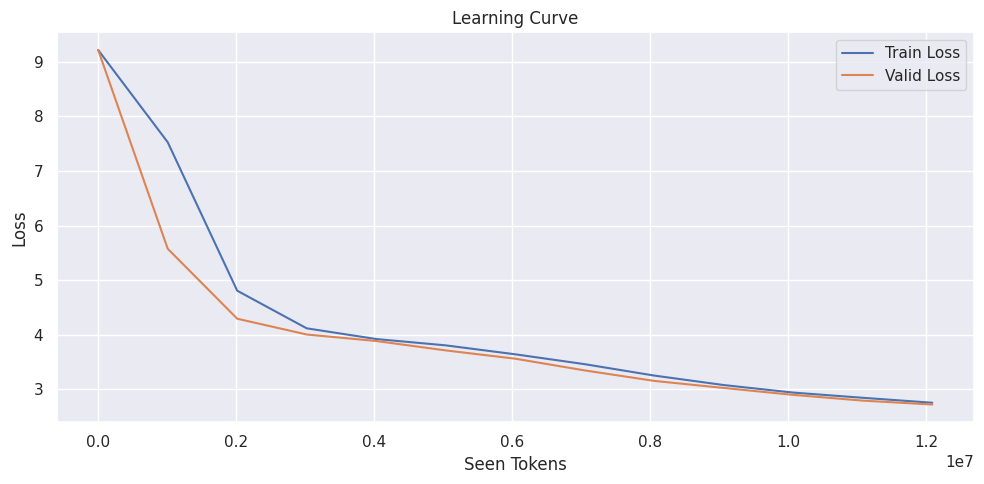

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, she was a little girl who loved to play. She was having all alone with her dolls, but she
always remembered the toys. She had always made sure to go to the room, so she was never seen again.
One day, she went to the park to play. There were all the park, she saw a nice cat. She went to tell
her mom about the dog and she said, "Hi, I found a big smile on my bed! Look at the porch!" Her mom
smiled and said, "I love my teddy bear! You could have been very nice and I can help you!"

So, she
went to the park to play with her mom. The teddy bear felt very proud, but she knew she had been so
kind. She was very happy and ran away.

....................................................................................................

Sample 2:
In lasttime, there was a little boy called Joe. He was a young boy and had a very special surprise. Joe's
best sister. One day, Joe decided to take a walk. As Joe arrived, Joe

Training:  20%|██        | 13099008/65000000 [08:20<14:04, 61438.02tokens/s, Loss=2.6830, LR=9.70e-03, B/S=1.10]


🔍 Validation Loss: 2.6683
✅ Model Saved!


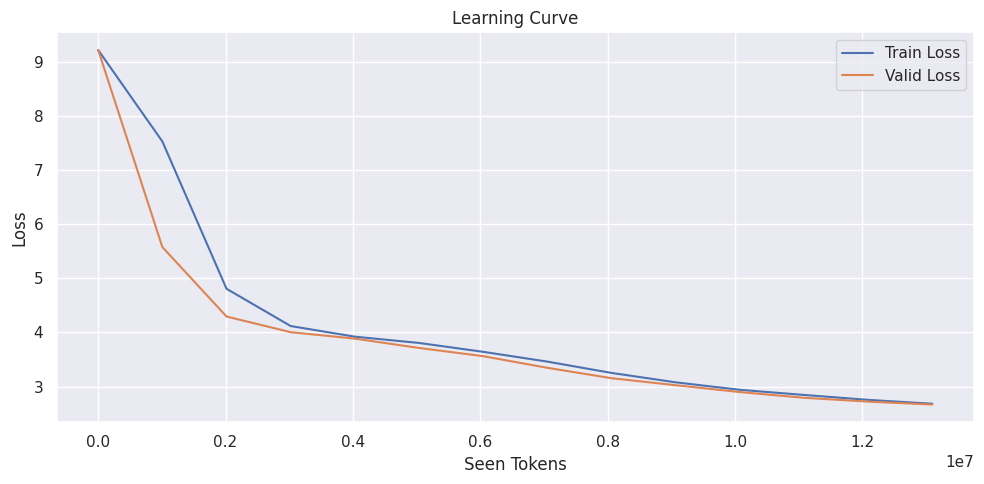

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, John was a big bear who was three years old and he was a very excited. 

"What are you doing,
John?" he asked.

"I'll do it first," the bear said. 

John was so excited. He ran around the garden
and was amazed about what he had.

But then he noticed something in the garden. It was a special
surprise, so he started to pick it up. The bear said, "Who's a new friend? It's surprise."

"I can
open it," said his voice. It was a secret.

John smiled. "This is so beautiful! I will find out what
it is."

Peter smiled and gave the big hug. "You are a great job!"

....................................................................................................

Sample 2:
In lastmorning, a little child was playing with a lot of toys. Every day, one day he would go fishing with
their new toy cars. It was a long time and he would get the cars.

The little girl was so happy he
wanted to join them too. He wanted to play a

Training:  22%|██▏       | 14106624/65000000 [09:00<13:47, 61527.91tokens/s, Loss=2.6314, LR=9.61e-03, B/S=1.10]


🔍 Validation Loss: 2.6205
✅ Model Saved!


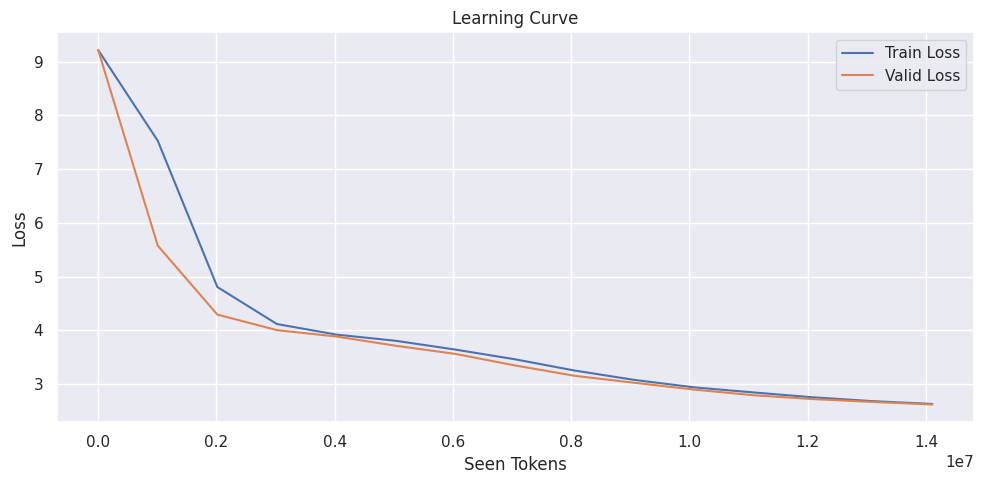

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, Tom was very sad because he had a little girl. He loved going to play with his friends, but
sometimes it was too late. Tom never got to stay in a park anymore. He went home and played with his
friends again. They all had a lot of fun.

"But, Tom, don't listen," Tom said. "Please, Mia, let me
play. Maybe, Tom is my game."

"No! We don't have your ball. Go away," he said. "But first, you
don't do not be a game. I don't want to be the game. Maybe you don't need to be careful."

Tom
looked at Lily. He wanted to play on the swings. He was a good boy who liked to learn.

"OK, Lily.
Let's go to the swings. Let's go and slide," Tom said. "I will come out of the sandbox. But I will
take a break."

The slide stayed dry. Tom did not see his toys. He was very sad and lonely. He did
not want to play with his mom. He ran to her mom and hugged him. She told him that they could go to
the swings and the sandbox. She said they

Training:  23%|██▎       | 15015936/65000000 [09:19<13:34, 61396.33tokens/s, Loss=2.5723, LR=9.52e-03, B/S=1.09]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_091548_tok15015936.pth (seen_tokens=15,015,936)


Training:  23%|██▎       | 15114240/65000000 [09:40<13:51, 60007.07tokens/s, Loss=2.5706, LR=9.51e-03, B/S=1.10]


🔍 Validation Loss: 2.5628
✅ Model Saved!


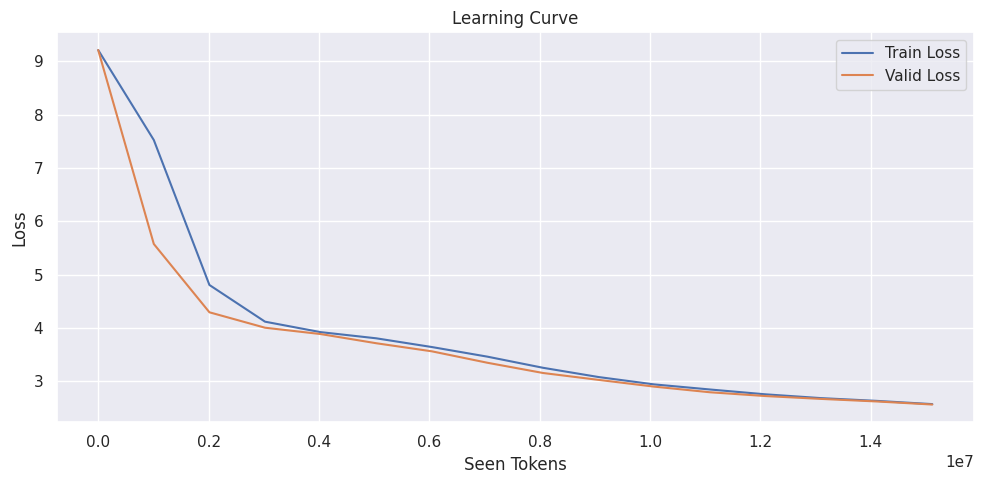

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, it was time for breakfast. The sun was so soft and warm in the warm sun. 

One morning, the
mommy went to the park and saw the park. She smiled and gave the birds the flowers to see. It was
very happy and said, "Let's go to the park." 

The sun was so happy and they all started to jog.
They were all so much fun playing in the field. 

The sun became good friends and they spent the
rest of the park together. 
The sun was shining brightly and the sun was filled up in the park.
The sun was so peaceful and beautiful, they all lived happily ever after.

....................................................................................................

Sample 2:
In last, they saw a small, yellow ball, and it was very tall. 

"Let's play again!" asked the boy. 

"Yes,
please," said the boy.

"Let's try something else!" 

The boy and the boy thought for a minute and
then they all together and then they went out of 

Training:  25%|██▍       | 16121856/65000000 [10:10<13:19, 61119.86tokens/s, Loss=2.5393, LR=9.39e-03, B/S=1.09]


🔍 Validation Loss: 2.5204
✅ Model Saved!


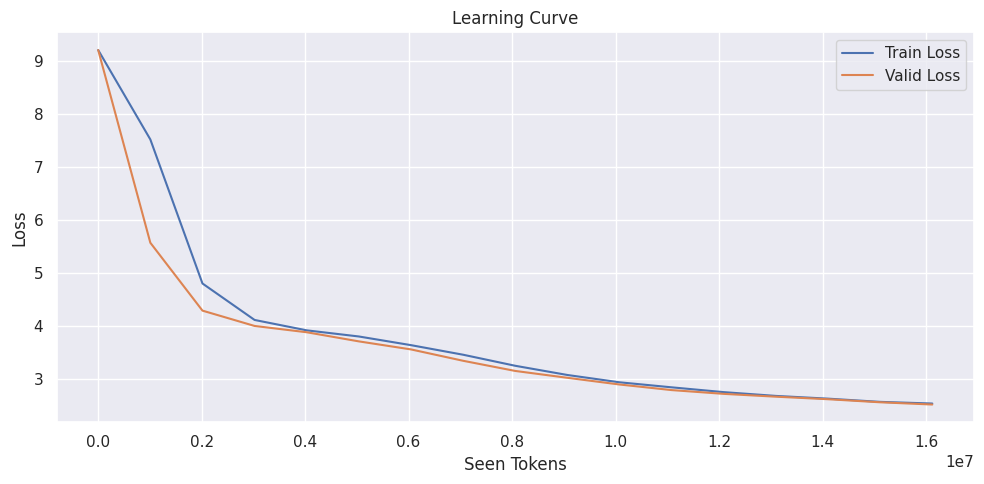

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, Tom was walking in the park, there was a little girl named Jane. She saw a beautiful bird with
its eyes. It was bright, fluffy and had a yellow eyes and was very small. Lucy was very happy!
"Hello, I'm Sam. I'm just three and I don't know you are a queen."

"Hi, I'm Tom. I am three years
old. Can we go to the tree?"

"Yes, they," said Anna. "We can't believe you're. It will be safe."
The voice said, "That's not be kind. You don't know. We can have to take care of it. That's why it's
why it's not safe?"

Lucy thought for a moment. She thought that she had been brave enough to be
brave and help. She had an idea. She said, "Okay, let's help!"

They put the branch in their pocket
and went to their mom. She put them on their shoulder and kissed the tree.

"Good job, Tom!" said.
"We will be nice to the wind. We can keep our lives."

Tom and Mia felt happy that they had helped
each other to be safe. They learned tha

Training:  26%|██▋       | 17129472/65000000 [10:50<13:02, 61207.96tokens/s, Loss=2.5069, LR=9.26e-03, B/S=1.09]


🔍 Validation Loss: 2.4851
✅ Model Saved!


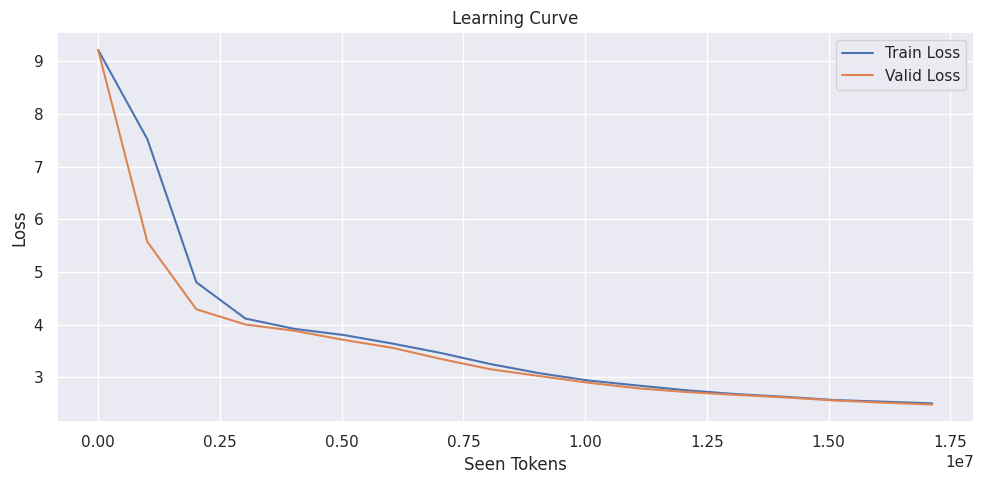

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime there was a big house and it was very tall and dark. On this day she was in her cozy bed, and
she loved to sleep in her bed. She would sit in her cozy bed and play with her toys and dreamed of
fun adventures.

One day, she decided to have a dream. She wanted to find a cozy place where she
went, and she found a small toy box with many colorful toys and a big red, red car. She ran inside
all over and tried to open the box, but it was too high in the box. She found it, so she could not
find it.

Lily's mom came into the room and saw her mom waiting for her to go inside. She said it
was a toy. Lily said, "I want to take my toys from now, Mom." Lily was excited and said, "Thank you,
Mommy. I love you so much." They walked outside and played in the park, holding toys, and playing
with their toys.

....................................................................................................

Sample 2:
In lastm

Training:  28%|██▊       | 18137088/65000000 [11:30<12:45, 61213.27tokens/s, Loss=2.4626, LR=9.12e-03, B/S=1.09]


🔍 Validation Loss: 2.4568
✅ Model Saved!


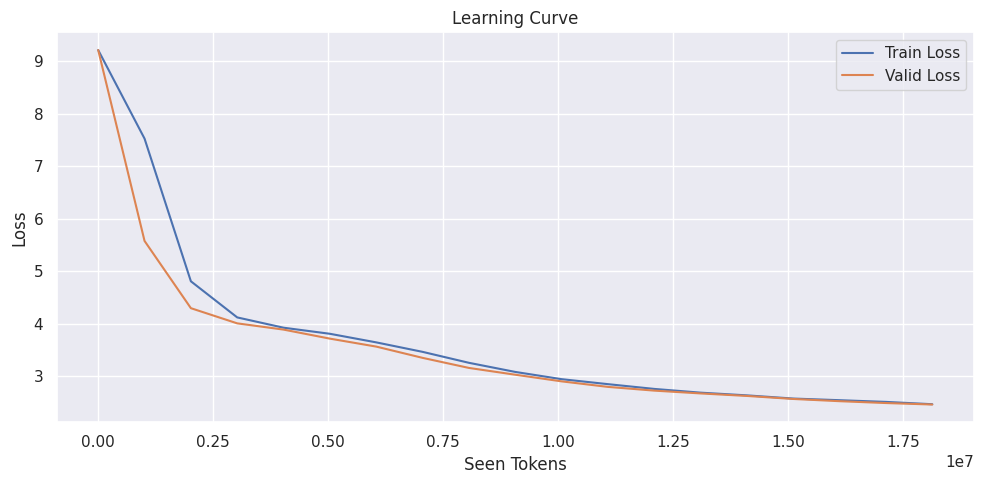

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastday, he was feeling very lonely. He didn't know why. He looked around. He had been scared and
started to cry.

He went to the park and saw a bird flying towards him. The bird was not afraid him.
It flew away from the bird and landed on a leaf. He was scared and scared.

But the bird was still
in the tree. It was a bad cat. It wanted to be safe. He started to cry. But the bird flew away.

The
bird had to stay on a branch. The bird was not alone.

He was alone. He wished he could find a way
to sleep. He stayed alone in the tree and had no friends to go home.

....................................................................................................

Sample 2:
In lasttime, there was a little boy called Joe. He was very eager to take something with him. He liked to
go out and explore the woods. One day, he saw a beautiful thing in the distance. It was a big, round
thing! 

Joe wanted to try it. He ran closer.

Training:  29%|██▉       | 19144704/65000000 [12:10<12:34, 60755.13tokens/s, Loss=2.4337, LR=8.97e-03, B/S=1.09]


🔍 Validation Loss: 2.4248
✅ Model Saved!


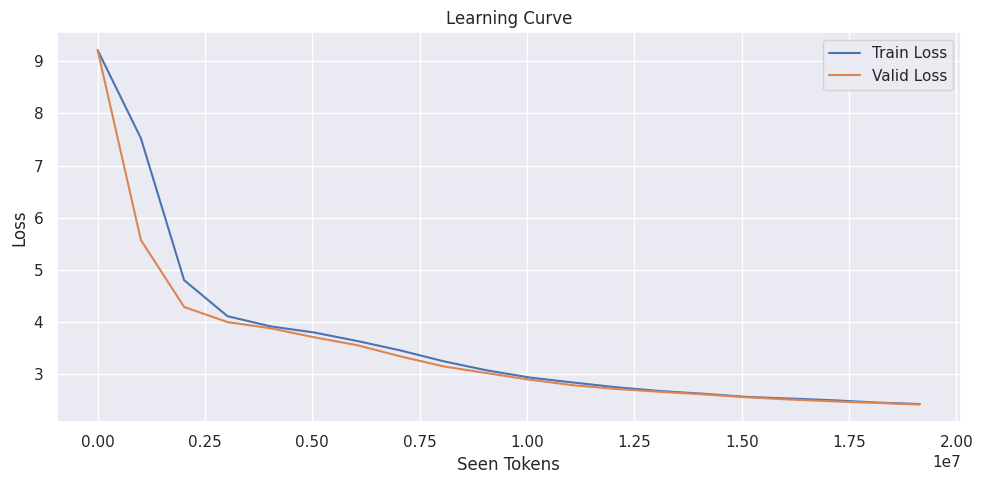

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, Tom was feeling brave. He wanted to go to the store, but he had never seen again. He went to
the store and saw the cashier he was still excited. He took the menu to his mom, and gave him food.
His mom was so proud of him. She gave Max a big hug and said, "Good job!" Tom was so excited and he
ran back to his room. 

He put the menu in the oven to take the menu. As he went home, his mom said,
"Jack, you are the best helper ever!" She said, "I'm glad you!"

....................................................................................................

Sample 2:
In last, there was a small house that had lots of toys. The box was empty and there were lots of fun. 

One
day, she was playing when she heard a noise inside the window. She looked up at the window and saw
it was dark and dark. She asked her what was that she couldn't play with. Her mom told her that her
special thing was about and that she didn't 

Training:  31%|███       | 20004864/65000000 [12:31<12:12, 61430.60tokens/s, Loss=2.4286, LR=8.83e-03, B/S=1.08]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_091900_tok20004864.pth (seen_tokens=20,004,864)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_090921_tok5013504.pth


Training:  31%|███       | 20152320/65000000 [12:50<12:27, 59985.16tokens/s, Loss=2.4189, LR=8.81e-03, B/S=1.09]


🔍 Validation Loss: 2.4067
✅ Model Saved!


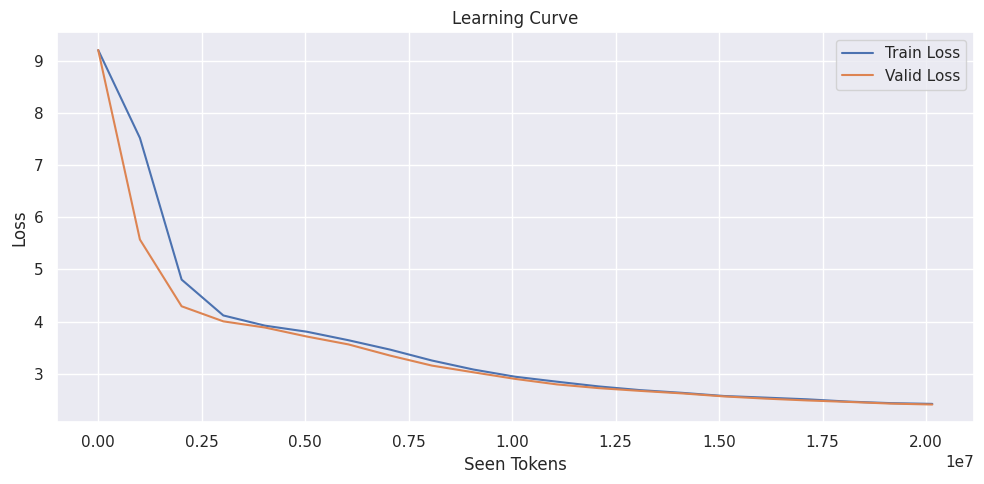

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big box, colorful box. Inside the box was a secret box full of books, some books and
some books inside.

The people were very happy. They did not care of what it was. But the little
girl wanted to open the box.

The little girl looked and saw that the box was empty. She had never
seen before. She opened it. Inside was a box with many colorful frosting.

The small girl was so
happy. She opened the box and saw the key. Inside was a surprise, a tiny box. It was a toy box!

The
little girl was so excited, she opened the box and the box opened. Inside, they found a key. Inside
were a key inside.

The little girl opened the lock and opened the box. Inside was a open box.
Inside. Inside the box was a surprise. Inside was a box with some shiny sprinkles inside. 

The
little girl opened the box and opened the box. Inside, there were two toys, balloons, and toys, and
toys. 

The little girl was so happy to have

Training:  33%|███▎      | 21159936/65000000 [13:30<11:54, 61354.96tokens/s, Loss=2.4048, LR=8.64e-03, B/S=1.09]


🔍 Validation Loss: 2.3836
✅ Model Saved!


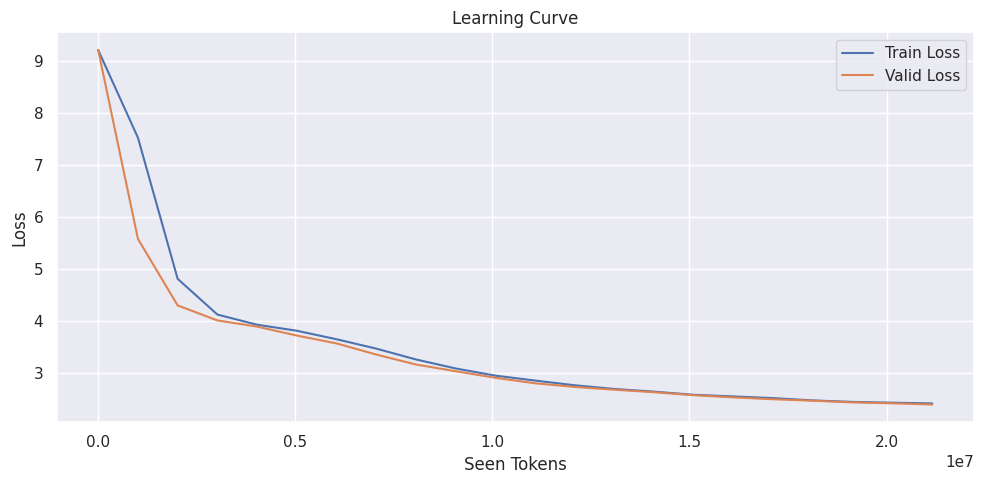

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a small girl named Daisy who was very excited. She had lots of energy and all around the
world in the world. She wanted to join in the world. She started to run around and play in the
garden and around and around in the garden. 

One day, Daisy went to the garden and saw a big puddle
of dirt. She wanted to play with it, but it was too tight and Daisy didn't know. She looked up and
saw a small rock and it was so heavy! She decided to go over to get a closer look.

As Daisy ran,
she saw a big rock and wanted to go on it. She ran over and started to get it. When she reached the
bottom, Daisy saw a big rock! It was so beautiful! Daisy and the rock became very pretty! Daisy had
never seen anything before!

"Look! I'm so pretty!" Daisy exclaimed.

Daisy smiled and said, "You're
welcome! I'm so glad you're there!".

Daisy was so happy and she hugged the rock tight. Now, Daisy
and the rock went back home. From 

Training:  34%|███▍      | 22167552/65000000 [14:10<11:39, 61207.28tokens/s, Loss=2.3957, LR=8.46e-03, B/S=1.09]


🔍 Validation Loss: 2.3576
✅ Model Saved!


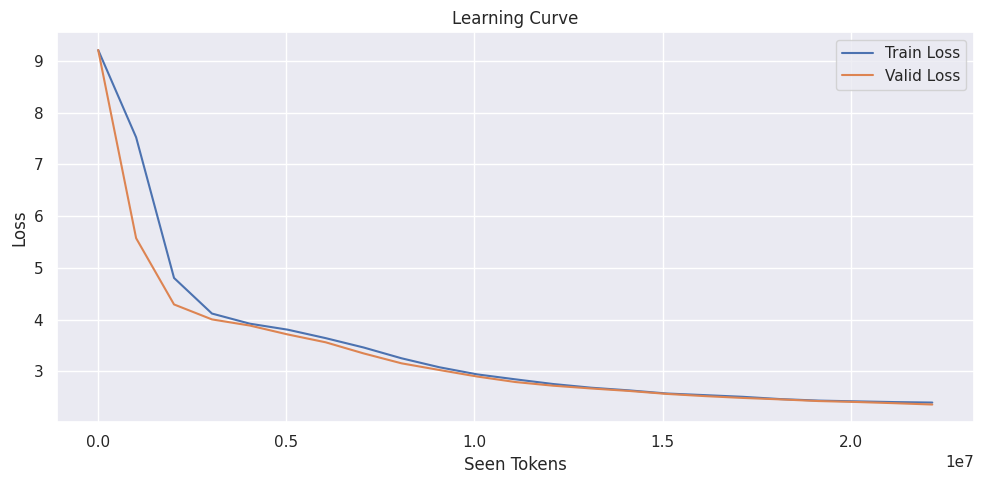

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a small girl called Lisa. She was three years old and liked to explore the house and
look for treasure. One day, she decided to find a treasure for her friends. She put her crown, and a
special coin that she found in her home.

Lisa was so glad that she kept exploring and exploring.
She kept her crown safe and dreaming. When she found her crown, she saw it, but it was very big and
it was very big and big and sparkly. She asked her mom if she could go for the gold coin to find it
for herself. Lisa was so excited and started to explore.

At the store, Lisa was so excited to see
the gold and she couldn't wait for the gold coin. She put on her hat and went to the store and got
to the treasure. Lisa was so excited to explore it, when she saw it, and she couldn't wait to see
all the shiny silver coin.

Lisa kept exploring until the next day she found. She looked for
treasure and searched around in the forest,

Training:  36%|███▌      | 23175168/65000000 [14:40<11:20, 61445.07tokens/s, Loss=2.3403, LR=8.27e-03, B/S=1.09]


🔍 Validation Loss: 2.3363
✅ Model Saved!


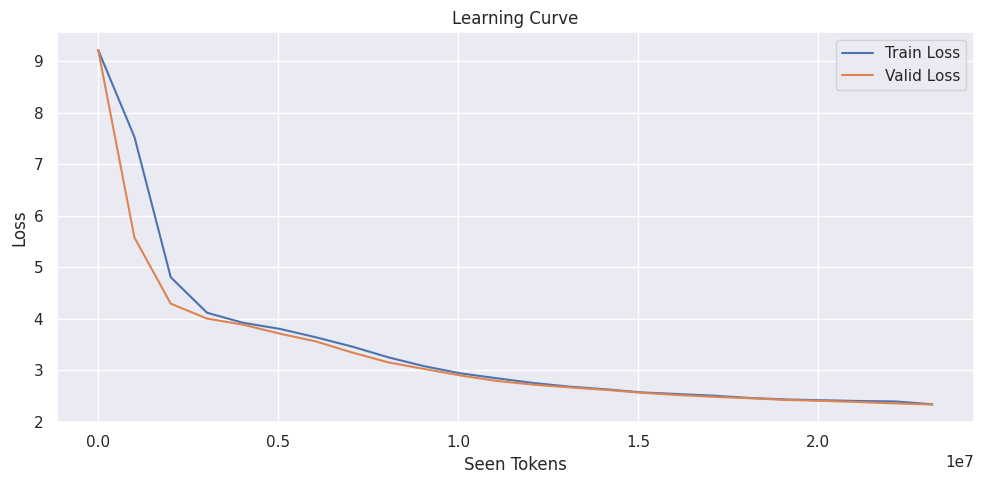

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, Sam was feeling very happy. He had a special toy. He liked to pretend that were all he
could have in his own. He had a toy truck that he could go with him every day, and he would drive to
play with it.

One day, Sam's mom had an idea. She asked him to fix the toy with a long tail. Sam
was so excited to share the toy with her friend. He grabbed the toy car and drove it home.

But Sam
didn't know how to fix the toy, it was not easy to drive it. She thought about it and thought it was
important to use it.

Sam was not happy to share the toy, but he thought it would make a new friend.
So he went back to the store and found a nice spot under the ground. He put the toy away and the toy
car, and the toy car drove away. 

Now, the doll was a good friend to share the toy.

....................................................................................................

Sample 2:
In last, there was a happy littl

Training:  37%|███▋      | 24182784/65000000 [15:20<11:04, 61448.68tokens/s, Loss=2.3289, LR=8.07e-03, B/S=1.08]


🔍 Validation Loss: 2.3236
✅ Model Saved!


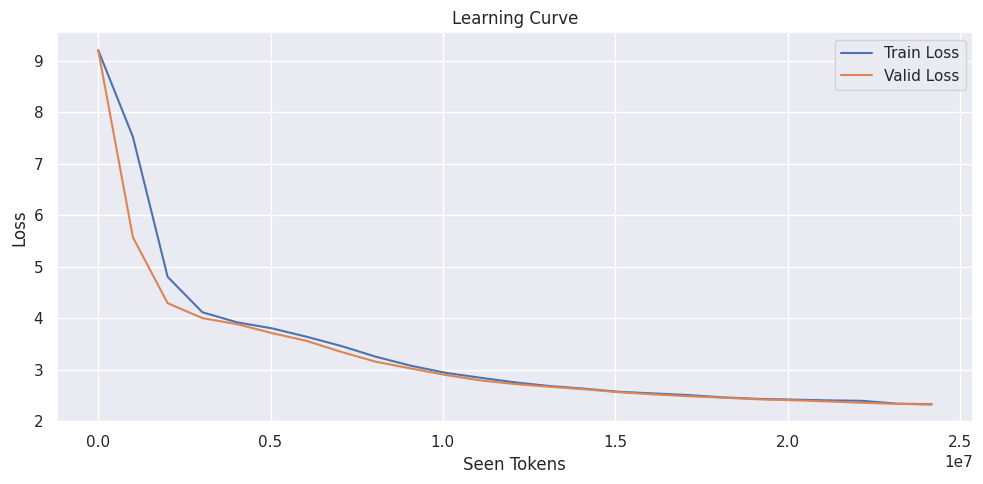

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, there was an amazing, bright, dark, white dog named Tim came to him. Tim saw the dog with
big eyes and wanted to go out to play with him. He walked to his big, green dog and barked in
delight. Tim was so happy to see the dog sitting on her feet.

But then, Tim felt something tickling
his body. He looked around and saw the dog barking in the air. Tim was very scared and scared. He
ran away into the sky and saw a little bird outside. The bird flew away. Tim was so sad. But then,
he saw a bird flying down. The bird looked very high and low. Tim thought it was very cute and ran
away.

The next day, Tim decided to go on an adventure. He found a new spot in a big forest. He saw
a big frog sitting on a tree. The frog was very sad and he couldn't get back. The bird flew away and
Tim was very sad. He went home with his new friends.

...................................................................................

Training:  38%|███▊      | 25018368/65000000 [15:42<10:53, 61184.29tokens/s, Loss=2.3170, LR=7.91e-03, B/S=1.08]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_092211_tok25018368.pth (seen_tokens=25,018,368)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_091236_tok10002432.pth


Training:  39%|███▉      | 25190400/65000000 [16:00<10:56, 60684.79tokens/s, Loss=2.3168, LR=7.87e-03, B/S=1.08]


🔍 Validation Loss: 2.3088
✅ Model Saved!


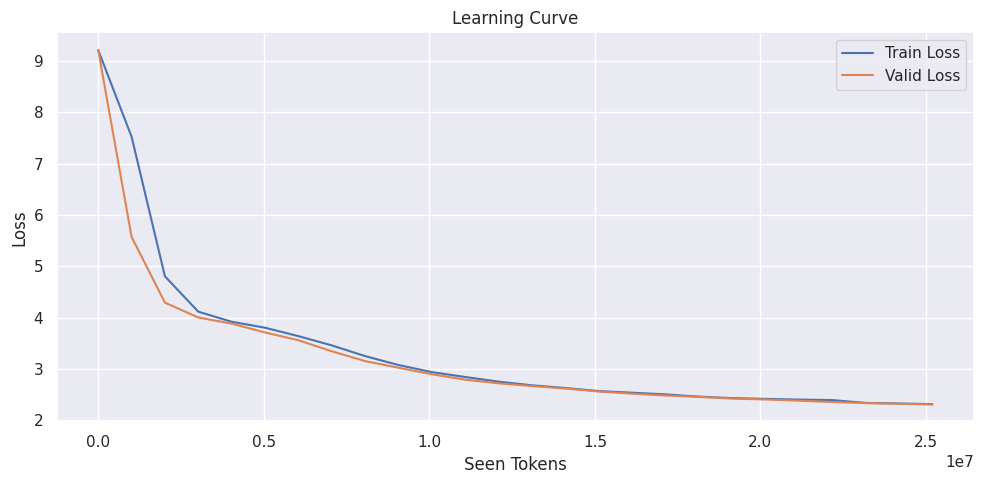

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old owl. He was very kind and always kept things.

One day, the fox wanted to
make a new animal. He put on his head and he started drawing pictures on his head. But suddenly his
head fell from the sky, he fell from his hand.

The rabbit was very sad. He wanted to play with his
friends. So, he ran outside and got out from her friends. He was still sad.

He looked down at her
and said, â€œPlease don't be sad, I have a toy gun in my pocket. I can't have it anymore!â€ So the
rabbit hopped away and soon he was feeling very sad.

Finally, he decided to go home. He found his
own toy gun and ran back home. He had learned an important lesson.

....................................................................................................

Sample 2:
In last, there was a boy named Max. Max was very happy because his mommy always gave him a big hug.

One
day, Max and his mommy went for a walk. Max wante

Training:  40%|████      | 26198016/65000000 [16:40<10:33, 61254.39tokens/s, Loss=2.3041, LR=7.66e-03, B/S=1.08]


🔍 Validation Loss: 2.2919
✅ Model Saved!


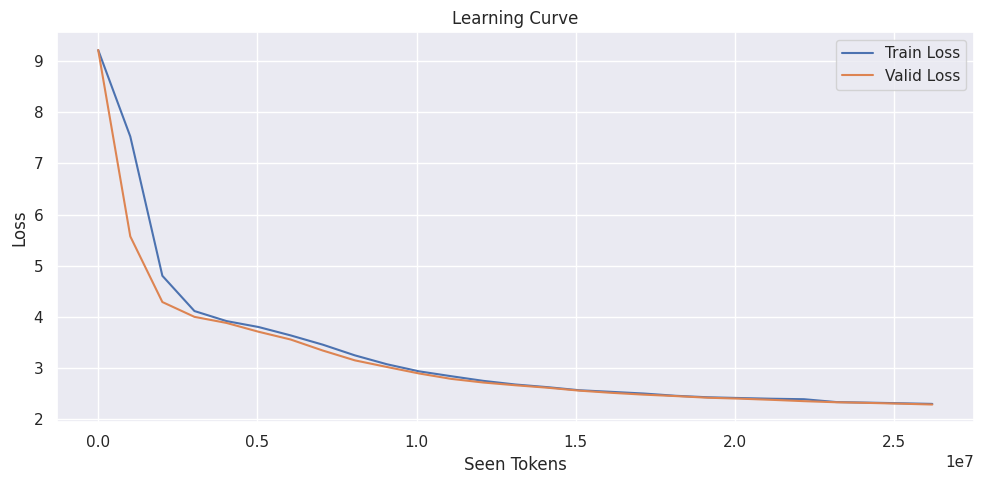

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, there was an old woman who lived in a big house. She lived in the house every morning and
had lots of fun. One day she and her family decided to go for a walk in the forest. They saw some
beautiful stars and birds. They were very happy and excited.

At the end of the day, the little girl
and her family had a great time. They saw lots of birds and trees, and birds. They were singing and
having a great time. They sang a happy song and song until the sun was shining brightly.

When their
journey was over, they saw a big tree with lots of colorful trees. It was so beautiful and
beautiful. The little girl's family was so happy.

The little girl was very happy that she had found
the tree and she was so happy. She wanted to go back home and see its family. She took her hand and
they walked back home feeling proud. 

The girl's family smiled and said goodbye. She felt so proud
of her family and thanked them for re

Training:  42%|████▏     | 27205632/65000000 [17:20<10:16, 61341.13tokens/s, Loss=2.2745, LR=7.44e-03, B/S=1.08]


🔍 Validation Loss: 2.2783
✅ Model Saved!


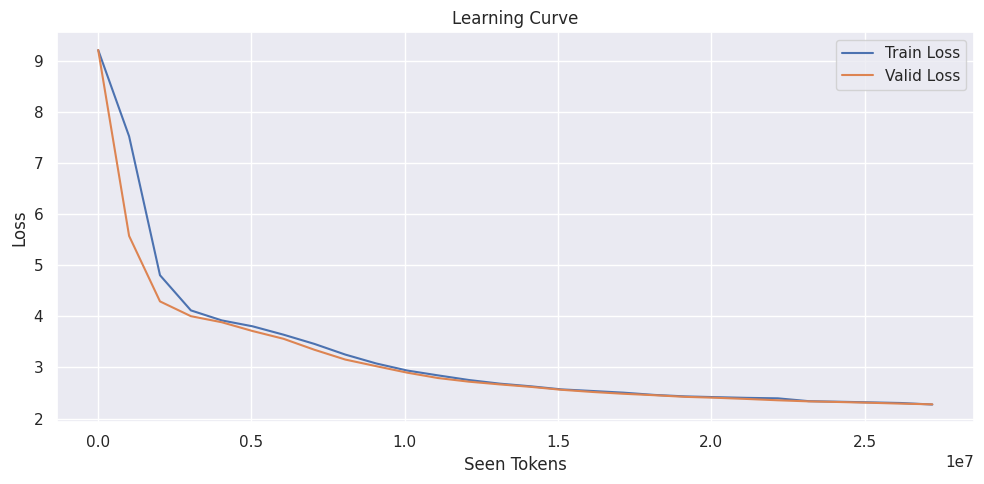

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, there was an enormous bunny named Max. Max was a big bunny with a red nose and he loved to
fly in the forest. One day, Max saw a big bird fly and wanted to fly away. He flew to the nest and
flapped his wings.

Max saw a big butterfly with black wings. The butterfly flew out of the nest and
landed on Max's nest. Max watched and felt safe. Suddenly, he saw a bird flying down. Max was flying
and flew up to the nest.

Max saw the butterfly, who was flying high up on it. It was so big and
strong that he flew back into the nest. Max was so happy and flew back to his nest. He could soar in
it and feel the soft sun in his feathers.

But then, a big wind came and flew down. Max was
frightened and ran up to the nest. He tried to help the bird, but it was too late. Max got scared
and flew away. He ran as fast as he could and caught a tree. From that day on, Max learned many new
things and never got too close to the o

Training:  43%|████▎     | 28213248/65000000 [18:00<10:05, 60730.36tokens/s, Loss=2.2727, LR=7.22e-03, B/S=1.08]


🔍 Validation Loss: 2.2649
✅ Model Saved!


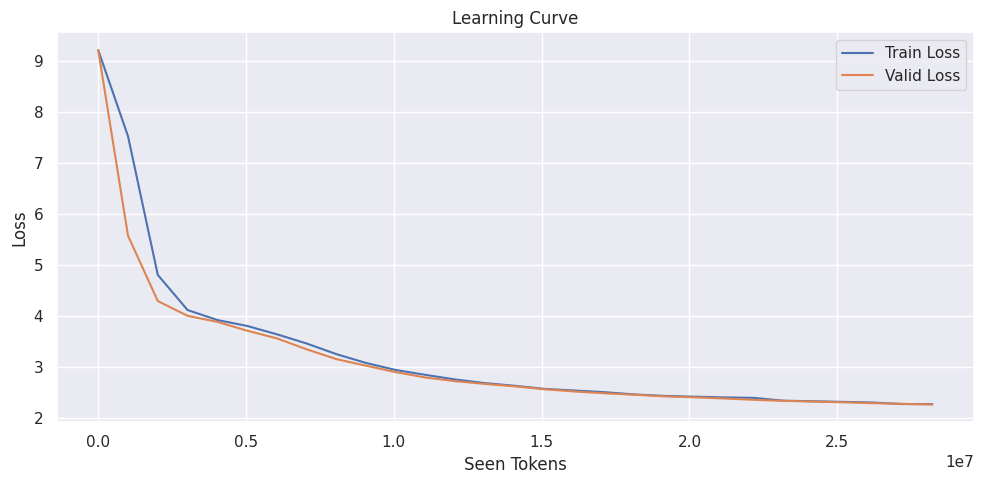

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, her mom said she needed to be brave and always take her to get her a special key from her.
Lily was so happy and thanked her mom.

But then, Lily's older brother said they needed to find an
adventure. Lily was very sad and didn't know what to do. But then, she remembered what her mom had
told her about. It was a little very wise to take things and always remember the important key.

....................................................................................................

Sample 2:
In lasttime, there was a little girl called Lucy. She was three years old and had a lot of fun at school.
Lucy loved to learn new things and play with them. 

One day, Lucy was walking around the park when
she saw something special. It was a big, colourful bird and it made Lucy really happy.

Lucy asked
her mom, "Can I do it?" Her mom smiled and said, "Yes, you can try this bird!"

So Lucy got a stick.
She tried it an

Training:  45%|████▍     | 29220864/65000000 [18:30<09:43, 61308.53tokens/s, Loss=2.2495, LR=6.99e-03, B/S=1.08]


🔍 Validation Loss: 2.2504
✅ Model Saved!


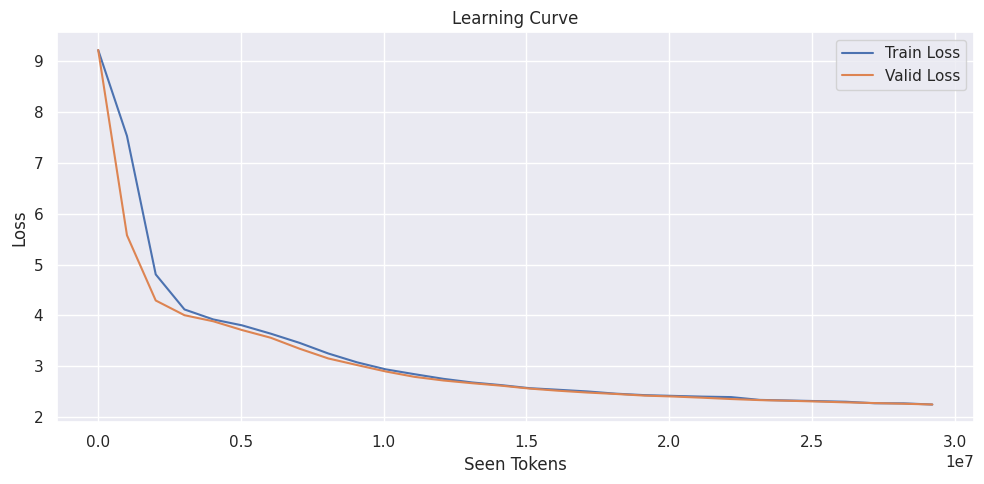

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old woman who wanted to go to the market. Her parents told her about it, but her
parents said no.

The woman was sad and said â€œNo, no. You can go with a lot of money.â€

The woman
was upset. She said: â€œWhy donâ€™t you go outside and try to find a way?â€

The girl was very
scared. She quickly ran to the market and grabbed a small piece of wood. There were lots of tools.
It was old and heavy! The woman smiled and said â€œYou can have enough money for you!â€

The woman
was so happy to have a reward. She said â€œThank you, I can help you.â€

The woman was so happy and
thanked her parents. Together they got a little bit of tools. They had sold the items they paid off
and gave her a big hug.

....................................................................................................

Sample 2:
In last, there was a small house and it looked so pretty. The tree was full of soft flowers and f

Training:  46%|████▌     | 30007296/65000000 [18:55<09:34, 60961.22tokens/s, Loss=2.2303, LR=6.81e-03, B/S=1.08]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_092524_tok30007296.pth (seen_tokens=30,007,296)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_091548_tok15015936.pth


Training:  47%|████▋     | 30228480/65000000 [19:10<09:36, 60315.44tokens/s, Loss=2.2372, LR=6.76e-03, B/S=1.08]


🔍 Validation Loss: 2.2398
✅ Model Saved!


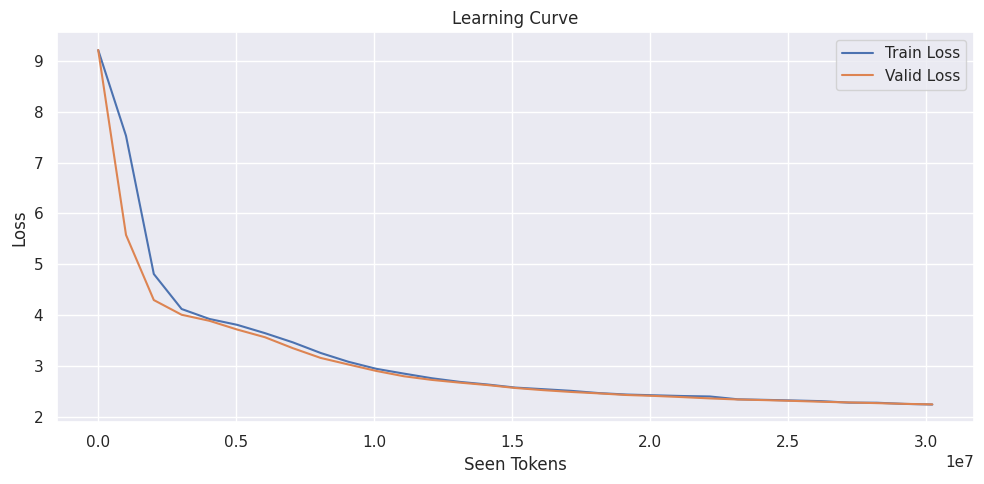

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a girl named Daisy. Daisy was very sad. She wanted to go on an adventure, but she knew
she had to be careful and not to slip.

Daisy asked her dad if they could go on the trail with her.
Her dad said no, but Daisy was too grumpy. He said she would be happy again and they both went on
their adventure.

After a while, Daisy saw her way back home. She was still feeling so sad, but she
knew she had to go back to the park. Daisy felt very happy and grateful. 

The day of Daisy went on
the trail and Daisy continued walking until it was time to go home. She was happy that the trail was
still there to come back and explore. She was glad that she had been more careful when she was brave
and she knew that she was safe!

....................................................................................................

Sample 2:
In lastmorning, there was a little girl called Sarah. She was three years old and lo

Training:  48%|████▊     | 31236096/65000000 [19:50<09:10, 61359.01tokens/s, Loss=2.2334, LR=6.52e-03, B/S=1.08]


🔍 Validation Loss: 2.2286
✅ Model Saved!


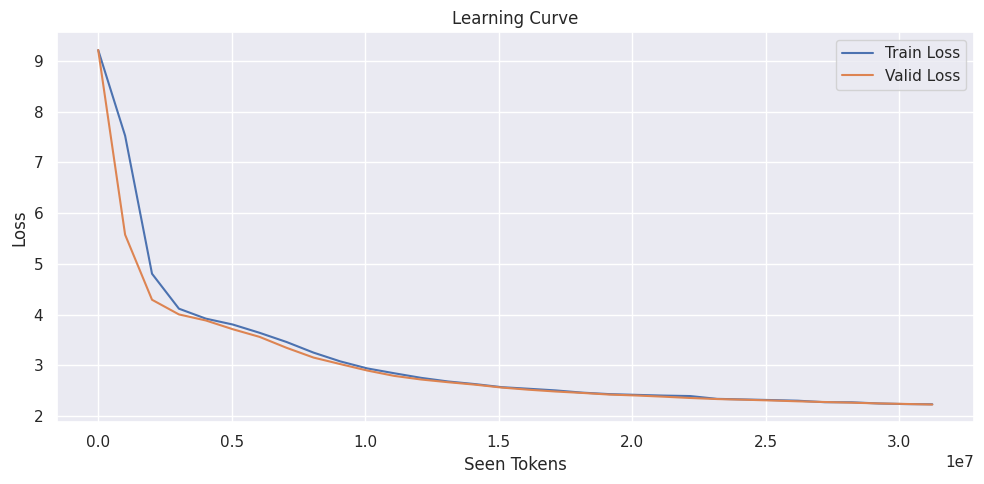

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old boy named Timmy. Timmy loved to play with his toys all day long. He would
pretend he was a superhero and would drive around the room. One day, Timmy and his toy car were
driving down the road.

Timmy's mom said, "Remember, this road is a war. It is strong and it can
help you do this war. You don't want to play with the truck."

Timmy nodded his head and said,
"That's the war driver is a brave fireman. Let's drive our car anytime."

When they went back home,
Timmy's mom told him, "Don't worry, we can go outside and play together again another war. They are
safe to see the war's big fire and the ambulance is safe. It's very important to be safe to protect
the war. We can keep this war safe and be safe." 

Timmy learned that they had to stay safe and
listen to the war. He promised to listen to his mom and they went inside. Timmy learned that it's
important to be careful in danger.

.............

Training:  50%|████▉     | 32243712/65000000 [20:30<08:52, 61489.36tokens/s, Loss=2.2274, LR=6.28e-03, B/S=1.08]


🔍 Validation Loss: 2.2137
✅ Model Saved!


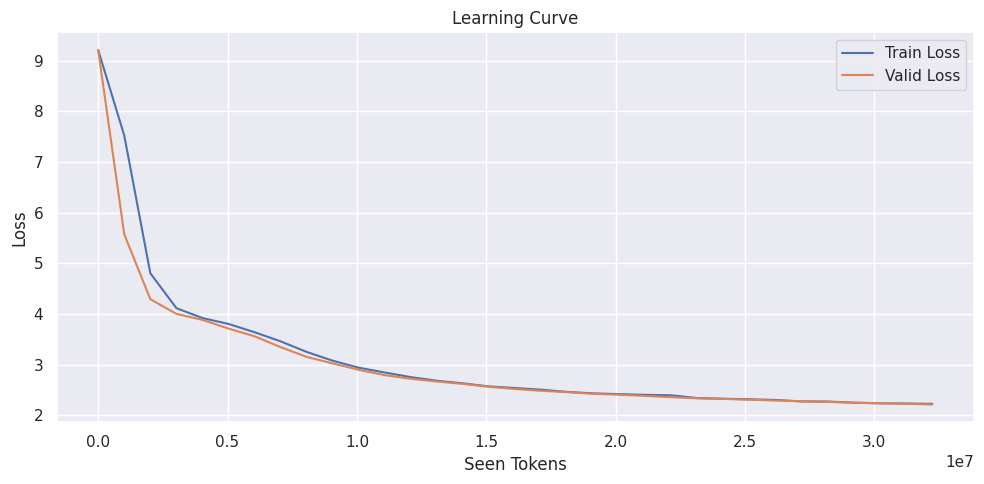

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old tree. He thought it was so big that he decided to go outside to explore. As
he walked, he saw something odd. It was a big, red bird who lived there. The bird wanted to get
closer to the bird, so he flew up to the bush. He was so excited that he forgot his answer. The bird
looked at the bird and said "It's my name, I'm your little bird. Do you want to be his friend?" The
bird nodded its head and said "Yes! Let's go and play together". So, the bird and the bird went back
outside together.

They explored the forest and explored together. They had a long time playing.
When it was time to go home, they all said goodbye to the bird and flew home. They had a special day
and had a lovely time together.

....................................................................................................

Sample 2:
In last, there was a boy named Sam. He was very hungry and did not find his food. He loo

Training:  51%|█████     | 33251328/65000000 [21:10<08:39, 61114.88tokens/s, Loss=2.1875, LR=6.04e-03, B/S=1.08]


🔍 Validation Loss: 2.1997
✅ Model Saved!


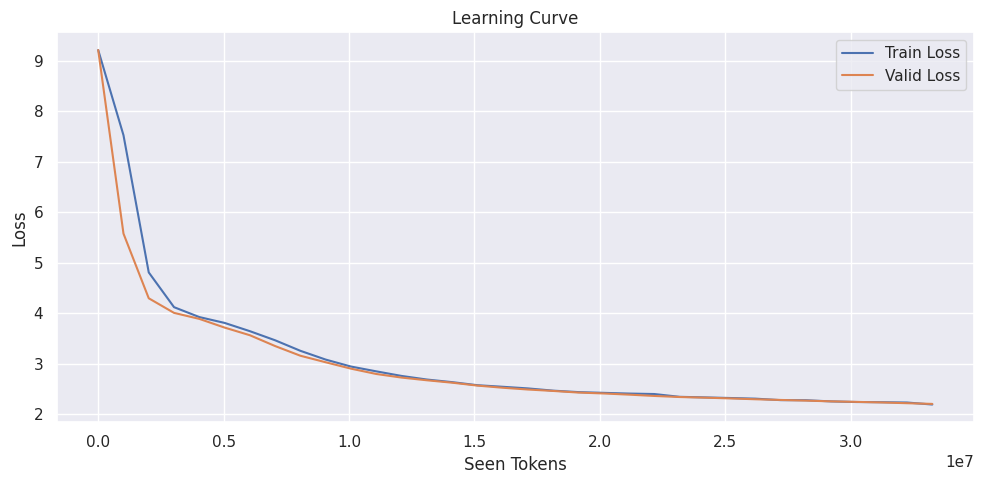

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, fat boy named Tim. Tim was very kind and loved to play, especially if he loved to
play. One day, Tim saw a big, scary dog and wanted to get help. He ran up to help Tim.

Tim took a
big, red ball of nuts to eat. He was so happy with his dog that he gave the dog a new bone. He ate
his bone with his new bone. Tim was glad that he could help and play with the dog, the dog could
have fun.

....................................................................................................

Sample 2:
In lastmorning, there was a little girl called Emily. She was so happy! 
Suddenly Emily heard a knock out
the door.  She opened the door and inside she saw a big teddy bear. Emily wanted to open the door,
but she was not sure. 
The puppy's name was Emily and Emily said: "Come back with me and help me
out." 
Emily was surprised. She quickly said: "Yes, I will open your bag! I will open it now".
Milly ran to

Training:  53%|█████▎    | 34258944/65000000 [21:50<08:20, 61403.64tokens/s, Loss=2.2029, LR=5.80e-03, B/S=1.08]


🔍 Validation Loss: 2.1925
✅ Model Saved!


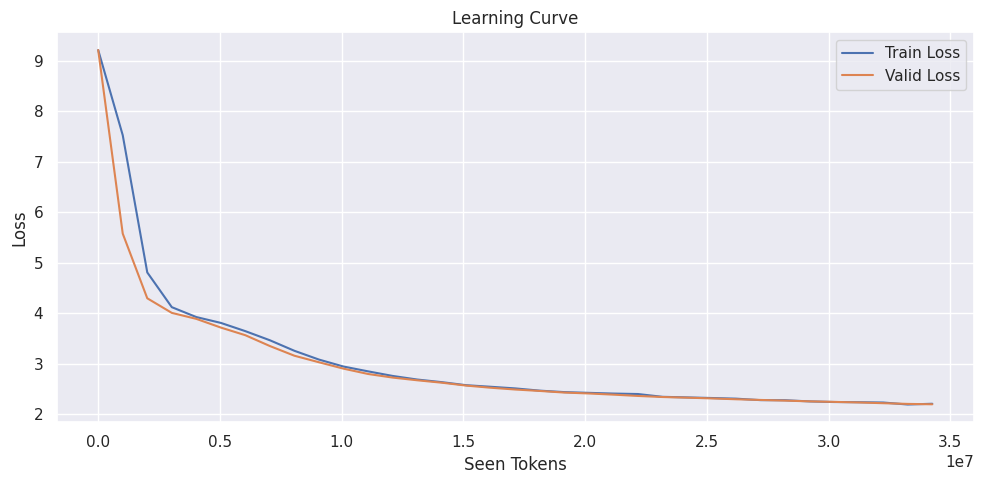

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old woman. She was very sad and lonely. But she did not understand. She wanted to
go home. She wanted her way home.

But as she went inside, a old man came into the park. He had a
big bag. He had a bag on it. He opened it and saw Anna. He had a bag and a bag. He said: "What do
you need?"

Anna said: "I want to eat this bag, too. It's a big bag. I want a candy. Maybe I can
give you a lollipop."

The old man looked at his bag. He looked at the bag. He saw a bag. He was
very nice. He smiled. He said: "I know what I have. Maybe you can give you something. But you have
to give it, and be careful. You have to ask me if you want. I know what to give you the bag. You
have to pay for your bag. You can pay and be very angry!"

Anna nodded. She said: "Okay, I will. I
will take you my bag. I will give you some of the bag. But you have to pay for it. I have a surprise
for you. I can give it back to my friend'

Training:  54%|█████▍    | 35020800/65000000 [22:08<08:10, 61154.90tokens/s, Loss=2.1853, LR=5.61e-03, B/S=1.07]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_092837_tok35020800.pth (seen_tokens=35,020,800)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_091900_tok20004864.pth


Training:  54%|█████▍    | 35266560/65000000 [22:30<08:06, 61165.86tokens/s, Loss=2.1847, LR=5.55e-03, B/S=1.08]


🔍 Validation Loss: 2.1754
✅ Model Saved!


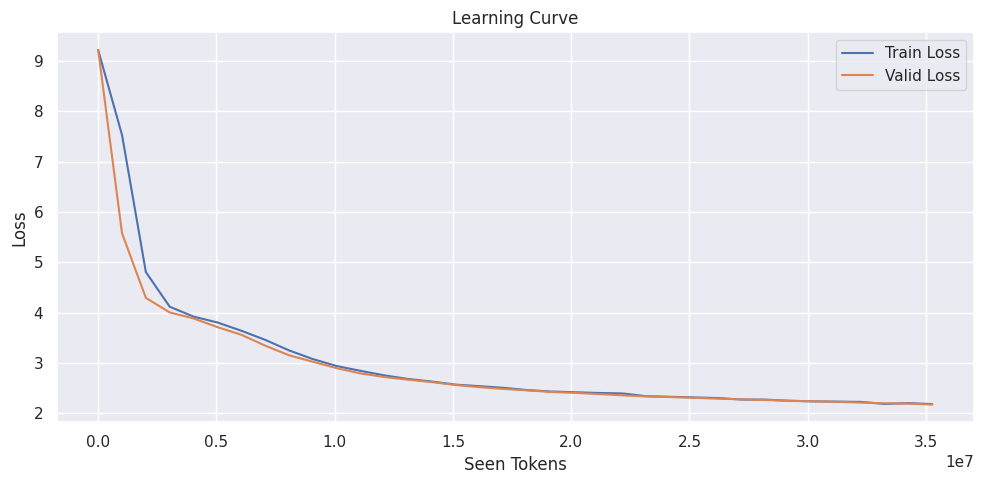

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old bear named Bob. He was walking around the beach with his friends and they saw
a boat. Bob wanted to try to do something cool. So, he grabbed his hat and his hat and started to
drive a boat.

Bob started to drive around the beach looking for the boat. He was so excited he
couldn't wait to show off his hat. He ran up high in the ocean.

Suddenly, he realized that his hat
was actually an octopus. Bob thought of a moment and decided to go back. He took off his helmet and
rode around the sand.

Suddenly, Bob's dad appeared and asked him to come out. Bob was so excited to
see the octopus and they both ran around the beach, looking at it.

But then, Jack noticed that the
octopus had made a big mistake. The octopus got stuck in the water and started to swim away.

Jack's
dad was very angry and said â€œJack, letâ€™s see. I'm not careful enough to take your time.â€

Jack
was very sad and he didn't want

Training:  56%|█████▌    | 36274176/65000000 [23:10<07:48, 61349.62tokens/s, Loss=2.1544, LR=5.31e-03, B/S=1.08]


🔍 Validation Loss: 2.1658
✅ Model Saved!


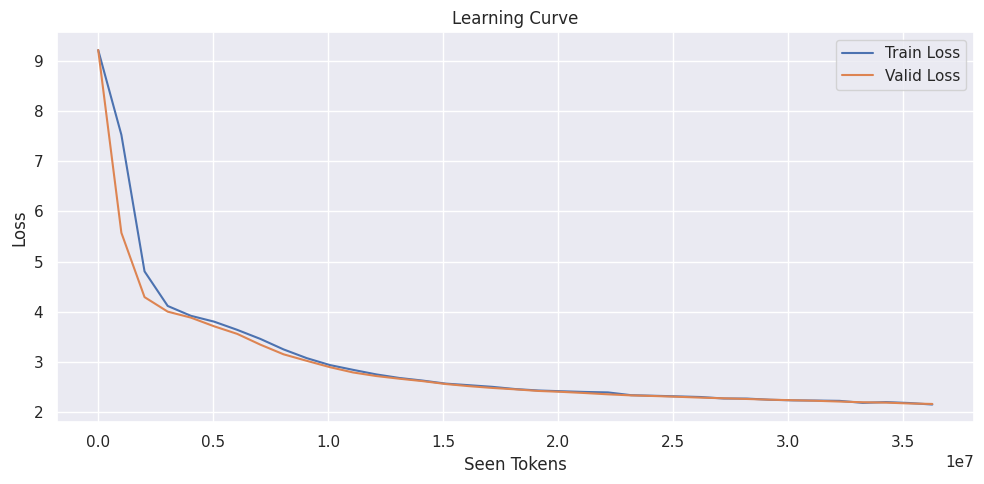

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old woman. She was very old and she was walking in the park and it was very dark.
Suddenly, she heard something calling her. It was a huge tree with lots of leaves.

She decided to
climb it and see what it was. She stepped on to reach for the branch. She felt a little better, and
she started to climb. She climbed, higher and higher until finally the branch was very high. Then,
the tree stopped with a smile and looked down to see that the tree was still in her hand.

It had a
beautiful view! She was so happy and thanked the tree with her kindness. She knew that when she was
feeling tired, she could go back and be happy.

....................................................................................................

Sample 2:
In last, there was a boy named Tom. He was very sad and scared. His dad saw the boy and told him not to
worry.

Tom's dad told him to stay and watch TV. Tom listened to 

Training:  57%|█████▋    | 37281792/65000000 [23:40<07:32, 61294.91tokens/s, Loss=2.1584, LR=5.06e-03, B/S=1.08]


🔍 Validation Loss: 2.1579
✅ Model Saved!


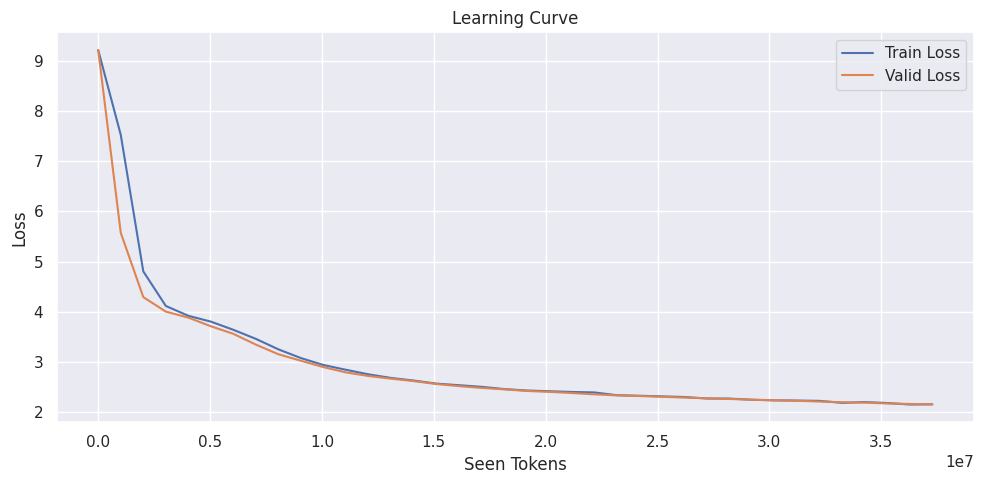

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old owl. He was very hungry. He wanted to eat food. The food was very hungry and
he asked the owl to help him. The owl said, "I'm hungry and hungry. I want to make you hungry."

The
owl said, "I am hungry too. I have some food for you. Can you help me pick some food for dinner?"
The owl smiled and said, "Yes, I can help you. I have enough food to eat." The owl was very happy
and said, "You can help me. Now let's cook your dinner."

The owl and the owl became good chefs and
cooked the food. They cooked dinner and had a delicious meal. They had a delicious dinner with yummy
food. From that day on, they lived happily ever after.

....................................................................................................

Sample 2:
In lastmorning, the little bird was singing. He was singing a song that he sang in the morning. He saw his
mom sing, and she had a song for her. She sang, laughed

Training:  59%|█████▉    | 38289408/65000000 [24:20<07:16, 61213.41tokens/s, Loss=2.1495, LR=4.82e-03, B/S=1.08]


🔍 Validation Loss: 2.1493
✅ Model Saved!


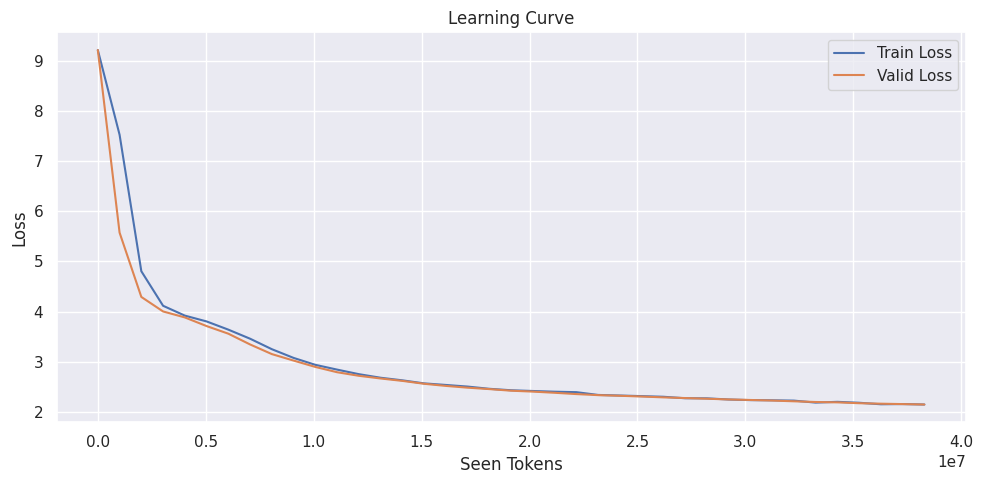

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old boy named Timmy. Timmy loved to play with his toys in the living room. He
always made sure he was the right decision and went to the store to buy the new toy to play with.
One day, Timmy saw a big toy car in the store. He went to ask his mom if he could buy it.

His mom
said, "No, you need this one toy car for you. It is very important to be honest and do things. Do
you know it?" Timmy didn't know what it meant, but his mom replied right. He said it was a toy car,
but Timmy was stubborn. 

Timmy asked his mom if he could buy his toy car. His mom was happy and
gave him the car. Timmy was happy and played with the toy car. He learned that it's important to
keep it safe in the store.

....................................................................................................

Sample 2:
In lastbig adventure, there lived a friendly girl called Emily. Emily was a very shy girl but liked to

Training:  60%|██████    | 39297024/65000000 [25:00<06:58, 61469.85tokens/s, Loss=2.1219, LR=4.58e-03, B/S=1.08]


🔍 Validation Loss: 2.1346
✅ Model Saved!


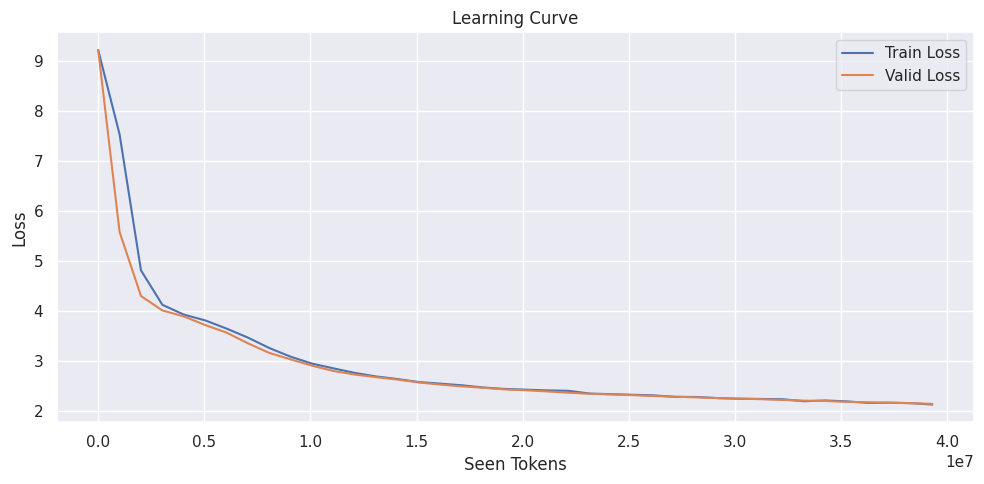

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, they were walking and the lake. They saw a beautiful lake. 

Suddenly, their little bears
started to quarrel. The bears were very selfish because they didn't want to share. He decided to
fight over who could join his friends. 

The bears started to fight over who they didn't have enough
money. They said the bears were being selfish and greedy. The bears argued over the same thing to
play and decided to play together. The bears had a lot of fun playing together.

After all ended,
the bears and their friends played together and forgot about the game. The bears had so much fun
that they forgot that it was time to go home. The bears said goodbye, and they never got the one.

....................................................................................................

Sample 2:
In lasttime, there was a little boy who wanted to go for a drive. He saw a big, red car with red wheels and
wheels. But he knew

Training:  62%|██████▏   | 40009728/65000000 [25:19<06:47, 61267.97tokens/s, Loss=2.1319, LR=4.41e-03, B/S=1.07]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_093148_tok40009728.pth (seen_tokens=40,009,728)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_092211_tok25018368.pth


Training:  62%|██████▏   | 40304640/65000000 [25:40<06:42, 61375.56tokens/s, Loss=2.1375, LR=4.34e-03, B/S=1.08]


🔍 Validation Loss: 2.1254
✅ Model Saved!


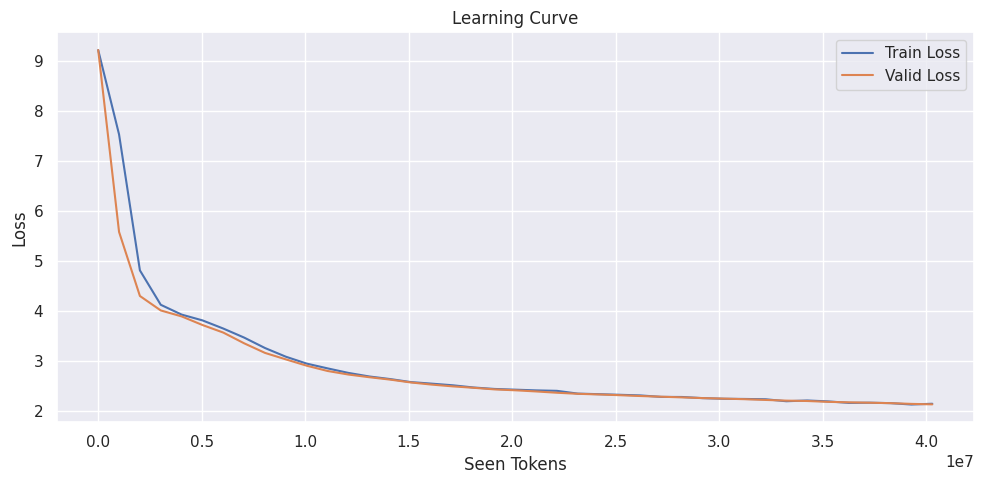

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, brown bunny named Mittens. Mittens was very hungry and wanted to eat it, but she
did not know what to do. Mittens decided to try and make a little sandwich with peanut butter.
Mittens ran outside to get some butter and brought it to her friend, Lily. They both said, "Let's
take turns eating the butter, please!" Mittens agreed and they sat in the grass. Mittens was happy
because she had the best butter and the soft butter.

....................................................................................................

Sample 2:
In lasttime, there was a little boy named Tom. Tom loved to eat apples all day. He would eat and drink them
all by himself. But one day, he had a problem.

Tom saw a big tree in the park. He wanted to eat
apples. But, he wanted to make a sad decision. He ran to his friend, Lily. They all went to Tom and
asked if they could help him find some apples.

Tom thought about

Training:  64%|██████▎   | 41312256/65000000 [26:20<06:25, 61399.26tokens/s, Loss=2.1116, LR=4.10e-03, B/S=1.08]


🔍 Validation Loss: 2.1208
✅ Model Saved!


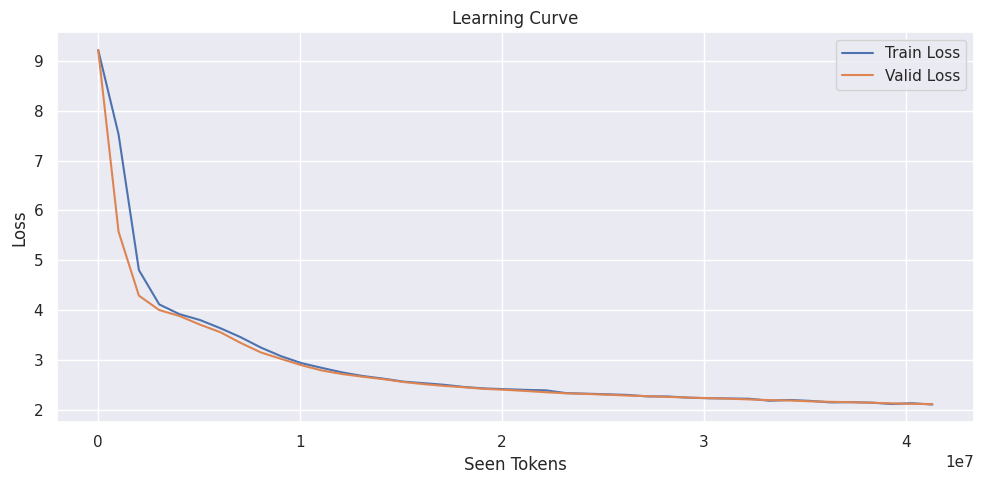

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old girl named Lily. She had a very charming day at school and all the friends.
They loved to draw and have a good time together.

One day, Lily decided to draw a big picture of
his friend who had a big brother. She drew a big wall that she drew on the wall. She drew a big star
on the wall and it was the most beautiful thing ever. Lily felt happy and proud of herself!

From
that day on, Lily made her own room all by herself. She loved playing with her toys and had fun. But
she knew that she could always make her mom happy, and she was happy to have found such a good
friend and she could see her favorite place.

....................................................................................................

Sample 2:
In last, there was a small girl. She loved to play and have lots of fun. Her mum was very good at it.

The
girl was very patient. Every day, she would go out and explore the worl

Training:  65%|██████▌   | 42319872/65000000 [27:00<06:10, 61195.96tokens/s, Loss=2.0956, LR=3.87e-03, B/S=1.08]


🔍 Validation Loss: 2.1051
✅ Model Saved!


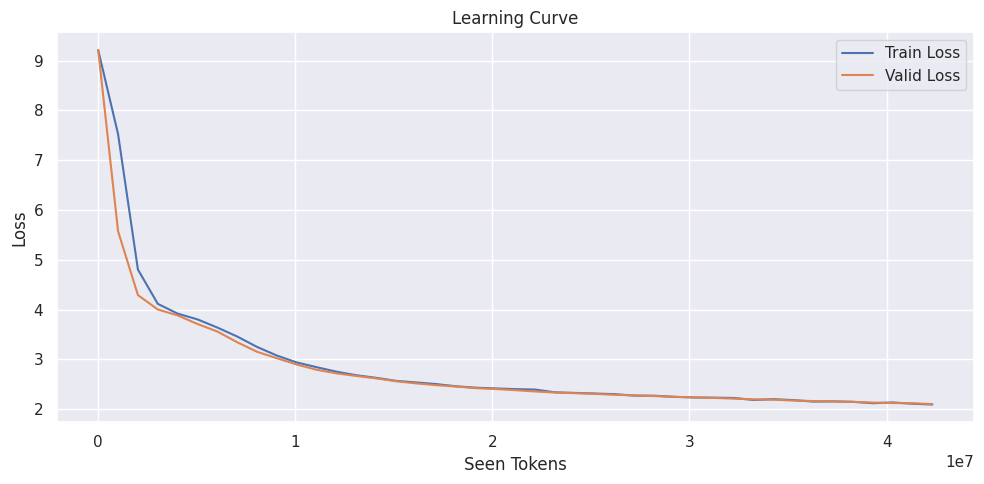

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old bear named Benny. Benny loved to play with his friends at the forest and have
fun. One day, Benny was walking along the path when he saw a big, old rock in the forest.
Suddenly, Benny's friend Billy came over and saw what was behind the rocks. "What are you doing?"
Benny asked. "I'm trying to make my tree open and the ground!"

Billy came up and asked, "What are
you doing, Lily?"

"I'm trying to build the hole, but it is hard and you might break the hole,"
Billy said.

Benny thought about this and said, "I can use this rock, but it won't be difficult. I
can use the rock to build it."

"Okay, Billy. Let's try," Lily said.

Billy was so happy and they
started to build the hole together. As they worked on the rock, they both worked together to make
the tunnel look even better. When they were finished, they went to their homes and had a good time.

................................................

Training:  67%|██████▋   | 43327488/65000000 [27:30<05:54, 61179.61tokens/s, Loss=2.0999, LR=3.64e-03, B/S=1.08]


🔍 Validation Loss: 2.0954
✅ Model Saved!


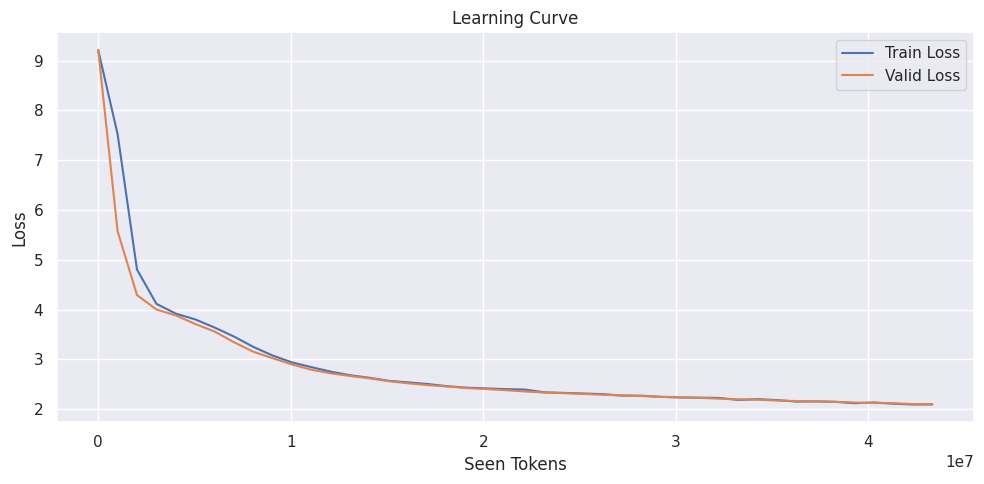

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, white ball. It was a little boy named Sam. Sam loved to play with his ball. One
day, Sam found a new ball. It was a new ball in the world. Sam was curious and he wanted to play
with it.

Sam ran to Ben and tried to pull the ball from Sam. But the ball was too hard and Sam did
not know what to do. He tried to pull the ball down. Sam was too fast and could not climb the tree.
Sam wanted to help Sam, but they were too small. They looked for each other and tried to pull the
ball away.

Sam saw Sam and wanted to help. He asked Sam for help. Sam did not listen. He pushed him
and pushed his ball down. Sam tried to pull and push. But Sam did not move. He felt too strong and
hurt. He cried and cried.

Sam felt scared and sorry. He did not know what to do. He did not want to
get hurt. He just wanted to play. He thought Sam was a new friend. He did not want to play with
Sam's ball. He did not want to play w

Training:  68%|██████▊   | 44335104/65000000 [28:10<05:37, 61160.02tokens/s, Loss=2.1015, LR=3.42e-03, B/S=1.07]


🔍 Validation Loss: 2.0844
✅ Model Saved!


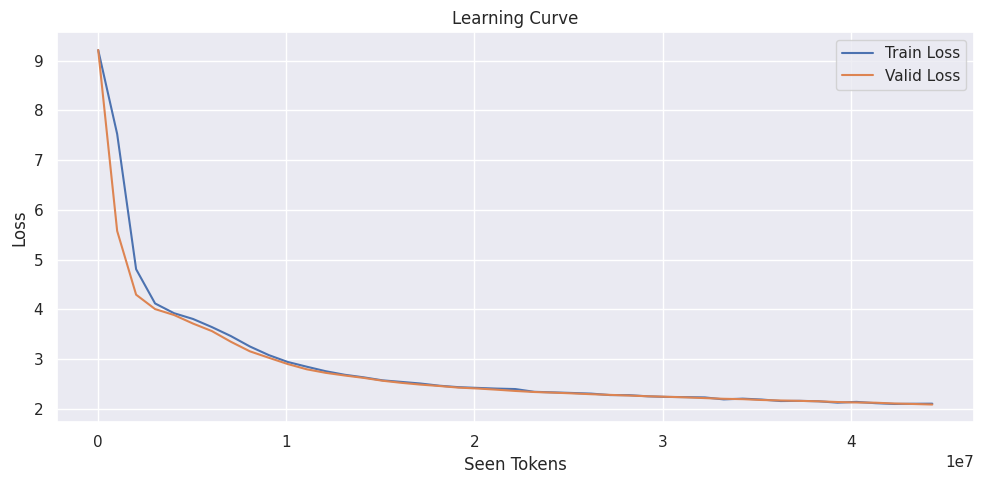

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, Bob was walking in the park. He saw a big, round object. It was green. He wanted to take it
home. So, he went to the park.

He was surprised and curious. He looked around to see a big, dark
sky. He saw a big box in the distance. He opened it and saw a huge, yellow bird. The bird had an
idea. The bird was so friendly and wanted to play with his ball.

Jack started to poke the ball and
the bird moved away. He watched until he was not looking, and he found a small hole in the ground.
The bird saw a little bird in the hole. The bird was very happy, and the bird flew down with the
ball.

Jack was very happy. He knew he would always be back to the little bird. He would take the
little bird home with his new friend.

....................................................................................................

Sample 2:
In lasttime, there was a little boy. The boy was very tired. He didn't want to go home 

Training:  69%|██████▉   | 45023232/65000000 [28:32<05:25, 61369.01tokens/s, Loss=2.0774, LR=3.27e-03, B/S=1.07]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_093501_tok45023232.pth (seen_tokens=45,023,232)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_092524_tok30007296.pth


Training:  70%|██████▉   | 45342720/65000000 [28:50<05:21, 61181.45tokens/s, Loss=2.0783, LR=3.20e-03, B/S=1.07]


🔍 Validation Loss: 2.0752
✅ Model Saved!


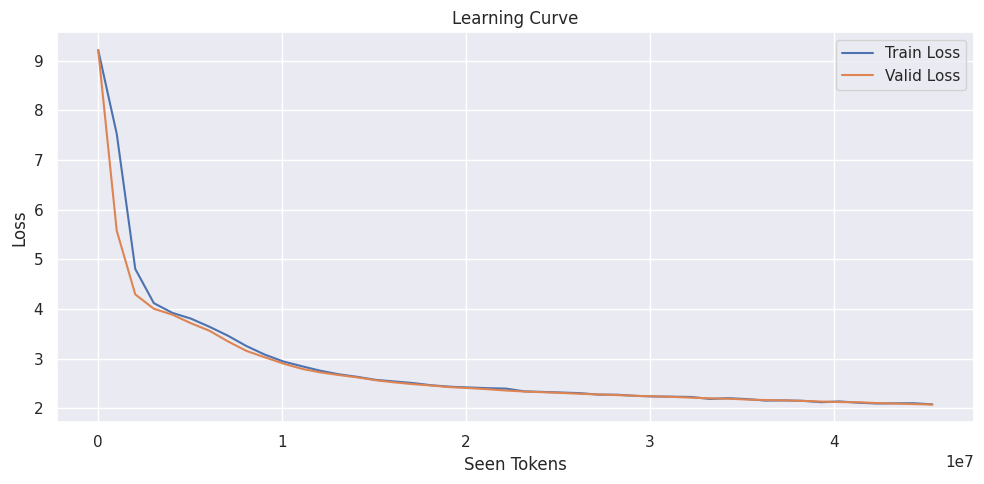

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, red bear. He was very big and he wanted to eat something new to eat. 

The bear
wanted to find a carrot, but he could not find it anywhere. The bear looked around the fridge with a
small, green carrot nose and it was very small enough to reach. 

The bear saw his big, red carrot
in the fridge. He picked it up and held it close, looking for it. He looked inside the fridge and
noticed he had forgotten it! He was very curious and wanted to see what was inside. 

Suddenly,
something amazing happened. The bear found a carrot in the fridge. He was so excited he couldn't
wait to eat it! He put it on his plate and ran to find his mom. 

When the bear opened its mouth, he
was surprised to see it was. It was big and brown and furry. He smiled and hugged it tightly to his
mom. He knew he would never forget this day!

...........................................................................................

Training:  71%|███████▏  | 46350336/65000000 [29:30<05:06, 60758.78tokens/s, Loss=2.0756, LR=2.99e-03, B/S=1.07]


🔍 Validation Loss: 2.0683
✅ Model Saved!


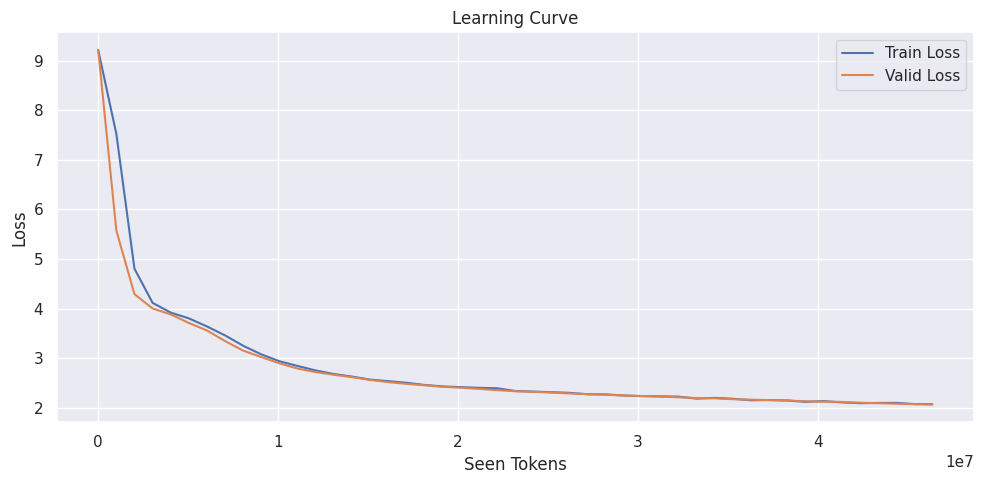

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, they were out for a little girl. She was playing in the living room with her family and
forgot to go inside. She was sad, but her mom said she was sorry.

One morning, the little girl came
over to her mom. She said, "Mom, I can't find my mommy. I want to stay here."

Her mom said, "No, my
loves, sweetie. It's not nice to stay away from you. We should leave the living room."

The little
girl was very angry, but she said, "It's my mommy, I'm sorry. I didn't mean to hurt you."

Her mom
said, "It's okay, we'll just watch you. We can be safe. But just don't be scared."

So, they went to
the living room and snuggled up for the little girl. She was still upset, but she felt a little less
scared.

....................................................................................................

Sample 2:
In last, there was a boy named Ben. Ben was very sad because his brother couldn't play anymore. He did not
u

Training:  73%|███████▎  | 47357952/65000000 [30:10<04:50, 60827.88tokens/s, Loss=2.0524, LR=2.79e-03, B/S=1.07]


🔍 Validation Loss: 2.0577
✅ Model Saved!


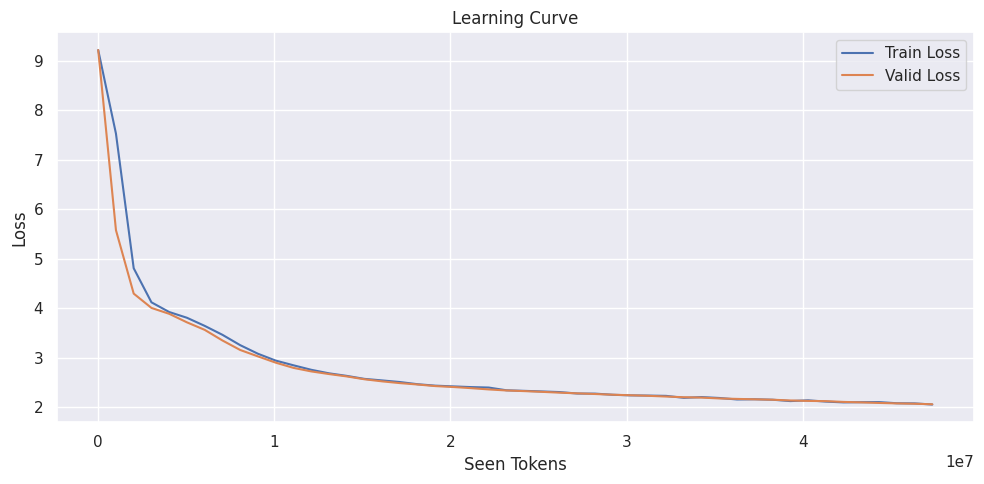

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a boy named Ben. He was very hungry and wanted to help. One day, his mom said to him,
"Let's have a picnic lunch. We can provide a picnic. You have to pack your lunch first lunch first."
Ben was very excited. He packed their food in the bag and went to the pond. He spread out a picnic
basket and set the sandwiches on the pond. When Ben got to the picnic, he brought some sandwiches
and sandwich. He said, "Thank you for coming, mom!"

His mom smiled and said, "Thank you, Ben. You
are very sweet too. But don't forget to pack your lunch first."

Ben nodded and smiled. He had a
great time, but also felt happy. He knew that he would take a deep breath and enjoy the picnic. He
thanked his mom and went back to his house. He hoped he would always pack his bag for his lunch.

....................................................................................................

Sample 2:
In lasttime, there was a li

Training:  74%|███████▍  | 48365568/65000000 [30:50<04:31, 61326.34tokens/s, Loss=2.0497, LR=2.60e-03, B/S=1.07]


🔍 Validation Loss: 2.0490
✅ Model Saved!


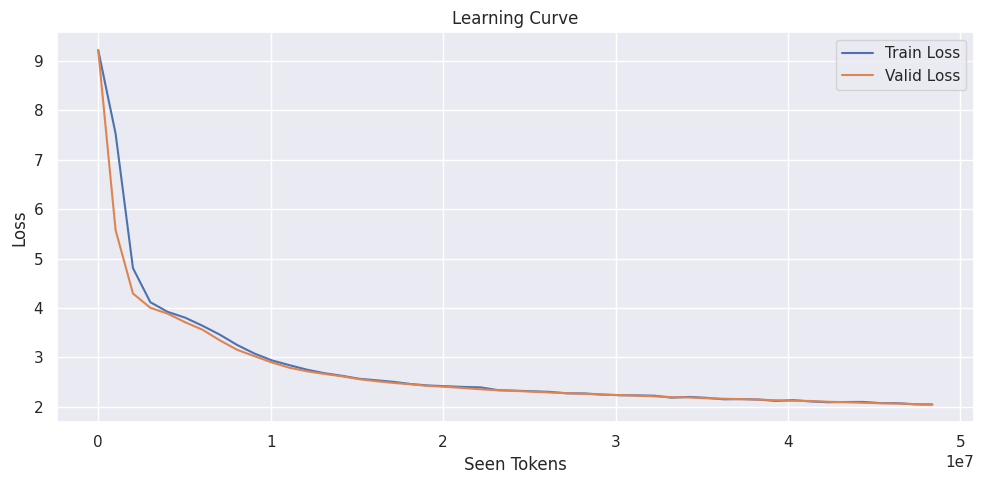

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old lady. She was very brave. She would look at all the trees in her garden, and
the flowers. One day, a little girl came to the park. The lady said, "Hello little girl. What do you
want to play?"

The little girl was scared. She said, "I want to play with you. I want to play!" The
elderly lady was kind and gave her a stick. The small girl said, "Please come and play with my
stick."

The elderly lady was surprised. She said, "That's okay. You can play with your stick." They
played in the park, and had fun. The elderly lady was very happy. She said, "Thank you, Lily and
this time is fun. I am glad you have a friend."

....................................................................................................

Sample 2:
In lastmorning, the little bird was out of sight. It was so pretty and sparkly. 

The bird started to cry.
She looked at all the other branches, and then said, "I wish I co

Training:  76%|███████▌  | 49373184/65000000 [31:30<04:14, 61436.32tokens/s, Loss=2.0441, LR=2.41e-03, B/S=1.07]


🔍 Validation Loss: 2.0405
✅ Model Saved!


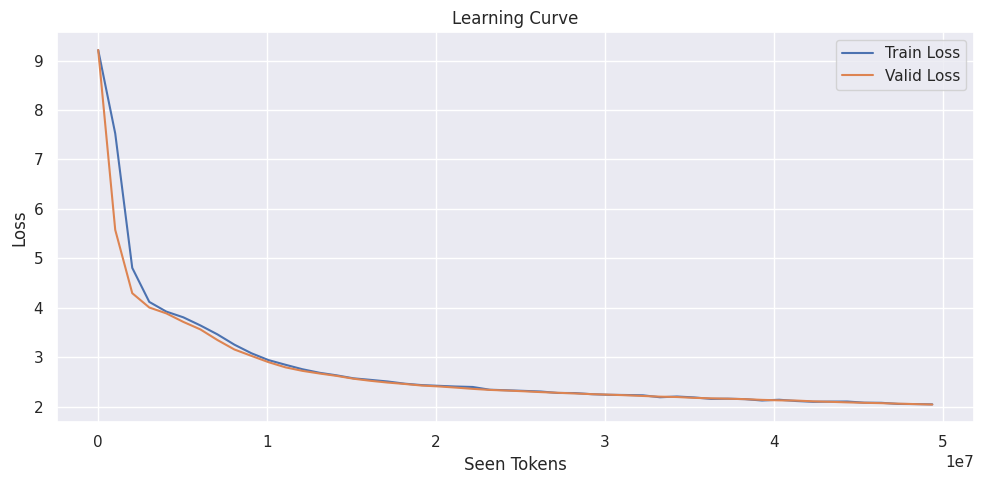

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a girl named Sally. She was very happy. She had her best friend, Lily and her friend
Tim. They were good friends and were friends.

One day, Sally went to Tim's house to get some hot
cocoa. She saw a big pot of cocoa on the wall. It was big and white. It looked like it was not good
to eat. Sally thought it would look nice and sweet like it was happy.

Tim took Sally's help and
they walked to the pot. They ate the cocoa and it tasted good. Sally and Tim enjoyed the cold cocoa.
They were happy and warm. From that day on, Sally and Tim would always play with their toys.

....................................................................................................

Sample 2:
In lastmorning, the little bunny was a little boy named Timmy. He was very brave and could do anything he
loved to wear. Timmy was always looking for new clothes and always wanted to make it look pretty.
One day, Timmy went to th

Training:  77%|███████▋  | 50012160/65000000 [31:44<04:05, 61123.41tokens/s, Loss=2.0432, LR=2.30e-03, B/S=1.07]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_093813_tok50012160.pth (seen_tokens=50,012,160)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_092837_tok35020800.pth


Training:  78%|███████▊  | 50380800/65000000 [32:00<03:57, 61462.08tokens/s, Loss=2.0370, LR=2.23e-03, B/S=1.07]


🔍 Validation Loss: 2.0322
✅ Model Saved!


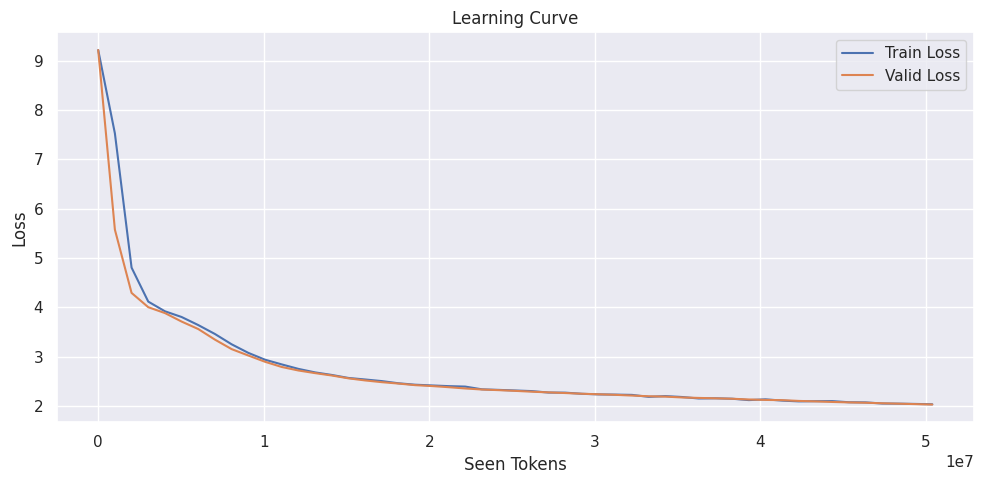

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a girl named Mia. Mia was very happy because she had an adventure for her first friend,
a boy named Tim. They decided to go for a walk in the park.

Mia was excited to see all the pretty
flowers and the birds. She asked Tim, "Can I play in the park?" Tim said, "Yes, I'd like to play
with the big ones I like that you want!"

Mia and Tim had a great time playing outside. They saw a
big hill and a tree. Mia said, "Let's go to the top of the hill and see what's on the top. Let's go
see if we can find out."

They started to climb the hill, and soon they reached the top of the hill.
Mia said, "Look at the big hill!" They both laughed and had so much fun climbing. They were so happy
to see each other again. When they got there, they both felt very proud of their plan.

....................................................................................................

Sample 2:
In lastmorning, the little girl

Training:  79%|███████▉  | 51388416/65000000 [32:40<03:41, 61313.58tokens/s, Loss=2.0271, LR=2.06e-03, B/S=1.07]


🔍 Validation Loss: 2.0253
✅ Model Saved!


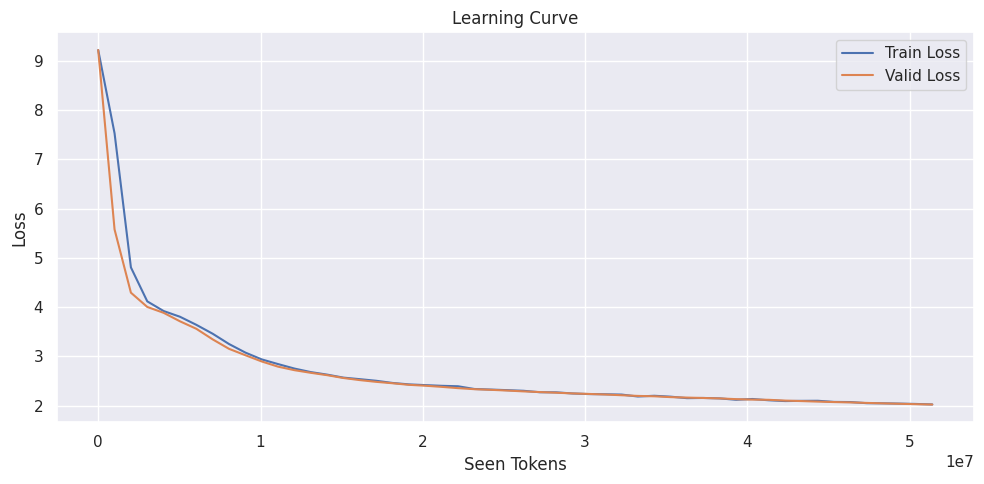

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, they were going to get a big sack. They opened the sack and found a big ball in the park.
Lily was very happy and wanted to play with the ball. She put the ball in a basket and ran outside.
It was her favorite ball. She played with it all day while the sun went down.

But then, something
bad happened. The ball bounced too high. The ball went over a rock and landed on the ground. Lily
and her ball became sad and lonely. She wished she could find another ball. But then, she saw a
little bug on the ground. She ran to the rock and said, "Hi, bug! What are you doing?"

The bug
said, "I am looking for a good ball, Lily. Can I play with you?" Lily said, "Sure! Let's play
together!" They both looked at the ball together and smiled. They played with the ball for a while,
and they had a great time. The end.

....................................................................................................

Sample 

Training:  81%|████████  | 52396032/65000000 [33:20<03:24, 61553.83tokens/s, Loss=2.0215, LR=1.91e-03, B/S=1.07]


🔍 Validation Loss: 2.0193
✅ Model Saved!


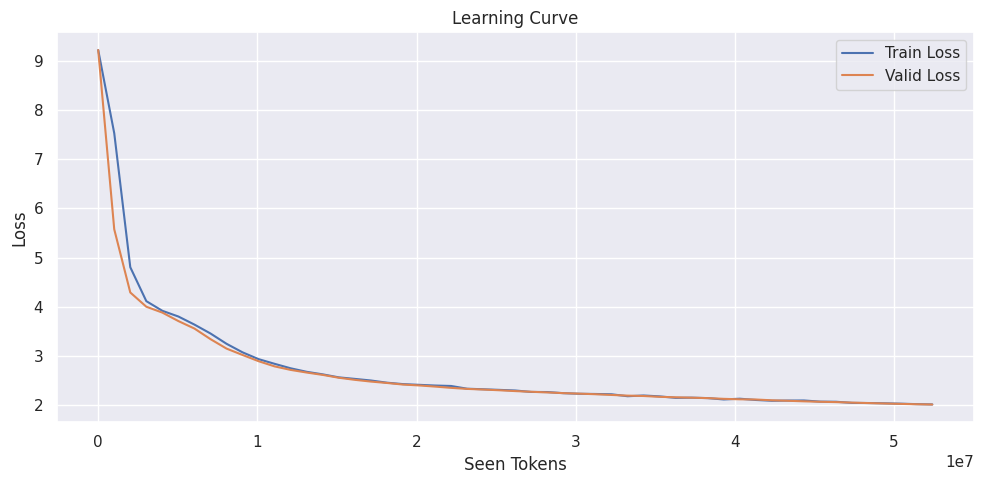

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, her mommy was getting very hungry. She was very hungry and wanted to eat dinner.

â€œCome
in,â€ she said. She looked around and saw a jar of vegetables. â€œCan I help you stir the
vegetables?â€ she asked.

â€œYes,â€ said her mommy. â€œWe can stir the vegetables.â€

They stirred
until the soup was ready. She stirred the veggies and then she put one half in one jar. She stirred
it, and it tasted delicious.

â€œYay! This is the best day ever!â€ said her mommy. 

The little girl
smiled. She was so full of energy and she couldn't wait to eat again! She enjoyed the fresh
vegetables and it was so sweet. 

The little girl was so happy, and she hugged her mommy and her
mommy.

....................................................................................................

Sample 2:
In last, there was a girl named Sue. She was very happy. She had an adorable dress. Sue loved to dress up
all the way she went. On

Training:  82%|████████▏ | 53403648/65000000 [34:00<03:09, 61230.57tokens/s, Loss=2.0129, LR=1.76e-03, B/S=1.07]


🔍 Validation Loss: 2.0092
✅ Model Saved!


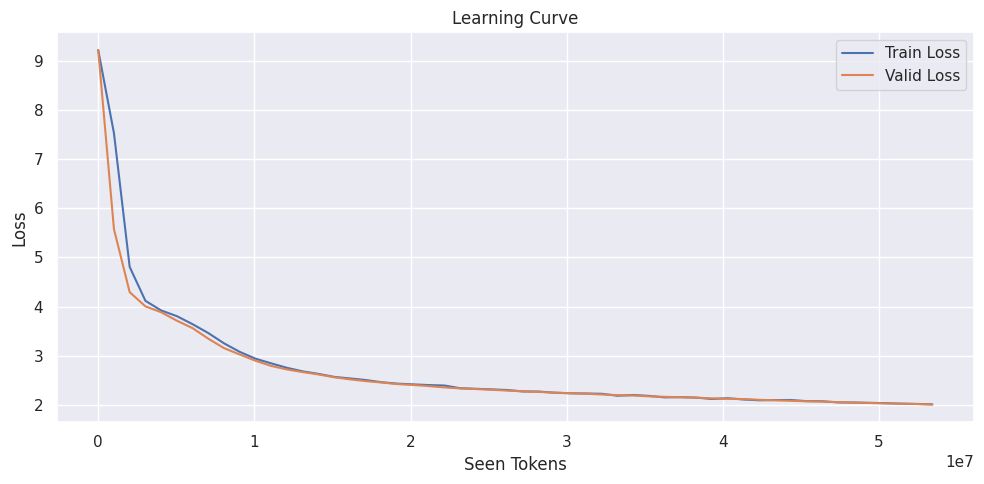

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, there was an old house. It was a big house with a little girl, a cat. The old cat wanted to
go outside and explore. 

The old man had an idea. He said, "Let's go in and see what we can find!"
The little girl was delighted and ran to the house. 

Inside the house, the old man found a big pile
of junk. He said, "This is the junk can stay there for a long time! We must get out." The old man
said, "Let's go to the park. Let's find a way to get the junk back!" 

The little girl was so
excited that she ran to the park to find the junk. When she got there, she found a pile of junk. She
found a big, clean and clean pile. She was so happy when the old man saw her. He said, "Thank you so
much of my stuff, my little girl. I love playing with you." 

The old man thanked the little girl
and hugged her. They went inside the house, and the little girl was happy to have found out the
junk.

...............................

Training:  84%|████████▎ | 54411264/65000000 [34:40<02:52, 61370.63tokens/s, Loss=2.0029, LR=1.62e-03, B/S=1.07]


🔍 Validation Loss: 2.0044
✅ Model Saved!


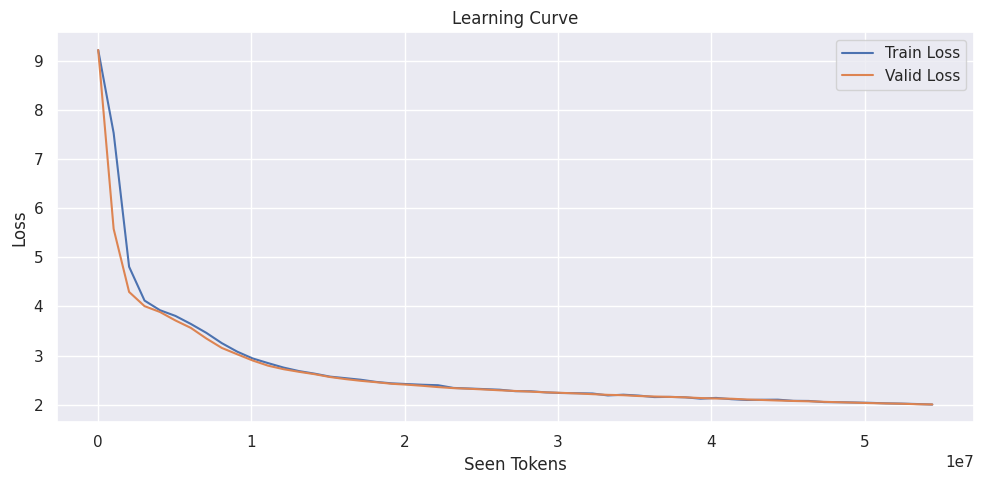

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a boy named Joe. Joe was very lonely. Joe had lost his best friend forever and no one
knew how to get. One day, Joe wanted to take his new friend. Joe looked everywhere but he couldn't
find out.

Joe asked his friend, "What's important to do?" Joe said, "I am searching for something
to hide." Joe was so disappointed that he couldn't find a place to hide. Joe kept thinking. He asked
Joe, "Why can't I keep you close to the forest? Please come with me." Joe thought this was the right
choice and then he asked Joe, "I am very sorry for finding my friend". Joe smiled and said, "It's
okay Joe. I'm glad you had to be honest".

Joe smiled and said, "It's ok Joe. I'm not very lonely
anymore. I'm sure I can keep you safe." Joe agreed and he ran off to find his way home. Joe was
happy and had a friend.

....................................................................................................

Sample 2:
I

Training:  85%|████████▍ | 55001088/65000000 [34:54<02:45, 60547.26tokens/s, Loss=1.9831, LR=1.55e-03, B/S=1.07]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_094123_tok55001088.pth (seen_tokens=55,001,088)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_093148_tok40009728.pth


Training:  85%|████████▌ | 55418880/65000000 [35:20<02:36, 61041.83tokens/s, Loss=1.9846, LR=1.49e-03, B/S=1.07]


🔍 Validation Loss: 1.9970
✅ Model Saved!


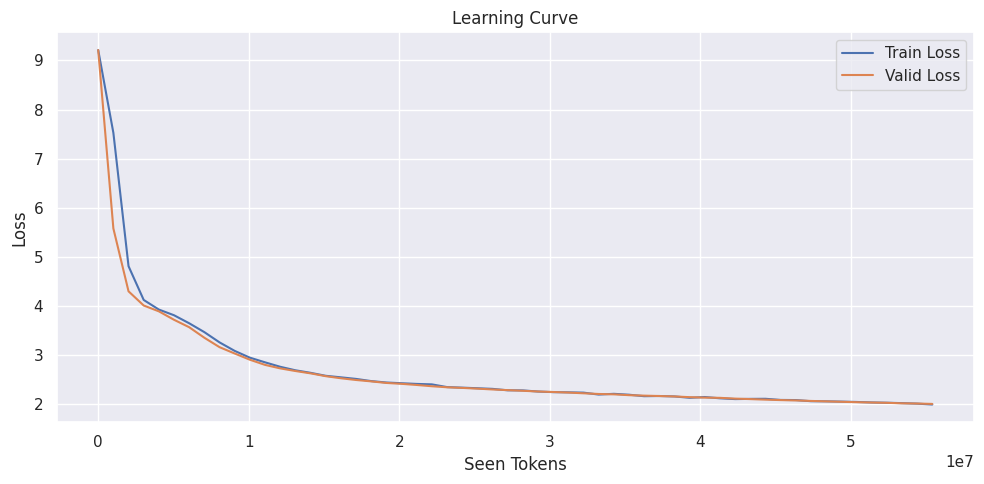

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, strong rabbit. He was hopping around in the sunshine. He was a bit afraid to run
and jump, but the big rabbit wanted to join him. So he hopped down to him and started to follow him
down the path.

When he got to the end, the rabbit was safe. He hopped onto the other animals and
said hello. The rabbit felt brave and wanted to stay and be free. He hopped and hopped around the
trees, and around and around, until the rabbit was safe.

He was very happy and he was able to help
himself. The rabbit hopped and hopped and hopped and hopped and skipped all day. He was so proud of
himself for trying to be safe and sound so he could do a new adventure.

....................................................................................................

Sample 2:
In lasttime, there was a little boy called Tom. Tom was very tired and very lonely. One day, Tom had
something he could find and needed to find som

Training:  87%|████████▋ | 56426496/65000000 [35:50<02:19, 61365.16tokens/s, Loss=1.9889, LR=1.38e-03, B/S=1.07]


🔍 Validation Loss: 1.9924
✅ Model Saved!


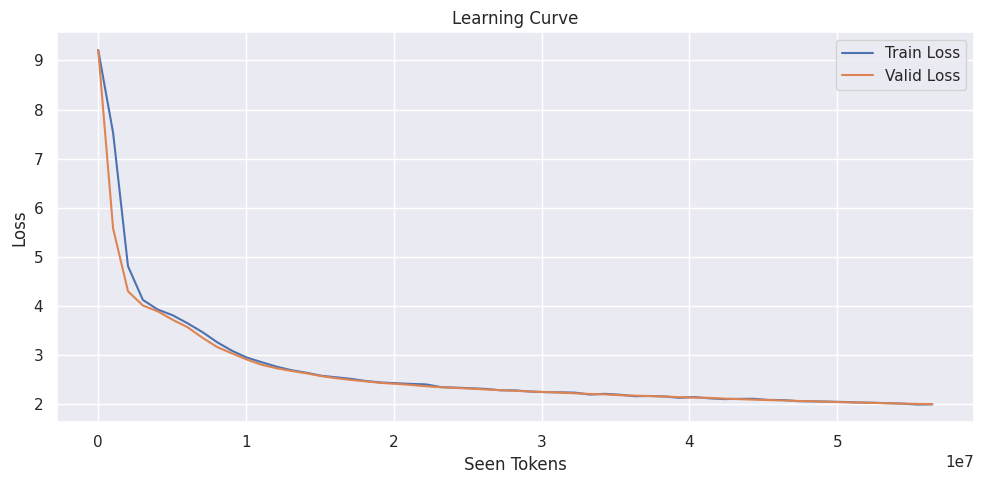

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, white puppy. He was very big and furry. He wanted to make the puppy happy. 

One
day, he took out a ball and started to run. The puppy stopped and looked at his bone. He wanted to
play with it, but he was too short. So he grabbed the ball and ran outside. 

The puppy had so much
fun running, and it didn't hurt his friend. The puppy was scared. But then he stopped running. He
saw the bone and smiled. He thought the puppy might be a good dog! He ran after it and ran back to
his bone. 

But the puppy was too fast. He started to cry. Suddenly, the bone broke. He was very
sad. The end.

....................................................................................................

Sample 2:
In lastmorning, the sun would shine through the air. It was so much fun, it almost felt so happy as it felt
outside.

But then, as it started to rain, the wind blew and rain started to fall. The rain got
loud

Training:  88%|████████▊ | 57434112/65000000 [36:30<02:04, 60704.06tokens/s, Loss=1.9866, LR=1.28e-03, B/S=1.07]


🔍 Validation Loss: 1.9878
✅ Model Saved!


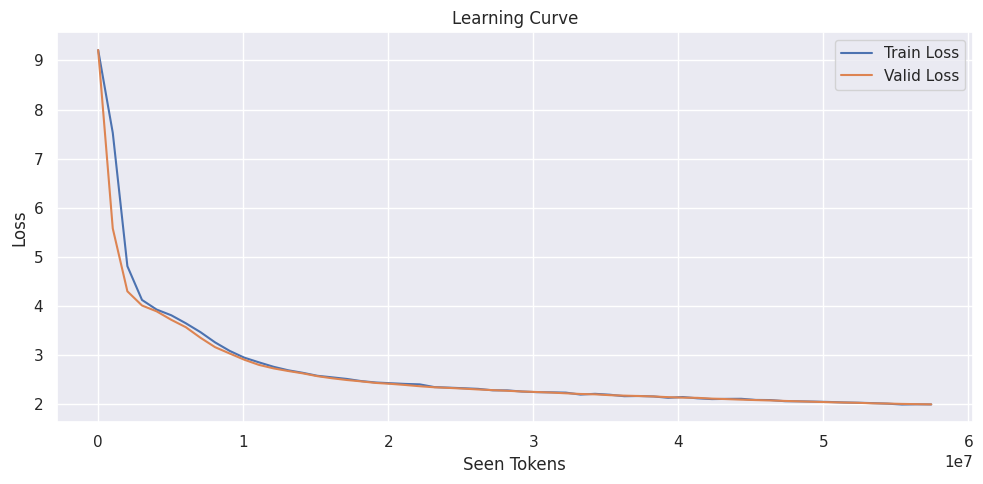

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, fat mouse. He was very small and fat. He wanted to take it. He took it from the
store and went to the store.

When he got home, his mom gave him a plate, a bowl of water. It was a
big, red ball and shiny. "This is the best golfer than mine!" he said.

He was happy that the tuna
could take it. He took it with him. He played with it all day.

But as he was playing with it, he
slipped and fell off the floor. He hurt his knee and hurt. His mom took him to the hospital. The
next day, the tuna was too big and sick.

The tuna was still broken, and the cheese was still not
broken. His mom took him to the hospital. The tuna was not broken, but it was too late.

The next
day, the tuna found a new toy in the kitchen. He was very happy and thanked the mom for taking him
to buy it.

....................................................................................................

Sample 2:
In lastmorning, 

Training:  90%|████████▉ | 58441728/65000000 [37:10<01:46, 61391.73tokens/s, Loss=1.9862, LR=1.19e-03, B/S=1.07]


🔍 Validation Loss: 1.9840
✅ Model Saved!


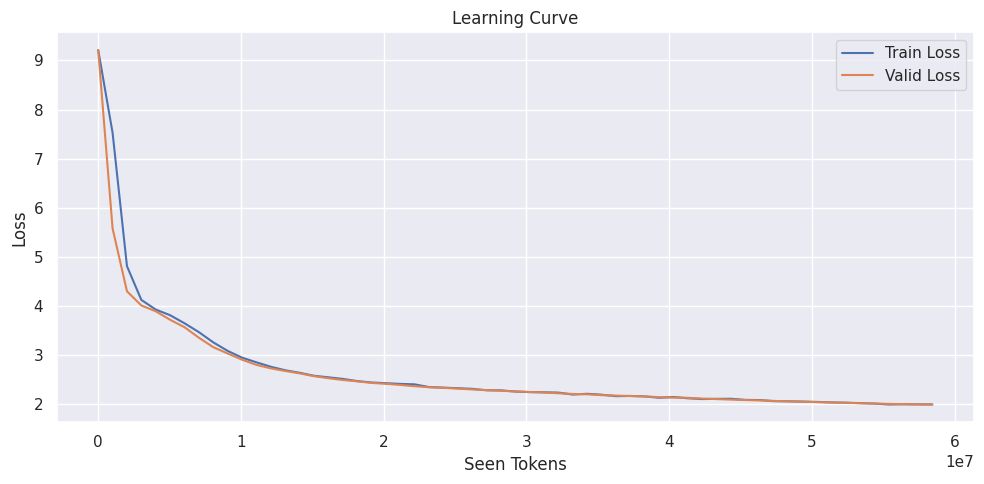

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, red dog. He was a happy dog. It was brown and white, like a yellow tail. It was
brown, warm and had a long tail. It was white and had a long tail.

One day, the dog and the dog
went to the market. He saw a big, red bike on the ground. He wanted to ride it, but it was too far.
"Can you ride the bike, dog?" the dog asked the dog. The dog looked at the bike and said, "No, I can
go too. The bike is too high for me."

The dog did not listen. He thought the bike was too high and
too high. He wanted to ride the bike.

"Come on, dog!" the dog said. He ran after the bike and
climbed up the road. He did not see the dog that was on the other side of the street.

The dog saw
the dog and ran to catch it. He barked and jumped. The dog jumped over the dog and barked. The dog
chased the dog and ran after him.

The dog was free. He wagged his tail and licked his face.

"Thank
you, dog!" the dog said. "You are a n

Training:  91%|█████████▏| 59449344/65000000 [37:50<01:30, 61454.45tokens/s, Loss=1.9701, LR=1.11e-03, B/S=1.07]


🔍 Validation Loss: 1.9781
✅ Model Saved!


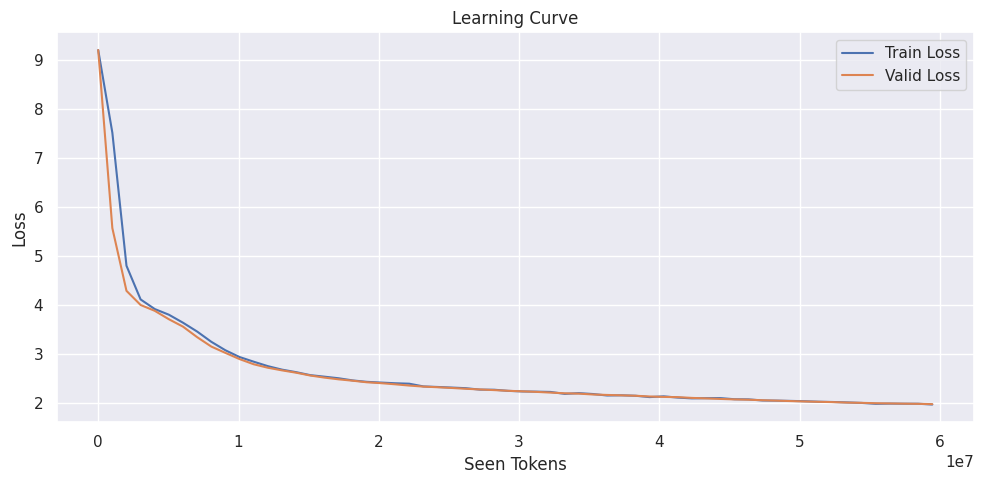

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old tree. It was a big, red tree, and very happy. Every day, he would go on an
adventure and get a snack.

One day, a little boy came to the park. He saw the tree and wanted to
climb it. He asked his mom to help him. His mom said yes and they went to the ladder.

At first, the
old man took out a big red apple. His mom said it was for a lot of fun, so he said the apple was the
perfect snack. The little boy thanked his mom and went home.

The old man took the apple and it was
very tasty. He was so happy to share it with his family and they all had a great day together.

....................................................................................................

Sample 2:
In lastmorning, the little bird was in a hurry. She wanted to be the first. She asked her mom "What does my
first do?". Her mom said "No, I want to make a cake. I want to help you."

The little bird was very
sad. She was s

Training:  92%|█████████▏| 60014592/65000000 [38:05<01:22, 60788.46tokens/s, Loss=1.9700, LR=1.07e-03, B/S=1.07]

✅ Saved checkpoint: checkpoints/checkpoint_20250612_094434_tok60014592.pth (seen_tokens=60,014,592)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_093501_tok45023232.pth


Training:  93%|█████████▎| 60456960/65000000 [38:30<01:14, 61260.41tokens/s, Loss=1.9689, LR=1.04e-03, B/S=1.07]


🔍 Validation Loss: 1.9730
✅ Model Saved!


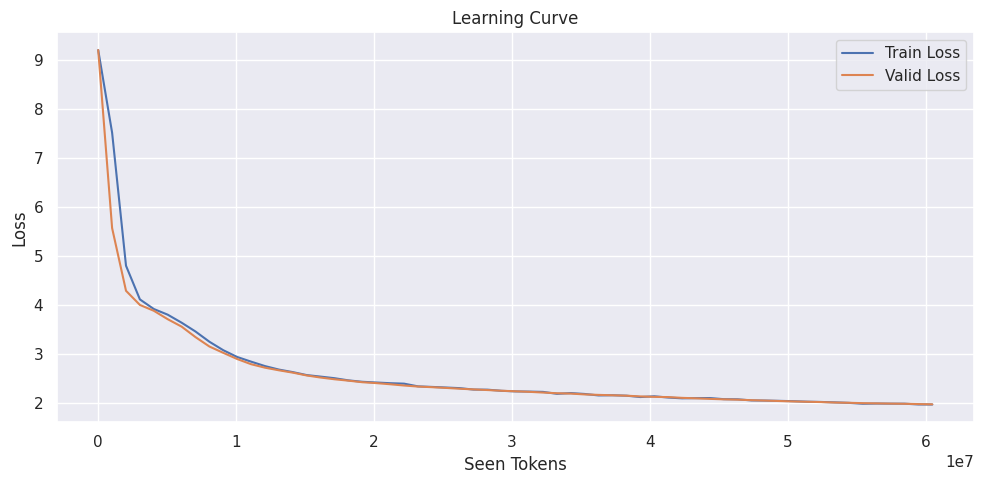

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a girl named Anna. She was very excited to go to the park with her mum to pick some
pretty flowers.

Anna and her mum went to the park. Anna saw an incredible flower, so she wanted to
see it. She asked her mum if she could pick it so she could pick it.

Her mum said yes, so Anna
started picking the flower. It was so beautiful and beautiful that she couldn't wait to try it out.
After a few tries, she was almost as excited as she could! She put the flower down in her basket and
started to pick it up.

But suddenly she slipped and fell down. She screamed and her mum called out
to her. Anna felt so embarrassed and scared. She had been trying to pick the flower but was too
scared to pick it up.

Mum quickly grabbed the flower and gave Anna a big hug. She said "We need to
keep the flower safe, but I'll keep it safe in the park for you. You are very kind." Anna was very
happy to have been able to pick the flow

Training:  95%|█████████▍| 61464576/65000000 [39:10<00:57, 61167.04tokens/s, Loss=1.9752, LR=9.90e-04, B/S=1.07]


🔍 Validation Loss: 1.9702
✅ Model Saved!


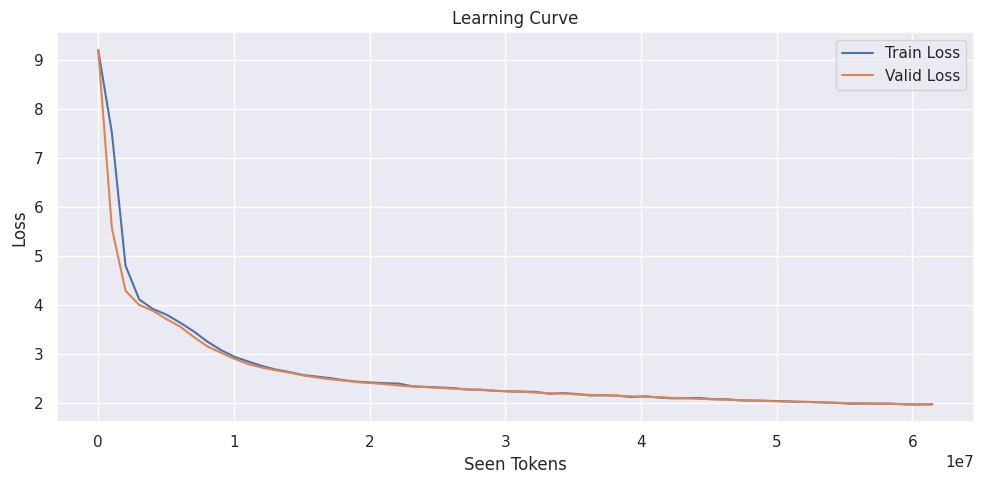

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In last, there was a big, strong house. Every day, a little girl came to visit the barn to take care of it.
One day, the little girl was in the barn and decided to give it some food to her house. When she
opened the door, she saw a big, red apple! 

The little girl was so excited! She took the apple
outside and started to eat. Suddenly, a little girl named Sarah came over and saw that the apple was
gone. The girl was sad, and she tried to get the apple back. 

Sarah ran away as fast as she could.
She was so happy to find the apple, she decided to give it a try. She took a big bite and it tasted
even better. 

The girl was so happy that she hugged Sarah. She said goodbye to the big, juicy apple
and continued on her way home.

....................................................................................................

Sample 2:
In lastone of her friends the park, a girl named Lily. She was very organized and wanted

Training:  96%|█████████▌| 62472192/65000000 [39:40<00:41, 61477.55tokens/s, Loss=1.9609, LR=9.51e-04, B/S=1.07]


🔍 Validation Loss: 1.9664
✅ Model Saved!


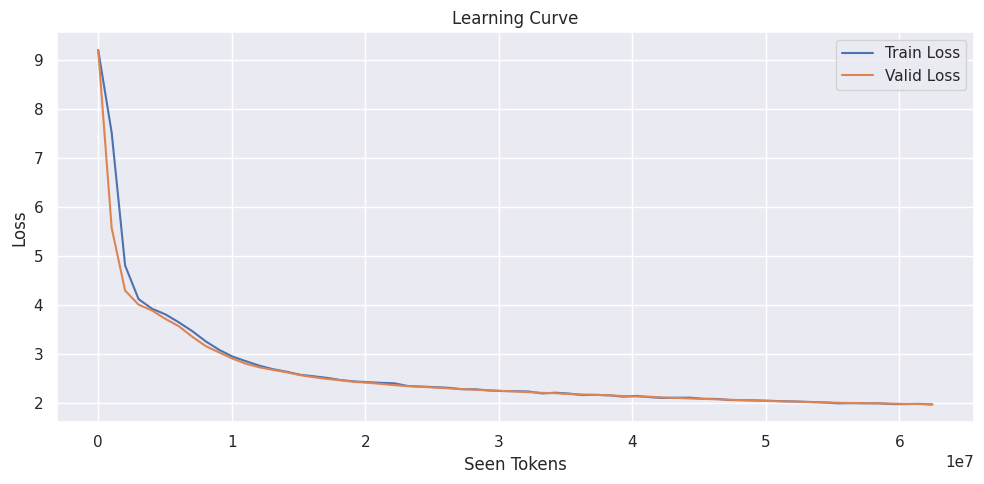

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lasttime, there was an old tree. It was a big, red tree that was covered in soft branches. The leaves
were very happy and excited. Suddenly, a loud noise came from an old box.

The old tree saw smoke
coming from the tree. The tree was scared and ran down. But the tree was scared and jumped. The tree
was safe again, and the tree was safe.

The tree stayed in the tree for a long time, and it could
not go anywhere. It felt safe and safe. The tree felt happy and safe. From that day on, the old tree
was no longer scared. The tree learned that being brave can help someone who are scared.

....................................................................................................

Sample 2:
In lastmorning, the little bird was in a beautiful meadow. He was hopping around with all its colors. He
had so much fun. He flew higher and higher but the wind was so much fun. He flew around and made
sure he was going. 

Suddenl

Training:  98%|█████████▊| 63479808/65000000 [40:20<00:24, 61266.51tokens/s, Loss=1.9643, LR=9.24e-04, B/S=1.07]


🔍 Validation Loss: 1.9644
✅ Model Saved!


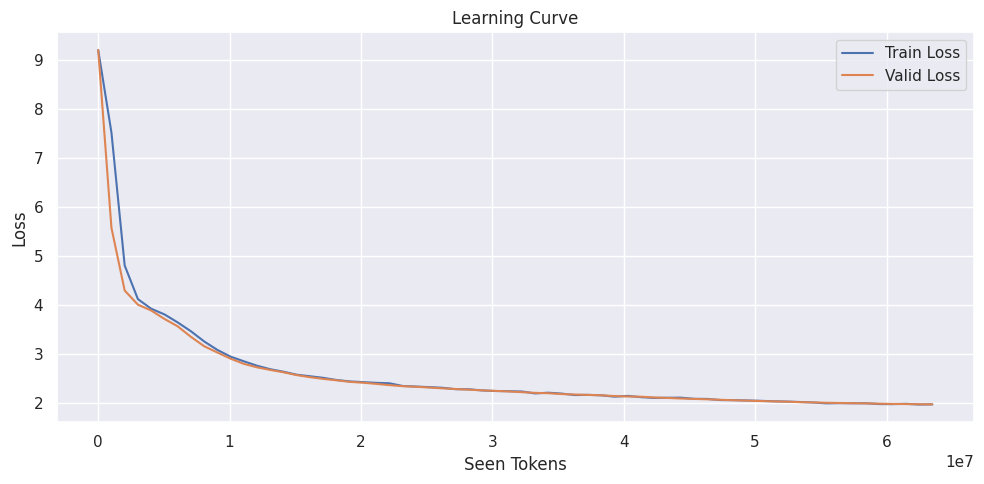

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastone special spot, a little bunny found a bright red ball. It was blue and sparkly. She loved the
ball so much that it had all her own friends.

One day, the little bunny decided to go for a walk
outside. She saw a big, yellow ball and wanted to have it back. She tried to grab it, but it was too
tight. She tried and tried, but it couldn't get up.

The little bunny was very sad. She looked
around and saw that it was a broken ball. She decided to take it home with her to show her friends.
She put the ball on the little girl's shoulder and gave it a big hug.

The little bunny was very
happy and happy. She thanked her new friends and they all played together again.

....................................................................................................

Sample 2:
In lasttime, there was a little boy called Jack. He was always looking for things to do, but he did not see
anything else. He had nothing to look 

Training:  99%|█████████▉| 64487424/65000000 [41:00<00:08, 61421.97tokens/s, Loss=1.9537, LR=9.11e-04, B/S=1.07]


🔍 Validation Loss: 1.9613
✅ Model Saved!


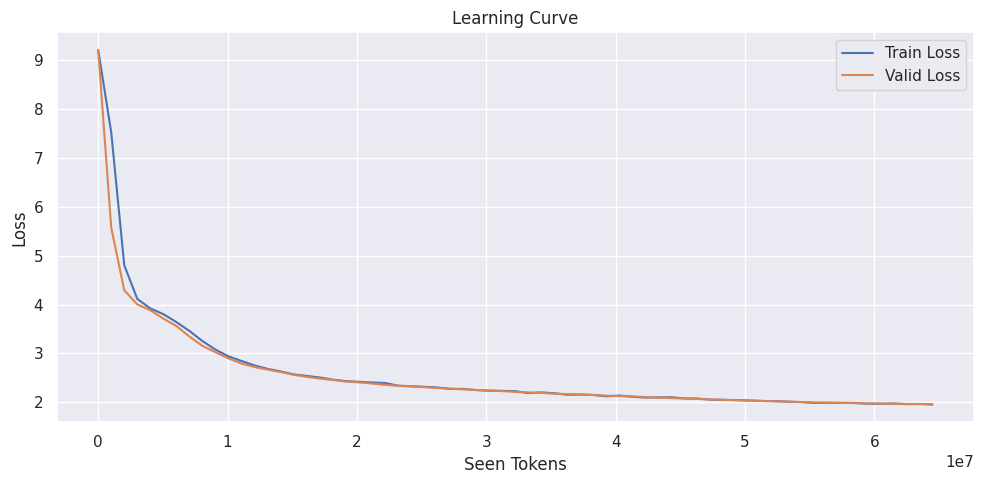

<Figure size 640x480 with 0 Axes>

🤖 Generating text samples...

🔄 Prompt 1/1: "In last"

Sample 1:
In lastmorning, he was walking through the forest. He saw a big tree with a long tail. He thought it would
be fun to play with.

The tree was very high up and he decided to take a break. He began to climb
the tree and down. He was so happy! After a while, he got tired and ready to take a nap.

He lay
down next to the tree. He was feeling very tired and he decided to go back home. The next day, he
lay down on the grass and closed his eyes. He had a lot of fun with his new friends.

....................................................................................................

Sample 2:
In lastone year, there lived a very long and beautiful girl. She loved to wear her pretty pink dress and
take a special twirl of joy to see the world around her.

One day, the girl went to the park with
her mom and dad. They were very excited and they went to a special party. They gathered all sorts of
nice things to share with all of 

Training: 65003520tokens [41:16, 60567.97tokens/s, Loss=1.9545, LR=9.09e-04, B/S=1.07]                          

✅ Saved checkpoint: checkpoints/checkpoint_20250612_094745_tok65003520.pth (seen_tokens=65,003,520)
🗑️ Removed old checkpoint: checkpoints/checkpoint_20250612_093813_tok50012160.pth
✅ Saved checkpoint: checkpoints/checkpoint_20250612_094745_tok65003520.pth (seen_tokens=65,003,520)


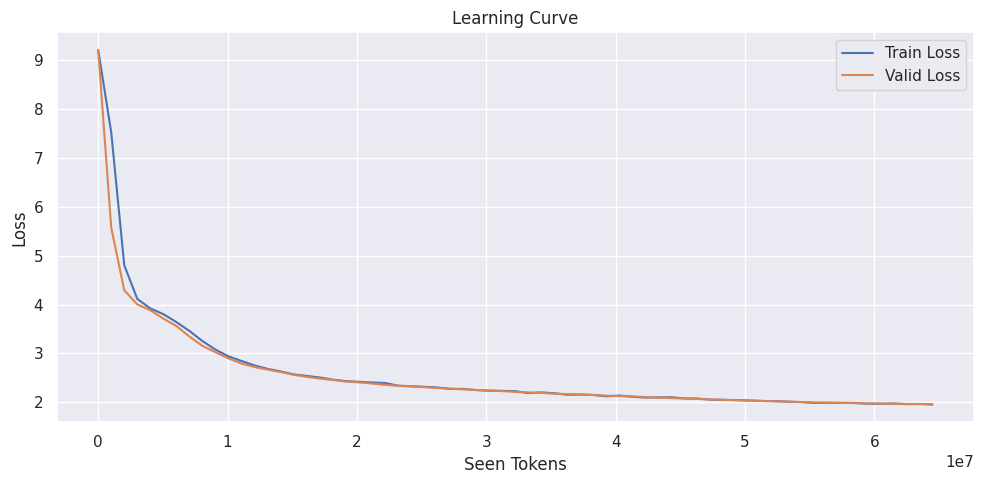

Training: 65003520tokens [41:17, 26241.20tokens/s, Loss=1.9545, LR=9.09e-04, B/S=1.07]


Training completed.


In [ ]:
# Call the 'train' method of the 'trainer' object.
# This will start or resume the model training process
# according to the configurations and data provided when the 'trainer' was instantiated.
# The method is expected to handle the training loop, including:
# - Iterating over the training data
# - Forward and backward passes
# - Optimizer steps
# - Learning rate scheduling (if configured)
# - Logging
# - Periodic evaluation (if configured)
# - Checkpoint saving
trainer.train()

In [ ]:
import torch # Assuming torch is imported

# Clear the GPU memory cache.
# This command releases unused memory that is held by the PyTorch CUDA caching allocator.
# It can be useful to free up GPU memory, especially if you are running multiple experiments
# or if you encounter "CUDA out of memory" errors.
# However, it doesn't guarantee that all memory will be freed if it's still actively referenced by tensors.
# Note: This operation can be slow and should generally be used sparingly,
# for example, between training runs or when debugging memory issues, rather than in a tight loop.
torch.cuda.empty_cache()

# 🔴 **Generate**

In [ ]:
import textwrap # Import the textwrap module for wrapping long lines of text
from termcolor import colored # Assuming 'termcolor' library is installed for colored terminal output

def print_colored_wrapped(prompt: str, generated: str, width: int = 100):
    """
    Prints the prompt and generated text with specific colors and line wrapping.
    It preserves paragraph breaks (double newlines) found in the combined text.

    The prompt part of the first line is printed in green, and all generated text
    (including the remainder of the first line and subsequent lines) is printed in cyan.

    Args:
        prompt (str): The initial prompt text.
        generated (str): The text generated by the model, following the prompt.
        width (int, optional): The maximum width of wrapped lines. Defaults to 100.
    """
    # Combine the prompt and generated text into a single string.
    full_text = prompt + generated

    # Split the full text into paragraphs based on double newline characters.
    # This helps in preserving paragraph structure during wrapping.
    paragraphs = full_text.split('\n\n')  # Split by paragraph

    # Flag to track if the current line being processed is the very first line of the output.
    first_line_overall = True

    # Iterate through each paragraph.
    for para_idx, para in enumerate(paragraphs):
        # Apply line wrapping to the current paragraph.
        # 'textwrap.wrap' breaks the paragraph into a list of lines,
        # each not exceeding the specified 'width'.
        lines = textwrap.wrap(para, width=width)

        # Iterate through each wrapped line within the paragraph.
        for line in lines:
            # Check if it's the very first line of the entire output.
            if first_line_overall:
                # For the first line, split it into the prompt part and the generated part.
                # Color the prompt green and the generated part cyan.
                prompt_len = len(prompt) # Get the original length of the prompt
                if len(line) >= prompt_len:
                    prompt_part = line[:prompt_len]
                    gen_part = line[prompt_len:]
                    print(colored(prompt_part, "green") + colored(gen_part, "cyan"))
                else:
                    # This case handles if the first wrapped line is shorter than the prompt itself.
                    print(colored(line, "green"))
                    # The remaining part of the prompt will be handled in subsequent lines,
                    # but will be colored cyan as 'first_line_overall' will become False.
                    # To avoid this, we could track remaining prompt length.
                    # For simplicity, current logic assumes prompt fits or starts the first line.

                # After processing the first line containing the prompt,
                # set the flag to False so subsequent lines are treated as generated text.
                first_line_overall = False
            else:
                # For all subsequent lines (or if the prompt was shorter than the first line),
                # print the line in cyan.
                print(colored(line, "cyan"))

        # Add an extra newline between paragraphs if it's not the last paragraph,
        # or if the original text had multiple paragraphs (len(paragraphs) > 1).
        # The original code adds a newline after every paragraph block from textwrap.
        if para_idx < len(paragraphs) - 1: # Only add if it's not the last paragraph
             print() # extra newline between paragraphs
        elif not lines and len(paragraphs) > 1 : # handles case of empty paragraph (e.g. triple newline)
             print()

    # If the loop over paragraphs didn't execute (e.g., full_text was empty or only one paragraph with no lines after wrap),
    # and the original code had a final print(), ensure consistent spacing if needed.
    # However, the original final print() was inside the paragraph loop, so it would print after each paragraph's lines.
    # The refined logic above handles inter-paragraph spacing more explicitly.

In [ ]:
# Define a list of strings, where each string is a prompt.
# These prompts will be used as starting points for text generation by a language model.
prompts = [
    'In last night',  # A short, somewhat ambiguous prompt.
    'Once upon',      # A classic fairy tale or story opener, incomplete.
    'Once upon a time', # The full classic fairy tale or story opener.
    'One day, a little boy named TimTommy was a smart 3 year old, much smarter' # A more descriptive prompt, setting a scene and character.
]

In [ ]:
# Define a list of strings, where each string is a prompt.
# These prompts will be used as starting points for text generation by a language model.
prompts = [
    'In last night',  # A short, somewhat ambiguous prompt.
    'Once upon',      # A classic fairy tale or story opener, incomplete.
    'Once upon a time', # The full classic fairy tale or story opener.
    'One day, a little boy named TimTommy was a smart 3 year old, much smarter' # A more descriptive prompt, setting a scene and character.
]

In [ ]:
# Assuming 'ids' is a 2D tensor or array-like structure (e.g., from model generation output)
# where each row represents a sequence of token IDs.
# Assuming 'pprint' is imported from the 'pprint' module for pretty printing.
# Assuming 'tokenizer' is an initialized tokenizer object with a 'decode' method.

# Set the index 'idx' to 2, indicating that we are interested in the third sequence
# from the 'ids' tensor (since indexing is typically 0-based).
idx = 2

# Initialize an empty list called 'tokens'.
# This list will be used to store the token IDs of the selected sequence,
# excluding any special tokens like an end-of-sequence token.
tokens = []

# Iterate over the token IDs in the selected sequence (ids[idx, 1:]).
# 'ids[idx, 1:]' slices the sequence:
#   'ids[idx]' selects the row (sequence) at index 'idx'.
#   '1:' slices this row from the second token ID to the end. This is often done
#   to skip a start-of-sequence token if it's present at index 0.
# 'enumerate' provides both the index (i) and the token ID (token) for each item.
for i, token in enumerate(ids[idx, 1:]):
    # Convert the token (which might be a tensor with a single element) to a Python integer.
    # Check if the current token ID is not equal to 1.
    # The value '1' is often used to represent a special token, such as an
    # end-of-sequence (EOS) token or a padding token. The exact meaning depends
    # on the tokenizer's vocabulary.
    if token.item() != 1:
        # If the token is not the special token (ID 1), append its integer value to the 'tokens' list.
        tokens.append(token.item())
    else:
        # If the token ID is 1 (assumed to be an EOS or similar break token),
        # stop processing further tokens in this sequence.
        break

# Print the length of the collected 'tokens' list (number of tokens before the special token)
# and the total length of the original sequence at index 'idx' in the 'ids' tensor.
# This helps compare how much of the sequence was processed before hitting the break condition.
print(len(tokens), len(ids[idx]))

# Decode the list of collected token IDs ('tokens') back into a human-readable text string
# using the 'decode' method of the 'tokenizer'.
# 'pprint' (pretty print) is used to display the decoded text in a more readable format,
# especially if it's long or contains complex structures (though here it's just a string).
pprint(tokenizer.decode(tokens))

NameError: name 'ids' is not defined